# Funciones de utilidad

In [7]:
import os
import csv

# Función para encontrar el siguiente nombre de archivo disponible
def get_next_model_filename(base_name="ppo_model", folder="models"):
    # Obtén todos los archivos en la carpeta
    files = os.listdir(folder)

    # Filtra los archivos que comienzan con el nombre base
    model_files = [f for f in files if f.startswith(base_name)]

    # Encuentra el número más alto entre las versiones existentes
    max_version = 0
    for f in model_files:
        try:
            version = int(f[len(base_name):].replace(".zip", "").replace("_v", ""))
            max_version = max(max_version, version)
        except ValueError:
            pass

    # Genera el nuevo nombre con la siguiente versión
    next_version = max_version + 1
    new_filename = f"{base_name}_v{next_version}.zip"

    return os.path.join(folder, new_filename)

# Función para encontrar el nombre del archivo con la versión más alta
def get_latest_model_filename(base_name="ppo_model", folder="models"):
    # Obtén todos los archivos en la carpeta
    files = os.listdir(folder)

    # Filtra los archivos que comienzan con el nombre base
    model_files = [f for f in files if f.startswith(base_name)]

    # Si no hay archivos, devuelve None
    if not model_files:
        return None

    # Encuentra el número más alto entre las versiones existentes
    max_version = 0
    latest_file = None
    for f in model_files:
        try:
            version = int(f[len(base_name):].replace(".zip", "").replace("_v", ""))
            if version > max_version:
                max_version = version
                latest_file = f
        except ValueError:
            pass

    return os.path.join(folder, latest_file) if latest_file else None

# Guardar los rewards en un archivo CSV
def save_rewards_to_csv(rewards, filename="rewards.csv"):
    with open(filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Episode", "Metrica 1", "Metrica 2", "Metrica 3", "Metrica 4", "Metrica 5", "Metrica 6", "Metrica 7", "Reward"])  # Escribir encabezado

        # Escribir cada episodio y su respectivo reward
        for i, reward in enumerate(rewards):
            # print(i + 1, reward[0], reward[1], reward[2], reward[3], reward[4], reward[5], reward[6] )
            writer.writerow([i + 1, reward[0], reward[1], reward[2], reward[3], reward[4], reward[5], reward[6], reward[7]])

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Graficar metricas
def graph_metrics(csv_file):
    df = pd.read_csv(csv_file, index_col=0)  # Asegúrate de que la primera columna sea el índice si es necesario

    plt.figure(figsize=(10, 6))
    fila_reward = df.loc[:,"Reward"]
    plt.plot(fila_reward, linestyle='-')
    plt.title(f'Comportamiento de Recompensa final')
    plt.xlabel('Episodios')
    plt.show()

    plt.figure(figsize=(10, 6))
    for id in range(1,6):
        metrica = f'Metrica {id}'
        fila_metrica = df.loc[:, metrica]
        plt.plot(fila_metrica, linestyle='-', label=metrica)

    plt.title(f'Comportamiento de Métricas')
    plt.xlabel('Episodios')


    def porcentaje(y, pos):
        return f'{int(y)}%'

    plt.gca().yaxis.set_major_formatter(FuncFormatter(porcentaje))

    plt.tight_layout()
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

# Extracción de datos

## Desde CSV

In [8]:
import pandas as pd

# Leer los archivos CSV subidos
desafios_path = '../local-db/desafios.csv'
estudiantes_path = '../local-db/estudiantes.csv'

# Cargar los CSVs con el separador adecuado ';'
desafios_df = pd.read_csv(desafios_path, sep=';', encoding='utf-8')
estudiantes_df = pd.read_csv(estudiantes_path, sep=';', encoding='utf-8')

# Mostrar las primeras filas para entender la estructura
desafios_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../local-db/desafios.csv'

In [33]:
for index, row in desafios_df.iterrows():
    carreras = row[['Carrera 1', 'Carrera 2', 'Carrera 3', 'Carrera 4', 'Carrera 5', 'Carrera 6', 'Carrera 7', 'Carrera 8']].dropna().tolist()
    desafio = {
        "Titulo": row['Nombre'],
        "Carreras": carreras
    }
    print(row["Nombre"])

SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.
Mejorar la experiencia de entrega a cliente a Nivel Nacional
Electric Vehicle as a Service (EVaaS)
Mobile Water Quality Monitoring for Offshore Fish Farms
Creación Modelo Revenue Management Menaje Easy
Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.
Caracterización del canal inalámbrico empleando tecnología IoT
Sistema de posicionamiento de robot submarino en jaula de cultivo mediante telemetría y estéreo visión.
Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.
Georeferenciación y Normalización de Direcciones
Diseño y manufactura de prototipo industrial de un equipo térmico que utilice Hidrógeno como combustible, economicamente viable para la industria chilena.
¿Como aprovechar la IA para facilitar la actividad de los profesores en la educación de nuestr

In [35]:
# Procesar los datos de los desafíos para incluirlos en un formato adecuado
desafios = []
for index, row in desafios_df.iterrows():
    carreras = row[['Carrera 1', 'Carrera 2', 'Carrera 3', 'Carrera 4', 'Carrera 5', 'Carrera 6', 'Carrera 7', 'Carrera 8']].dropna().tolist()
    desafio = {
        "Titulo": row['Nombre'],
        "Carreras": carreras
    }
    desafios.append(desafio)

# Procesar los datos de los estudiantes para incluirlos en el formato solicitado
estudiantes = []
for index, row in estudiantes_df.iterrows():
    postulaciones = row[['Preferencia 1', 'Preferencia 2', 'Preferencia 3']].dropna().tolist()
    estudiante = {
        "Nombre": row['Nombre estudiante'],
        "Carrera": row['Carrera'],
        "Postulaciones": postulaciones
    }
    # Publicado está vacío ya que no se mencionó cómo llenarlo en el ejemplo
    if "Publicado" in estudiantes_df.columns:
        estudiante["Publicado"] = row['Publicado'] if not pd.isna(row['Publicado']) else []
    estudiantes.append(estudiante)

# Crear el cuerpo JSON
body = {
    "estudiantes": estudiantes,
    "desafios": desafios
}

print(body)


{'estudiantes': [{'Nombre': 'Matias Ignacio Ayala Nanjari', 'Carrera': 'Ingeniería Civil Telemática', 'Postulaciones': ['SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.', 'Clasificación de imágenes de mamografía usando Machine Learning', 'Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.']}, {'Nombre': 'Ignacio Andrés Araya Salinas', 'Carrera': 'Ingeniería Civil Telemática', 'Postulaciones': ['SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.', 'Clasificación de imágenes de mamografía usando Machine Learning', 'Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.']}, {'Nombre': 'Camila Fernanda Guerrero Bustamante', 'Carrera': 'Construcción Civil', 'Postulaciones': ['SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.', 'Diseño y man

# Formateo de body

In [67]:
body = {
    "estudiantes": [
        {
            "Nombre": "Matias Ignacio Ayala Nanjari",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones."
            ]
        },
        {
            "Nombre": "Ignacio Andrés Araya Salinas",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones."
            ]
        },
        {
            "Nombre": "Camila Fernanda Guerrero Bustamante",
            "Carrera": "Construcción Civil",
            "Postulaciones": [
                "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.",
                "Diseño y manufactura de prototipo industrial de un equipo térmico que utilice Hidrógeno como combustible, economicamente viable para la industria chilena."
            ]
        },
        {
            "Nombre": "Simón Josías Cristóbal Álvarez Díaz",
            "Carrera": "Otras",
            "Postulaciones": [
                "Mobile Water Quality Monitoring for Offshore Fish Farms",
                "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.",
                "Mejorar la experiencia de entrega a cliente a Nivel Nacional"
            ]
        },
        {
            "Nombre": "Fernanda Ivonne Viera Castillo    ",
            "Carrera": "Construcción Civil",
            "Postulaciones": [
                "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.",
                "Creación Modelo Revenue Management Menaje Easy",
                "Mapeo de zonas rojas de apps de delivery"
            ]
        },
        {
            "Nombre": "Manuel Cruces Pirce",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Plataforma Educacional (LMS) para Coding Dojo Latam",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales."
            ]
        },
        {
            "Nombre": "Carlos Alfredo Cea Rios",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Electric Vehicle as a Service (EVaaS)",
                "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales."
            ]
        },
        {
            "Nombre": "Miguel Cabezas",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "Mejorar la experiencia de entrega a cliente a Nivel Nacional",
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Georeferenciación y Normalización de Direcciones"
            ]
        },
        {
            "Nombre": "Valentina Paz Lobos Páez",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "¿Como aprovechar la IA para facilitar la actividad de los profesores en la educación de nuestro pais?",
                "Mejorar la experiencia de entrega a cliente a Nivel Nacional"
            ]
        },
        {
            "Nombre": "Diego Escobar",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "Modulación digital de flujos de procesos enológicos de vendimia",
                "Mejorar la experiencia de entrega a cliente a Nivel Nacional",
                "Mapeo de zonas rojas de apps de delivery"
            ]
        },
        {
            "Nombre": "Juan Pablo Oyanedel",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "Modulación digital de flujos de procesos enológicos de vendimia",
                "Mejorar la experiencia de entrega a cliente a Nivel Nacional",
                "Modelo de Predicción y Correlación - Clima HR Analytics"
            ]
        },
        {
            "Nombre": "Wuendy Arlyns Arriagada Catacora",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "Modelo de control de consumo EPP y ropa de trabajo para la circularidad de elementos en desuso",
                "Modulación digital de flujos de procesos enológicos de vendimia",
                "Mejorar la experiencia de entrega a cliente a Nivel Nacional"
            ]
        },
        {
            "Nombre": "Brian Montero",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Electric Vehicle as a Service (EVaaS)",
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA.",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego."
            ]
        },
        {
            "Nombre": "Felipe Marquez",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Plataforma Configurable de Interfaz para Dispositivos de Telemetría en WOLKE",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.",
                "Electric Vehicle as a Service (EVaaS)"
            ]
        },
        {
            "Nombre": "Francisco Lopez Figueroa",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Mobile Water Quality Monitoring for Offshore Fish Farms",
                "Electric Vehicle as a Service (EVaaS)",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego."
            ]
        },
        {
            "Nombre": "Karolain Yarely Cabrera Cabrera",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Mobile Water Quality Monitoring for Offshore Fish Farms",
                "Electric Vehicle as a Service (EVaaS)",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego."
            ]
        },
        {
            "Nombre": "Gabriela González",
            "Carrera": "Ingeniería en Diseño de Productos",
            "Postulaciones": [
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.",
                "Electric Vehicle as a Service (EVaaS)",
                "Modulación digital de flujos de procesos enológicos de vendimia"
            ]
        },
        {
            "Nombre": "cristhian Urra Aldunate",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Mobile Water Quality Monitoring for Offshore Fish Farms",
                "Sistema de posicionamiento de robot submarino en jaula de cultivo mediante telemetría y estéreo visión.",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro"
            ]
        },
        {
            "Nombre": "Juan del Valle",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.",
                "Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.",
                "Clasificación de imágenes de mamografía usando Machine Learning"
            ]
        },
        {
            "Nombre": "Catalina Angélica Ulloa Fritz",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones."
            ]
        },
        {
            "Nombre": "Agustin Nicolas Ovando Saenz",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollar un sistema de correlación de datos de diversas plataformas de seguridad para identificar patrones y relaciones entre eventos aparentemente no relacionados y estimar riesgos de ciberseguridad",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego."
            ]
        },
        {
            "Nombre": "Gonzalo Soto Ulloa",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollar un sistema de correlación de datos de diversas plataformas de seguridad para identificar patrones y relaciones entre eventos aparentemente no relacionados y estimar riesgos de ciberseguridad",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego."
            ]
        },
        {
            "Nombre": "Sebastian Jara",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollar un sistema de correlación de datos de diversas plataformas de seguridad para identificar patrones y relaciones entre eventos aparentemente no relacionados y estimar riesgos de ciberseguridad",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego."
            ]
        },
        {
            "Nombre": "Benjamin Pino Olivares",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollar un sistema de correlación de datos de diversas plataformas de seguridad para identificar patrones y relaciones entre eventos aparentemente no relacionados y estimar riesgos de ciberseguridad",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.",
                "Desarrollo de un Software para Automatizar Operaciones de Análisis de Genómica Funcional en Hongos"
            ]
        },
        {
            "Nombre": "Claudio Blas Arnaldo Santana Dominguez",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Quantum Challengue: Simular en un computador cuántico el comportamiento QKD en Base a Protocolo BB84.",
                "Atlas/Bitácora de Casos Oncológicos Complejos",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego."
            ]
        },
        {
            "Nombre": "Matías Yamil Soto Sepúlveda",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.",
                "Sistema de Localización en Tiempo Real (RTLS) de pacientes dentro de una clínica basado en machine learning",
                "Caracterización del canal inalámbrico empleando tecnología IoT"
            ]
        },
        {
            "Nombre": "Battá Tomás Tuki Cadenas",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Georeferenciación y Normalización de Direcciones"
            ]
        },
        {
            "Nombre": "Nicolás Eduardo Salas Barrantes",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "OptiDataLake: Plataforma de Gestión y Análisis de Market Data",
                "People Analytics - Talento y Desarrollo",
                "Georeferenciación y Normalización de Direcciones"
            ]
        },
        {
            "Nombre": "Javiera Díaz Mesina",
            "Carrera": "Ingeniería Comercial",
            "Postulaciones": [
                "People Analytics - Talento y Desarrollo",
                "Diseño y manufactura de prototipo industrial de un equipo térmico que utilice Hidrógeno como combustible, economicamente viable para la industria chilena."
            ]
        },
        {
            "Nombre": "Mariapaz Gómez Godoy",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "OptiDataLake: Plataforma de Gestión y Análisis de Market Data",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro",
                "¿Como aprovechar la IA para facilitar la actividad de los profesores en la educación de nuestro pais?"
            ]
        },
        {
            "Nombre": "Benjamín Nicolás Miranda Muñoz",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "Plataforma Educacional (LMS) para Coding Dojo Latam",
                "Modulación digital de flujos de procesos enológicos de vendimia",
                "People Analytics - Talento y Desarrollo"
            ]
        },
        {
            "Nombre": "Thomas Soto",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Miido - tecnología para optimizar el uso de fertilizantes en agro",
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Atlas/Bitácora de Casos Oncológicos Complejos"
            ]
        },
        {
            "Nombre": "Nicolás Andrés Ruiz Ruiz",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro"
            ]
        },
        {
            "Nombre": "Vicente Ignacio Carreño Escobar",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro"
            ]
        },
        {
            "Nombre": "Marcelo Andre Garcia Ramos",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollo de un Software para Automatizar Operaciones de Análisis de Genómica Funcional en Hongos",
                "Plataforma Educacional (LMS) para Coding Dojo Latam",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro"
            ]
        },
        {
            "Nombre": "FARID DÍAZ",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollo de un Software para Automatizar Operaciones de Análisis de Genómica Funcional en Hongos",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro",
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA."
            ]
        },
        {
            "Nombre": "Cristian Vega",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Miido - tecnología para optimizar el uso de fertilizantes en agro",
                "Sistema de Localización en Tiempo Real (RTLS) de pacientes dentro de una clínica basado en machine learning",
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA."
            ]
        },
        {
            "Nombre": "Fabian Esteban Godoy Casas",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollo de un Software para Automatizar Operaciones de Análisis de Genómica Funcional en Hongos",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro"
            ]
        },
        {
            "Nombre": "Santiago Lopez",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro",
                "Modelo de Predicción y Correlación - Clima HR Analytics"
            ]
        },
        {
            "Nombre": "Ariel Bravo Ponce",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "OptiDataLake: Plataforma de Gestión y Análisis de Market Data",
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA.",
                "Clasificación de imágenes de mamografía usando Machine Learning"
            ]
        },
        {
            "Nombre": "Gianfranco Rolla Teneos",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "OptiDataLake: Plataforma de Gestión y Análisis de Market Data",
                "Rutas de inspección visual del espacio público urbano",
                "Desarrollar un sistema de correlación de datos de diversas plataformas de seguridad para identificar patrones y relaciones entre eventos aparentemente no relacionados y estimar riesgos de ciberseguridad"
            ]
        },
        {
            "Nombre": "Jeremy Andrew Joy Immediato",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Administrador de Diccionarios de Datos",
                "OptiDataLake: Plataforma de Gestión y Análisis de Market Data"
            ]
        },
        {
            "Nombre": "Vania Schatloff",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "OptiDataLake: Plataforma de Gestión y Análisis de Market Data",
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA."
            ]
        },
        {
            "Nombre": "Vicente Alvear",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "OptiDataLake: Plataforma de Gestión y Análisis de Market Data",
                "Modelo de Predicción y Correlación - Clima HR Analytics"
            ]
        },
        {
            "Nombre": "Cristóbal Antonio Nilo Garrido",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Rutas de inspección visual del espacio público urbano",
                "Mapeo de zonas rojas de apps de delivery",
                "Uso de LLMs para masificar la explotación de datos en Falp"
            ]
        },
        {
            "Nombre": "Vicente Andrés Llanos Álvarez",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Mapeo de zonas rojas de apps de delivery",
                "Rutas de inspección visual del espacio público urbano"
            ]
        },
        {
            "Nombre": "Felipe Williams Francisco Rodriguez Rodriguez",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Mapeo de zonas rojas de apps de delivery",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Plataforma Educacional (LMS) para Coding Dojo Latam"
            ]
        },
        {
            "Nombre": "Jorge Antonio Rojas Huaiquimilla",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Rutas de inspección visual del espacio público urbano",
                "Mapeo de zonas rojas de apps de delivery",
                "Desarrollar un sistema de correlación de datos de diversas plataformas de seguridad para identificar patrones y relaciones entre eventos aparentemente no relacionados y estimar riesgos de ciberseguridad"
            ]
        },
        {
            "Nombre": "Fabián Elías Soto morales",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Mapeo de zonas rojas de apps de delivery"
            ]
        },
        {
            "Nombre": "hsien-i lee",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Mapeo de zonas rojas de apps de delivery"
            ]
        },
        {
            "Nombre": "Constanza Javiera Corday Loayza",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Modelo de Predicción y Correlación - Clima HR Analytics",
                "Mapeo de zonas rojas de apps de delivery"
            ]
        },
        {
            "Nombre": "Martín Alejandro Rojas Moya",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Modelo de Predicción y Correlación - Clima HR Analytics",
                "Mapeo de zonas rojas de apps de delivery"
            ]
        },
        {
            "Nombre": "Alexander Alfaro",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Administrador de Diccionarios de Datos",
                "Plataforma Configurable de Interfaz para Dispositivos de Telemetría en WOLKE",
                "Rutas de inspección visual del espacio público urbano"
            ]
        },
        {
            "Nombre": "Mauricio Ignacio Carvajal Andrade",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Rutas de inspección visual del espacio público urbano",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Sistema para la limpieza automatizada de riel de Tripper minero"
            ]
        },
        {
            "Nombre": "Sergio Rojas Escanilla",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA.",
                "Atlas/Bitácora de Casos Oncológicos Complejos",
                "Clasificación de imágenes de mamografía usando Machine Learning"
            ]
        },
        {
            "Nombre": "Jonathan Ignacio Abraham Pedraza Valdebenito",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA."
            ]
        },
        {
            "Nombre": "Julio Aníbal Maturana Solís",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Sistema de Localización en Tiempo Real (RTLS) de pacientes dentro de una clínica basado en machine learning",
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA."
            ]
        },
        {
            "Nombre": "JUAN PATRICIO ARDILES CASTILLO",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA."
            ]
        },
        {
            "Nombre": "Cristhofer Brian Ruben Araya Recabarren",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Administrador de Diccionarios de Datos",
                "Plataforma Configurable de Interfaz para Dispositivos de Telemetría en WOLKE",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud"
            ]
        },
        {
            "Nombre": "José Ignacio Alegría Vergara",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Modelo de Predicción y Correlación - Clima HR Analytics"
            ]
        },
        {
            "Nombre": "Marcelo Esteban Díaz Moya",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Modelo de Predicción y Correlación - Clima HR Analytics"
            ]
        },
        {
            "Nombre": "Benjamín Rodrigo Aros Báez",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Normalizacion de Datos Categóricos"
            ]
        },
        {
            "Nombre": "Javier Ahumada",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Miido - tecnología para optimizar el uso de fertilizantes en agro",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "¿Como aprovechar la IA para facilitar la actividad de los profesores en la educación de nuestro pais?"
            ]
        },
        {
            "Nombre": "Benjamin Vicuña",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "People Analytics - Talento y Desarrollo",
                "Mejorar la experiencia de entrega a cliente a Nivel Nacional",
                "Modelo de control de consumo EPP y ropa de trabajo para la circularidad de elementos en desuso"
            ]
        }
    ],
    "desafios": [
        {
            "Titulo": "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.",
            "Carreras": [
                "Arquitectura",
                "Ingeniería Civil Ambiental",
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Mejorar la experiencia de entrega a cliente a Nivel Nacional",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática",
                "Ingeniería Comercial",
                "Ingeniería en Diseño de Productos",
                "Otras"
            ]
        },
        {
            "Titulo": "Electric Vehicle as a Service (EVaaS)",
            "Carreras": [
                "Ingeniería Civil Eléctrica",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Mobile Water Quality Monitoring for Offshore Fish Farms",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Creación Modelo Revenue Management Menaje Easy",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática",
                "Ingeniería Comercial",
                "Ingeniería en Diseño de Productos",
                "Otras"
            ]
        },
        {
            "Titulo": "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.",
            "Carreras": [
                "Ingeniería Civil Eléctrica",
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Caracterización del canal inalámbrico empleando tecnología IoT",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Sistema de posicionamiento de robot submarino en jaula de cultivo mediante telemetría y estéreo visión.",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Georeferenciación y Normalización de Direcciones",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Ambiental",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Otras"
            ]
        },
        {
            "Titulo": "Diseño y manufactura de prototipo industrial de un equipo térmico que utilice Hidrógeno como combustible, economicamente viable para la industria chilena.",
            "Carreras": [
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Mecánica",
                "Ingeniería Civil Química",
                "Otras",
                "Ingeniería Civil Ambiental",
                "Ingeniería Comercial"
            ]
        },
        {
            "Titulo": "¿Como aprovechar la IA para facilitar la actividad de los profesores en la educación de nuestro pais?",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática",
                "Ingeniería Comercial",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "People Analytics - Talento y Desarrollo",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática",
                "Ingeniería Comercial",
                "Ingeniería en Diseño de Productos",
                "Otras"
            ]
        },
        {
            "Titulo": "Miido - tecnología para optimizar el uso de fertilizantes en agro",
            "Carreras": [
                "Ingeniería Civil Ambiental",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "OptiDataLake: Plataforma de Gestión y Análisis de Market Data",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática",
                "Ingeniería Comercial",
                "Otras"
            ]
        },
        {
            "Titulo": "Quantum Challengue: Simular en un computador cuántico el comportamiento QKD en Base a Protocolo BB84.",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Desarrollo de un Software para Automatizar Operaciones de Análisis de Genómica Funcional en Hongos",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería Civil Química",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Mapeo de zonas rojas de apps de delivery",
            "Carreras": [
                "Arquitectura",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Rutas de inspección visual del espacio público urbano",
            "Carreras": [
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA.",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Plataforma Configurable de Interfaz para Dispositivos de Telemetría en WOLKE",
            "Carreras": [
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Modelo de Predicción y Correlación - Clima HR Analytics",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática",
                "Ingeniería Comercial",
                "Ingeniería en Diseño de Productos",
                "Otras"
            ]
        },
        {
            "Titulo": "Modulación digital de flujos de procesos enológicos de vendimia",
            "Carreras": [
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Plataforma Educacional (LMS) para Coding Dojo Latam",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería en Diseño de Productos",
                "Otras"
            ]
        },
        {
            "Titulo": "Normalizacion de Datos Categóricos",
            "Carreras": [
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Otras"
            ]
        },
        {
            "Titulo": "Administrador de Diccionarios de Datos",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Otras"
            ]
        },
        {
            "Titulo": "Uso de LLMs para masificar la explotación de datos en Falp",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Otras"
            ]
        },
        {
            "Titulo": "Atlas/Bitácora de Casos Oncológicos Complejos",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos",
                "Otras"
            ]
        },
        {
            "Titulo": "Sistema para el control y mejora de la limpieza industrial bajo correa transportadora en minería para contratos de aseo industrial NEXXO",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Sistema para la limpieza automatizada de riel de Tripper minero",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Mecánica",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Simulación y control de las velocidades de la solución química al interior de los paneles de tubos de calderas para una limpieza química",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Química"
            ]
        },
        {
            "Titulo": "Modelo de control de consumo EPP y ropa de trabajo para la circularidad de elementos en desuso",
            "Carreras": [
                "Ingeniería Civil Ambiental",
                "Ingeniería Civil Industrial",
                "Ingeniería Comercial"
            ]
        },
        {
            "Titulo": "Clasificación de imágenes de mamografía usando Machine Learning",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Sistema de Localización en Tiempo Real (RTLS) de pacientes dentro de una clínica basado en machine learning",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Eléctrica",
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Eléctrica",
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Desarrollar un sistema de correlación de datos de diversas plataformas de seguridad para identificar patrones y relaciones entre eventos aparentemente no relacionados y estimar riesgos de ciberseguridad",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Implementar un sistema de revision y generación de informes automatizados que resuma el estado de seguridad de la red, incluyendo recomendaciones para mejoras.",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Implementacion de sistema que permita gestionar incidentes de ciberseguridad",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática"
            ]
        }
    ],
    "carreras": [
        {
            "Nombre": "Arquitectura",
            "Maximo": 1
        },
        {
            "Nombre": "Construcción Civil",
            "Maximo": 1
        },
        {
            "Nombre": "Ingeniería Civil",
            "Maximo": 1
        },
        {
            "Nombre": "Ingeniería Civil Ambiental",
            "Maximo": 1
        },
        {
            "Nombre": "Ingeniería Civil de Minas",
            "Maximo": 1
        },
        {
            "Nombre": "Ingeniería Civil Eléctrica",
            "Maximo": 1
        },
        {
            "Nombre": "Ingeniería Civil Electrónica",
            "Maximo": 1
        },
        {
            "Nombre": "Ingeniería Civil Industrial",
            "Maximo": 1
        },
        {
            "Nombre": "Ingeniería Civil Informática",
            "Maximo": 1
        },
        {
            "Nombre": "Ingeniería Civil Matemática",
            "Maximo": 1
        },
        {
            "Nombre": "Ingeniería Civil Mecánica",
            "Maximo": 1
        },
        {
            "Nombre": "Ingeniería Civil Metalúrgica",
            "Maximo": 1
        },
        {
            "Nombre": "Ingeniería Civil Química",
            "Maximo": 1
        },
        {
            "Nombre": "Ingeniería Civil Telemática",
            "Maximo": 3
        },
        {
            "Nombre": "Ingeniería Comercial",
            "Maximo": 1
        },
        {
            "Nombre": "Ingeniería en Diseño de Productos",
            "Maximo": 1
        },
        {
            "Nombre": "Otras",
            "Maximo": 1
        }
    ]
}


In [68]:
maximo_por_carrera = []
nombre_carreras = []
for carrera in body["carreras"]:
    maximo_por_carrera.append(carrera["Maximo"])
    nombre_carreras.append(carrera["Nombre"])

print("Nombre de carreras")
print(nombre_carreras)
print("\nMaximo por carrera")
print(maximo_por_carrera)


Nombre de carreras
['Arquitectura', 'Construcción Civil', 'Ingeniería Civil', 'Ingeniería Civil Ambiental', 'Ingeniería Civil de Minas', 'Ingeniería Civil Eléctrica', 'Ingeniería Civil Electrónica', 'Ingeniería Civil Industrial', 'Ingeniería Civil Informática', 'Ingeniería Civil Matemática', 'Ingeniería Civil Mecánica', 'Ingeniería Civil Metalúrgica', 'Ingeniería Civil Química', 'Ingeniería Civil Telemática', 'Ingeniería Comercial', 'Ingeniería en Diseño de Productos', 'Otras']

Maximo por carrera
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1]


In [69]:
nombres_desafios = []
carreras_en_desafios = []
for desafio in body["desafios"]:
    nombres_desafios.append(desafio["Titulo"])
    nombres_carreras_en_desafio = desafio["Carreras"]
    ids_carreras_en_desafio = []
    for n_carrera in nombres_carreras_en_desafio:
        id_carrera = nombre_carreras.index(n_carrera) + 1
        ids_carreras_en_desafio.append(id_carrera)
    carreras_en_desafios.append(ids_carreras_en_desafio)
print("Nombre de desafios")
print(nombres_desafios)
print("\nCarreras en desafios")
print(carreras_en_desafios)

Nombre de desafios
['SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.', 'Mejorar la experiencia de entrega a cliente a Nivel Nacional', 'Electric Vehicle as a Service (EVaaS)', 'Mobile Water Quality Monitoring for Offshore Fish Farms', 'Creación Modelo Revenue Management Menaje Easy', 'Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.', 'Caracterización del canal inalámbrico empleando tecnología IoT', 'Sistema de posicionamiento de robot submarino en jaula de cultivo mediante telemetría y estéreo visión.', 'Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.', 'Georeferenciación y Normalización de Direcciones', 'Diseño y manufactura de prototipo industrial de un equipo térmico que utilice Hidrógeno como combustible, economicamente viable para la industria chilena.', '¿Como aprovechar la IA para facilitar la

In [70]:
preferencias = []
nombres_estudiantes = []
carrera_de_estudiantes = []
for estudiante in body["estudiantes"]:
    carrera_estudiante = estudiante["Carrera"]
    id_carrera_estudiante = nombre_carreras.index(carrera_estudiante) + 1
    carrera_de_estudiantes.append(id_carrera_estudiante)

    nombres_estudiantes.append(estudiante["Nombre"])
    postulaciones_estudiante = []
    for p in estudiante["Postulaciones"]:
        id_desafio = nombres_desafios.index(p) + 1
        postulaciones_estudiante.append(id_desafio)
    preferencias.append(postulaciones_estudiante)
print("Preferencias")
print(preferencias)

print("\nNombres de estudiantes")
print(nombres_estudiantes)

print("\nCarreras estudiantes")
print(carrera_de_estudiantes)

Preferencias
[[1, 33, 9], [1, 33, 9], [1, 11], [4, 1, 2], [1, 5, 18], [24, 35, 1], [33, 3, 1], [2, 27, 10], [12, 2], [23, 2, 18], [23, 2, 22], [32, 23, 2], [3, 20, 6], [21, 6, 3], [4, 3, 6], [4, 3, 6], [6, 3, 23], [4, 8, 14], [6, 9, 33], [6, 33, 9], [36, 33, 6], [36, 33, 6], [36, 33, 6], [36, 6, 17], [16, 28, 6], [9, 34, 7], [27, 33, 10], [15, 13, 10], [13, 11], [15, 14, 12], [24, 23, 13], [14, 27, 28], [33, 35, 14], [33, 35, 14], [17, 24, 14], [17, 14, 20], [14, 34, 20], [17, 33, 14], [33, 14, 22], [15, 20, 33], [15, 19, 36], [27, 26, 15], [27, 15, 20], [27, 15, 22], [19, 18, 27], [33, 18, 19], [18, 33, 24], [19, 18, 36], [27, 35, 18], [27, 35, 18], [33, 22, 18], [33, 22, 18], [26, 21, 19], [19, 35, 30], [20, 28, 33], [20], [33, 34, 20], [33, 35, 20], [26, 21, 35], [27, 35, 22], [33, 27, 22], [27, 35, 25], [14, 33, 12], [13, 2, 32]]

Nombres de estudiantes
['Matias Ignacio Ayala Nanjari', 'Ignacio Andrés Araya Salinas', 'Camila Fernanda Guerrero Bustamante', 'Simón Josías Cristóbal Ál

# Ambiente de entrenamiento para DRL

In [22]:
from gym import Env, spaces
import numpy as np

class OrganizationEnvironment(Env):
    def __init__(self,
            preferencias                = None,                     # Matriz de preferencias
            carrera_de_estudiantes      = None,                     # Matriz de carreras de estudiantes
            carreras_en_desafios        = None,                     # Matriz de carrera de desafios
            maximo_por_carrera          = None,                     # Matriz de estudiantes maximos de la misma carrera en un grupo

            numero_desafios             = None,
            numero_estudiantes          = None,
            MAXIMO_DESAFIOS             = 100,                      # Cantidad máxima de desafíos que el simulador puede soportar
            MAXIMO_ESTUDIANTES          = 100,                      # Cantidad máxima de estudiantes que el simulador puede soportar

            rendering                   = False,                    # Se imprime por pantalla información detallada de cada paso, reset, etc.
            alpha                       = 0.5                       # 0 -> Satisfacción estudiante, 1 -> Multidisciplinariedad
        ):
        """
            preferencias                    (Matriz de preferencias)
            carrera_de_estudiantes          (Matriz de carreras de estudiantes)
            carreras_en_desafios            (Matriz de carrera de desafios)
            maximo_por_carrera              (Matriz de estudiantes maximos de la misma carrera en un grupo)
            nombres_estudiantes
            MAXIMO_DESAFIOS                 (Cantidad máxima de desafíos que el simulador puede soportar)
            MAXIMO_ESTUDIANTES              (Cantidad máxima de estudiantes que el simulador puede soportar)
            MAXIMO_CARRERAS                 (Cantidad máxima de carreras que el simulador puede soportar)
            MAXIMO_DE_CARRERAS_EN_D         (Máximo de la misma carrera en un desafío que el simulador puede soportar)
            MAXIMO_PREF_D_X_ESTUDIANTE      (Máximo número de preferencias que puede soportar el simulador por estudiante)
            MAXIMO_PREF_C_X_DESAFIO         (Máximo de carreras seleccionadas por desafío el simulador puede soportar)
            training
            t_random_preferencias           (Crear una matriz de preferencia cada reset)
            t_random_max_preferencias       (Al crear matriz de preferencia tendrán un valor aleatorio maximo de preferencias)
            t_shuffle_estudiantes           (Desordenar estudiantes cada reset)
            t_maximo_preferencias           (Número de preferencia maximo por estudiante)
            t_minimo_preferencias           (Número de preferencia minimo por estudiante)
            t_maximo_estudiantes            (Maximo de estudiantes al crear matriz de preferencia)
            t_maximo_desafios               (Maximo de desafios al crear matriz de preferencia)
            t_maximo_carreras               (Maximo de carreras del total)
            t_maximo_carreras_pref          (Maximo de carreras que puede querer un desafio)
            t_minimo_carreras_pref          (Minimo de carreras que puede querer un desafio)
            t_maximo_max_carreras_en_d      (Numero maximo del maximo de carreras por desafio)
            t_minimo_max_carreras_en_d      (Numero minimo del maximo de carreras por desafio)
            rendering                       (Se imprime por pantalla información detallada de cada paso, reset, etc.)
        """

        super(OrganizationEnvironment, self).__init__()

        # LIMITANTES DEL SIMULADOR
        self.MAXIMO_DESAFIOS            = MAXIMO_DESAFIOS
        self.MAXIMO_ESTUDIANTES         = MAXIMO_ESTUDIANTES

        # RENDER
        self.rendering                  = rendering

        # ESTADO
        self.carrera_de_estudiantes     = carrera_de_estudiantes
        self.carreras_en_desafios       = carreras_en_desafios
        self.maximo_por_carrera         = maximo_por_carrera
        self.preferencias               = preferencias

        self.numero_desafios            = numero_desafios
        self.numero_estudiantes         = numero_estudiantes
        self.carreras_dentro_desafios   = [[] for _ in range(numero_desafios)]

        # CREACIÓN MATRIZ SELECCIÓN DE DESAFIOS
        self.state                      = [0] * self.MAXIMO_ESTUDIANTES

        # ESPACIO DE OBSERVACIÓN
        self.observation_space          = spaces.MultiDiscrete(
            # SELECCIÓN DE DESAFIOS
            [self.MAXIMO_DESAFIOS + 1] * (self.MAXIMO_ESTUDIANTES)
        )

        # REWARD
        self.alpha = alpha
        self.all_rewards = []
        self.cumulative_reward = 0

        # ESPACIO DE ACCIÓN
        self.action_space               = spaces.Discrete(self.MAXIMO_DESAFIOS)

    def reset(self):
        last_observation = self.get_observation()

        self.state = [0] * self.MAXIMO_ESTUDIANTES
        self.cumulative_reward = 0
        self.reward_acumulado = 0
        self.current_student_id = 0
        return last_observation

    def get_student_id(self):
        current_student_id_prev = self.current_student_id
        self.current_student_id += 1
        return current_student_id_prev

    def step(self, action):
        assert self.action_space.contains(action), "Invalid Action"

        # Normalizar acción
        id_desafio = round(action * (self.numero_desafios - 1) / self.MAXIMO_DESAFIOS)
        id_estudiante = self.get_student_id()

        reward = self.get_reward([id_estudiante, id_desafio])

        self.cumulative_reward += reward

        done = self.check_done(id_estudiante)

        observation = self.get_observation()
        info = {}

        if done:
            self.all_rewards.append(self.get_metricas(render=False) + [self.cumulative_reward])
            # return observation, self.reward_acumulado, done, info
        return observation, reward, done, info

    def get_observation(self):
        # Aplanar el estado y las preferencias para ajustarse al espacio de observación
        return  self.state

    def check_done(self, id_estudiante):
        return id_estudiante == self.numero_estudiantes - 1

    def get_metricas(self, render = True):

        # Metricas Satisfacción de estudiantes
        metrica_1 = 0 # % de satisfacción de los estudiantes (100% -> todos quedaron en su 1ra preferencia, 50% -> 2da, 33,3% -> 3ra ...)
        metrica_2 = 0 # N° de estudiantes que quedarón en su primera prioridad
        metrica_3 = 0 # N° de estudiantes que quedarón fuera de sus postulaciones

        # Metricas Satisfacción de las organizaciones
        metrica_4 = 0 # Las carreras de los estudiantes están dentro de las preferencias de carreras de los desafíos
        metrica_5 = 0 # N° desafíos sin equipo


        # Metricas PMM
        metrica_6 = 0 # La desviacion estandar de la distribución de los estudiantes
        metrica_7 = 0 # N° de carreras dentro de un mismo equipo promedio

        carreras_por_desafio = [[] for _ in range(self.numero_desafios)]
        for id_estudiante in range(self.numero_estudiantes):
            desafio_asignado = self.state[id_estudiante]
            carrera_estudiante = self.carrera_de_estudiantes[id_estudiante]
            preferencia = self.preferencias[id_estudiante].index(desafio_asignado) + 1 if desafio_asignado in self.preferencias[id_estudiante] and desafio_asignado > 0 else 0
            metrica_1 += (1 / preferencia) if preferencia != 0 else 0
            metrica_2 += 1 if preferencia == 1 else 0
            metrica_3 += 1 if preferencia == 0 else 0
            metrica_4 += 1 if carrera_estudiante in self.carreras_en_desafios[desafio_asignado - 1] and desafio_asignado > 0 else 0

            if carrera_estudiante not in carreras_por_desafio[desafio_asignado - 1]:
                carreras_por_desafio[desafio_asignado - 1].append(carrera_estudiante)

        cantidad_de_estudiante_por_grupo = []

        for id_desafio in range(1, self.numero_desafios + 1):
            if(id_desafio not in self.state[:self.numero_estudiantes]): # Caso de que no esten dentro de los desfíos asignados
                metrica_5 += 1
            else:
                metrica_7 += len(set(self.carreras_dentro_desafios[id_desafio - 1]))
                cantidad_de_estudiante_por_grupo.append(len(self.carreras_dentro_desafios[id_desafio - 1]))

        metrica_1 = round((metrica_1 / self.numero_estudiantes) * 100,2)
        metrica_2 = round((metrica_2 / self.numero_estudiantes) * 100,2)
        metrica_3 = round((metrica_3 / self.numero_estudiantes) * 100,2)

        metrica_4 = round((metrica_4 / self.numero_desafios) * 100,2)
        metrica_5 = round((metrica_5 / self.numero_desafios) * 100,2)
        metrica_6 = np.std(list(cantidad_de_estudiante_por_grupo))
        metrica_7 = round((metrica_7 / self.numero_desafios),2)

        if render:
            print("Metricas de Satisfacción del estudiante:")
            print(f"Metrica 1: El nivel de satisfacción de los estudiantes es del {metrica_1}%.")
            print(f"Metrica 2: El {metrica_2}% de los estudiantes quedaron en su 1° preferencia.")
            print(f"Metrica 3: El {metrica_3}% de los estudiantes quedaron fuera de sus preferencias.")

            print("\nMetricas de Satisfacción de las organizaciones:")
            print(f"Metrica 4: El {metrica_4}% de los estudiantes pertenecen a una de las carreras a fines de las preferencias de la organización")
            print(f"Metrica 5: El {metrica_5}% de desafíos no tienen equipo")

            print("\nMetricas de Satisfacción de PMM:")
            print(f"Metrica 6: La desviación estandar de la distribución de los estudiantes es {metrica_6}")
            print(f"Metrica 7: El promedio de la cantidad de carreras distintas dentro de un mismo equipo es {metrica_7}")

        return [metrica_1, metrica_2, metrica_3, metrica_4, metrica_5, metrica_6, metrica_7]

    def get_reward(self, action):
        # La acción tiene la forma [id_estudiante, id_desafio]
        id_estudiante, id_desafio = action

        # Checkeamos si es imposible dejarlos dentro del desafío
        carrera_estudiante = self.carrera_de_estudiantes[id_estudiante]

        if carrera_estudiante in self.carreras_dentro_desafios[id_desafio]:
            cantidad_misma_carrera = self.carreras_dentro_desafios[id_desafio].count(carrera_estudiante)
            if(cantidad_misma_carrera > self.maximo_por_carrera[carrera_estudiante - 1]):
                return -1

        self.carreras_dentro_desafios[id_desafio].append(carrera_estudiante)
        interseccion = set(self.carreras_dentro_desafios[id_desafio]).intersection(set(self.carreras_en_desafios[id_desafio]))
        carreras_unicas = len(interseccion)

        # Actualizamos el estado con la acción tomada
        self.state[id_estudiante] = id_desafio + 1

        # Datos
        preferencia = self.preferencias[id_estudiante].index(id_desafio + 1) + 1 if id_desafio + 1 in self.preferencias[id_estudiante] and id_desafio + 1 > 0 else 0
        if(preferencia == 0):
            return -1
        x1 = (1/preferencia)
        x2 = 1 - (1/carreras_unicas) if carreras_unicas > 0 else 0

        return 2 * (self.alpha * x1 + (1 - self.alpha) * x2)

env = OrganizationEnvironment(
                              preferencias=preferencias,
                              carrera_de_estudiantes=carrera_de_estudiantes,
                              carreras_en_desafios=carreras_en_desafios,
                              maximo_por_carrera=maximo_por_carrera,
                              numero_desafios=len(nombres_desafios),
                              numero_estudiantes=len(nombres_estudiantes)
                              )

# Random

In [23]:
env.reset()
while True:
    action = env.action_space.sample()

    obs, reward, done, info = env.step(action)

    # print("\n\n")
    print("Acción:", action,"-> Reward:", reward)
    # env.render("state")

    if done == True:
        break
env.state
env.get_metricas()

Acción: 38 -> Reward: -1
Acción: 24 -> Reward: -1
Acción: 0 -> Reward: 1.0
Acción: 68 -> Reward: -1
Acción: 82 -> Reward: -1
Acción: 28 -> Reward: -1
Acción: 76 -> Reward: -1
Acción: 82 -> Reward: -1
Acción: 45 -> Reward: -1
Acción: 21 -> Reward: -1
Acción: 33 -> Reward: -1
Acción: 99 -> Reward: -1
Acción: 17 -> Reward: -1
Acción: 10 -> Reward: -1
Acción: 51 -> Reward: -1
Acción: 67 -> Reward: -1
Acción: 36 -> Reward: -1
Acción: 10 -> Reward: -1
Acción: 33 -> Reward: -1
Acción: 91 -> Reward: -1
Acción: 22 -> Reward: -1
Acción: 56 -> Reward: -1
Acción: 46 -> Reward: -1
Acción: 62 -> Reward: -1
Acción: 12 -> Reward: -1
Acción: 62 -> Reward: -1
Acción: 34 -> Reward: -1
Acción: 46 -> Reward: -1
Acción: 88 -> Reward: -1
Acción: 13 -> Reward: -1
Acción: 88 -> Reward: -1
Acción: 90 -> Reward: -1
Acción: 47 -> Reward: -1
Acción: 58 -> Reward: -1
Acción: 42 -> Reward: 1.0
Acción: 8 -> Reward: -1
Acción: 42 -> Reward: -1
Acción: 58 -> Reward: -1
Acción: 83 -> Reward: -1
Acción: 97 -> Reward: -1


[4.43, 3.12, 93.75, 110.53, 21.05, 1.0561986345169907, 1.05]

# PPO

#### Setear Environment

In [25]:
env = OrganizationEnvironment(
    preferencias=preferencias,
    carrera_de_estudiantes=carrera_de_estudiantes,
    carreras_en_desafios=carreras_en_desafios,
    maximo_por_carrera=maximo_por_carrera,
    numero_desafios=len(nombres_desafios),
    numero_estudiantes=len(nombres_estudiantes),
    alpha=0.8 # 0 -> Multidisciplinario 1 -> Satisfaccion estudiantes
)

#### Entrenar PPO

No se encontró ningún modelo anterior, entrenando desde cero.


/home/javo/.local/lib/python3.8/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


/home/javo/.local/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/javo/.local/lib/python3.8/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/javo/.local/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Modelo guardado en: models/ppo_alpha_08_v1.zip
Metricas guardados en models/ppo_alpha_08_v1.zip.csv


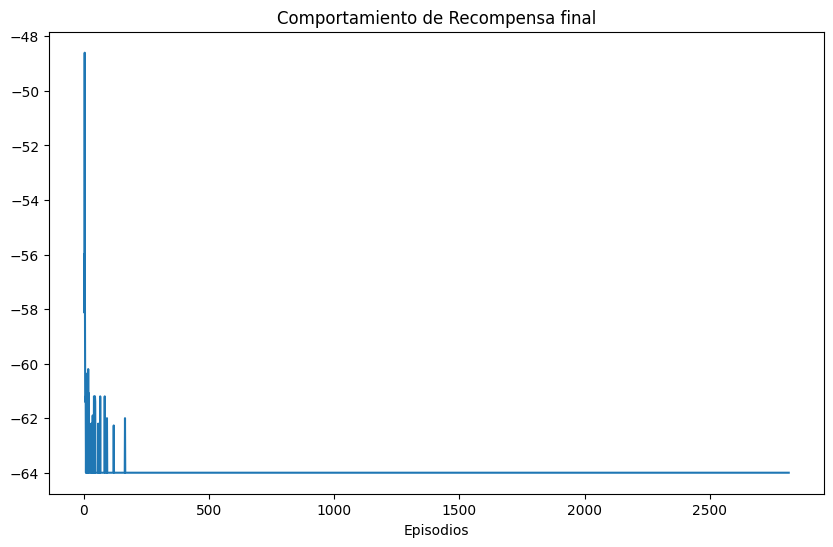

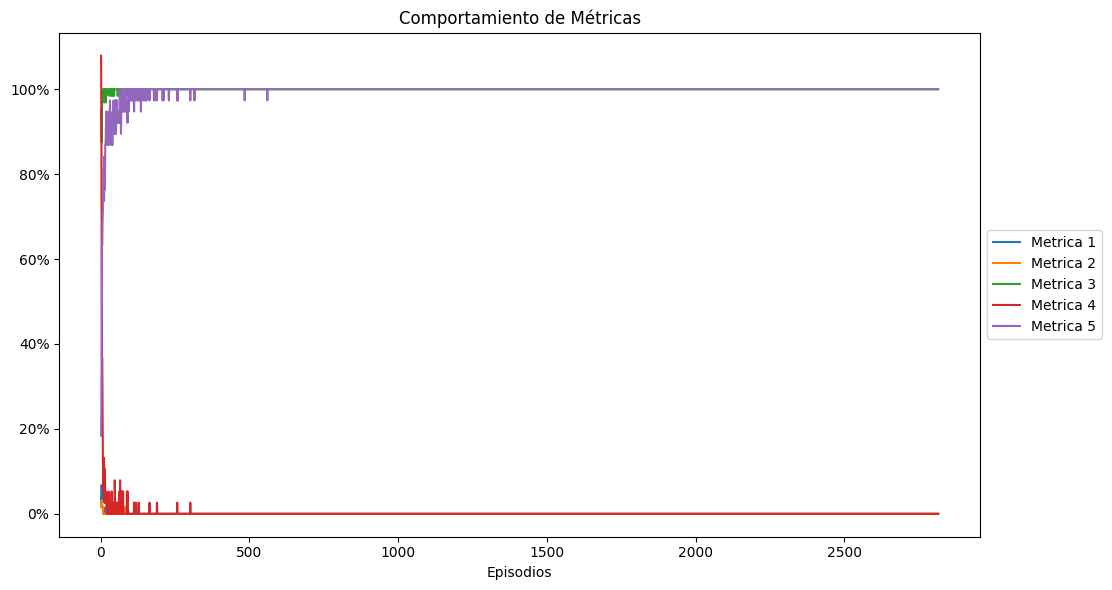

In [26]:
from stable_baselines3 import PPO

BASE_NAME = "ppo_alpha_08"

# Obtén el archivo de la última versión
latest_model_filename = get_latest_model_filename(base_name=BASE_NAME)

# Carga el modelo si existe
if latest_model_filename:
    print(f"Cargando modelo: {latest_model_filename}")
    model = PPO.load(latest_model_filename, env=env)
else:
    print("No se encontró ningún modelo anterior, entrenando desde cero.")
    model = PPO("MlpPolicy", env)

model.learn(total_timesteps=180_000)

# Obtén el siguiente nombre de archivo disponible
model_filename = get_next_model_filename(base_name=BASE_NAME)

# Guarda el modelo
model.save(model_filename)
print(f"Modelo guardado en: {model_filename}")

# Guarda los rewards en un archivo CSV
save_rewards_to_csv(env.all_rewards, filename=f"{model_filename}.csv")
print(f"Metricas guardados en {model_filename}.csv")

graph_metrics(csv_file = f"{model_filename}.csv")

# DQN

# Markov Decision Processes con Policy Iteration

In [ ]:
import numpy as np

# Parámetros del problema
max_telematica = 3  # Máximo número de estudiantes de Ingeniería Civil Telemática en un grupo
desafios = [...]  # Lista de desafíos
estudiantes = [...]  # Lista de estudiantes

# Función de recompensa
def recompensa(asignacion):
    total_recompensa = 0
    for grupo in asignacion:
        carreras = [estudiante['Carrera'] for estudiante in grupo]
        # Penaliza si hay más de un estudiante de la misma carrera (excepto Telemática)
        for carrera in set(carreras):
            maximo = 3 if carrera == 'Ingeniería Civil Telemática' else 1
            if carreras.count(carrera) > maximo:
                total_recompensa -= 10  # Penalización por violar las restricciones
        # Recompensa por asignar estudiantes a sus desafíos de mayor prioridad
        for estudiante in grupo:
            prioridad = estudiante['Postulaciones'].index(grupo['desafio'])
            total_recompensa += (3 - prioridad)  # Mayor recompensa para mayor prioridad
    return total_recompensa

# Función de transición (definiendo cómo se mueve de un estado a otro)
def transicion(estado, accion):
    nuevo_estado = estado.copy()
    # Implementa la lógica para mover estudiantes entre desafíos respetando restricciones
    # Aquí se puede aplicar la acción al estado actual
    return nuevo_estado

# Función para calcular el valor de una política
def evaluar_politica(politica, gamma=0.9, iteraciones=100):
    V = np.zeros(len(politica))  # Valor inicial para todos los estados
    for i in range(iteraciones):
        for s in range(len(politica)):
            accion = politica[s]
            nuevo_estado = transicion(s, accion)
            V[s] = recompensa(nuevo_estado) + gamma * V[nuevo_estado]
    return V

# Iteración de política
def iteracion_politica(estados, acciones):
    politica = np.zeros(len(estados))  # Política inicial (aleatoria o simple)
    while True:
        # Evaluar la política actual
        V = evaluar_politica(politica)
        nueva_politica = np.zeros(len(estados))
        # Mejorar la política
        for s in range(len(estados)):
            # Selecciona la mejor acción para el estado actual
            nueva_politica[s] = np.argmax([recompensa(transicion(s, a)) for a in acciones])
        if np.array_equal(politica, nueva_politica):
            break
        politica = nueva_politica
    return politica

# Ejecución del algoritmo
politica_optima = iteracion_politica(estados, acciones)
print("Política óptima:", politica_optima)


In [74]:
estudiantes = [
        {
            "Nombre": "Matias Ignacio Ayala Nanjari",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones."
            ]
        },
        {
            "Nombre": "Ignacio Andrés Araya Salinas",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones."
            ]
        },
        {
            "Nombre": "Camila Fernanda Guerrero Bustamante",
            "Carrera": "Construcción Civil",
            "Postulaciones": [
                "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.",
                "Diseño y manufactura de prototipo industrial de un equipo térmico que utilice Hidrógeno como combustible, economicamente viable para la industria chilena."
            ]
        },
        {
            "Nombre": "Simón Josías Cristóbal Álvarez Díaz",
            "Carrera": "Otras",
            "Postulaciones": [
                "Mobile Water Quality Monitoring for Offshore Fish Farms",
                "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.",
                "Mejorar la experiencia de entrega a cliente a Nivel Nacional"
            ]
        },
        {
            "Nombre": "Fernanda Ivonne Viera Castillo    ",
            "Carrera": "Construcción Civil",
            "Postulaciones": [
                "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.",
                "Creación Modelo Revenue Management Menaje Easy",
                "Mapeo de zonas rojas de apps de delivery"
            ]
        },
        {
            "Nombre": "Manuel Cruces Pirce",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Plataforma Educacional (LMS) para Coding Dojo Latam",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales."
            ]
        },
        {
            "Nombre": "Carlos Alfredo Cea Rios",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Electric Vehicle as a Service (EVaaS)",
                "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales."
            ]
        },
        {
            "Nombre": "Miguel Cabezas",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "Mejorar la experiencia de entrega a cliente a Nivel Nacional",
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Georeferenciación y Normalización de Direcciones"
            ]
        },
        {
            "Nombre": "Valentina Paz Lobos Páez",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "¿Como aprovechar la IA para facilitar la actividad de los profesores en la educación de nuestro pais?",
                "Mejorar la experiencia de entrega a cliente a Nivel Nacional"
            ]
        },
        {
            "Nombre": "Diego Escobar",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "Modulación digital de flujos de procesos enológicos de vendimia",
                "Mejorar la experiencia de entrega a cliente a Nivel Nacional",
                "Mapeo de zonas rojas de apps de delivery"
            ]
        },
        {
            "Nombre": "Juan Pablo Oyanedel",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "Modulación digital de flujos de procesos enológicos de vendimia",
                "Mejorar la experiencia de entrega a cliente a Nivel Nacional",
                "Modelo de Predicción y Correlación - Clima HR Analytics"
            ]
        },
        {
            "Nombre": "Wuendy Arlyns Arriagada Catacora",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "Modelo de control de consumo EPP y ropa de trabajo para la circularidad de elementos en desuso",
                "Modulación digital de flujos de procesos enológicos de vendimia",
                "Mejorar la experiencia de entrega a cliente a Nivel Nacional"
            ]
        },
        {
            "Nombre": "Brian Montero",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Electric Vehicle as a Service (EVaaS)",
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA.",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego."
            ]
        },
        {
            "Nombre": "Felipe Marquez",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Plataforma Configurable de Interfaz para Dispositivos de Telemetría en WOLKE",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.",
                "Electric Vehicle as a Service (EVaaS)"
            ]
        },
        {
            "Nombre": "Francisco Lopez Figueroa",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Mobile Water Quality Monitoring for Offshore Fish Farms",
                "Electric Vehicle as a Service (EVaaS)",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego."
            ]
        },
        {
            "Nombre": "Karolain Yarely Cabrera Cabrera",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Mobile Water Quality Monitoring for Offshore Fish Farms",
                "Electric Vehicle as a Service (EVaaS)",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego."
            ]
        },
        {
            "Nombre": "Gabriela González",
            "Carrera": "Ingeniería en Diseño de Productos",
            "Postulaciones": [
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.",
                "Electric Vehicle as a Service (EVaaS)",
                "Modulación digital de flujos de procesos enológicos de vendimia"
            ]
        },
        {
            "Nombre": "cristhian Urra Aldunate",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Mobile Water Quality Monitoring for Offshore Fish Farms",
                "Sistema de posicionamiento de robot submarino en jaula de cultivo mediante telemetría y estéreo visión.",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro"
            ]
        },
        {
            "Nombre": "Juan del Valle",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.",
                "Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.",
                "Clasificación de imágenes de mamografía usando Machine Learning"
            ]
        },
        {
            "Nombre": "Catalina Angélica Ulloa Fritz",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones."
            ]
        },
        {
            "Nombre": "Agustin Nicolas Ovando Saenz",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollar un sistema de correlación de datos de diversas plataformas de seguridad para identificar patrones y relaciones entre eventos aparentemente no relacionados y estimar riesgos de ciberseguridad",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego."
            ]
        },
        {
            "Nombre": "Gonzalo Soto Ulloa",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollar un sistema de correlación de datos de diversas plataformas de seguridad para identificar patrones y relaciones entre eventos aparentemente no relacionados y estimar riesgos de ciberseguridad",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego."
            ]
        },
        {
            "Nombre": "Sebastian Jara",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollar un sistema de correlación de datos de diversas plataformas de seguridad para identificar patrones y relaciones entre eventos aparentemente no relacionados y estimar riesgos de ciberseguridad",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego."
            ]
        },
        {
            "Nombre": "Benjamin Pino Olivares",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollar un sistema de correlación de datos de diversas plataformas de seguridad para identificar patrones y relaciones entre eventos aparentemente no relacionados y estimar riesgos de ciberseguridad",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.",
                "Desarrollo de un Software para Automatizar Operaciones de Análisis de Genómica Funcional en Hongos"
            ]
        },
        {
            "Nombre": "Claudio Blas Arnaldo Santana Dominguez",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Quantum Challengue: Simular en un computador cuántico el comportamiento QKD en Base a Protocolo BB84.",
                "Atlas/Bitácora de Casos Oncológicos Complejos",
                "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego."
            ]
        },
        {
            "Nombre": "Matías Yamil Soto Sepúlveda",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.",
                "Sistema de Localización en Tiempo Real (RTLS) de pacientes dentro de una clínica basado en machine learning",
                "Caracterización del canal inalámbrico empleando tecnología IoT"
            ]
        },
        {
            "Nombre": "Battá Tomás Tuki Cadenas",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Georeferenciación y Normalización de Direcciones"
            ]
        },
        {
            "Nombre": "Nicolás Eduardo Salas Barrantes",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "OptiDataLake: Plataforma de Gestión y Análisis de Market Data",
                "People Analytics - Talento y Desarrollo",
                "Georeferenciación y Normalización de Direcciones"
            ]
        },
        {
            "Nombre": "Javiera Díaz Mesina",
            "Carrera": "Ingeniería Comercial",
            "Postulaciones": [
                "People Analytics - Talento y Desarrollo",
                "Diseño y manufactura de prototipo industrial de un equipo térmico que utilice Hidrógeno como combustible, economicamente viable para la industria chilena."
            ]
        },
        {
            "Nombre": "Mariapaz Gómez Godoy",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "OptiDataLake: Plataforma de Gestión y Análisis de Market Data",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro",
                "¿Como aprovechar la IA para facilitar la actividad de los profesores en la educación de nuestro pais?"
            ]
        },
        {
            "Nombre": "Benjamín Nicolás Miranda Muñoz",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "Plataforma Educacional (LMS) para Coding Dojo Latam",
                "Modulación digital de flujos de procesos enológicos de vendimia",
                "People Analytics - Talento y Desarrollo"
            ]
        },
        {
            "Nombre": "Thomas Soto",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Miido - tecnología para optimizar el uso de fertilizantes en agro",
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Atlas/Bitácora de Casos Oncológicos Complejos"
            ]
        },
        {
            "Nombre": "Nicolás Andrés Ruiz Ruiz",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro"
            ]
        },
        {
            "Nombre": "Vicente Ignacio Carreño Escobar",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro"
            ]
        },
        {
            "Nombre": "Marcelo Andre Garcia Ramos",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollo de un Software para Automatizar Operaciones de Análisis de Genómica Funcional en Hongos",
                "Plataforma Educacional (LMS) para Coding Dojo Latam",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro"
            ]
        },
        {
            "Nombre": "FARID DÍAZ",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollo de un Software para Automatizar Operaciones de Análisis de Genómica Funcional en Hongos",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro",
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA."
            ]
        },
        {
            "Nombre": "Cristian Vega",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Miido - tecnología para optimizar el uso de fertilizantes en agro",
                "Sistema de Localización en Tiempo Real (RTLS) de pacientes dentro de una clínica basado en machine learning",
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA."
            ]
        },
        {
            "Nombre": "Fabian Esteban Godoy Casas",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollo de un Software para Automatizar Operaciones de Análisis de Genómica Funcional en Hongos",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro"
            ]
        },
        {
            "Nombre": "Santiago Lopez",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Miido - tecnología para optimizar el uso de fertilizantes en agro",
                "Modelo de Predicción y Correlación - Clima HR Analytics"
            ]
        },
        {
            "Nombre": "Ariel Bravo Ponce",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "OptiDataLake: Plataforma de Gestión y Análisis de Market Data",
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA.",
                "Clasificación de imágenes de mamografía usando Machine Learning"
            ]
        },
        {
            "Nombre": "Gianfranco Rolla Teneos",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "OptiDataLake: Plataforma de Gestión y Análisis de Market Data",
                "Rutas de inspección visual del espacio público urbano",
                "Desarrollar un sistema de correlación de datos de diversas plataformas de seguridad para identificar patrones y relaciones entre eventos aparentemente no relacionados y estimar riesgos de ciberseguridad"
            ]
        },
        {
            "Nombre": "Jeremy Andrew Joy Immediato",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Administrador de Diccionarios de Datos",
                "OptiDataLake: Plataforma de Gestión y Análisis de Market Data"
            ]
        },
        {
            "Nombre": "Vania Schatloff",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "OptiDataLake: Plataforma de Gestión y Análisis de Market Data",
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA."
            ]
        },
        {
            "Nombre": "Vicente Alvear",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "OptiDataLake: Plataforma de Gestión y Análisis de Market Data",
                "Modelo de Predicción y Correlación - Clima HR Analytics"
            ]
        },
        {
            "Nombre": "Cristóbal Antonio Nilo Garrido",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Rutas de inspección visual del espacio público urbano",
                "Mapeo de zonas rojas de apps de delivery",
                "Uso de LLMs para masificar la explotación de datos en Falp"
            ]
        },
        {
            "Nombre": "Vicente Andrés Llanos Álvarez",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Mapeo de zonas rojas de apps de delivery",
                "Rutas de inspección visual del espacio público urbano"
            ]
        },
        {
            "Nombre": "Felipe Williams Francisco Rodriguez Rodriguez",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Mapeo de zonas rojas de apps de delivery",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Plataforma Educacional (LMS) para Coding Dojo Latam"
            ]
        },
        {
            "Nombre": "Jorge Antonio Rojas Huaiquimilla",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Rutas de inspección visual del espacio público urbano",
                "Mapeo de zonas rojas de apps de delivery",
                "Desarrollar un sistema de correlación de datos de diversas plataformas de seguridad para identificar patrones y relaciones entre eventos aparentemente no relacionados y estimar riesgos de ciberseguridad"
            ]
        },
        {
            "Nombre": "Fabián Elías Soto morales",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Mapeo de zonas rojas de apps de delivery"
            ]
        },
        {
            "Nombre": "hsien-i lee",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Mapeo de zonas rojas de apps de delivery"
            ]
        },
        {
            "Nombre": "Constanza Javiera Corday Loayza",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Modelo de Predicción y Correlación - Clima HR Analytics",
                "Mapeo de zonas rojas de apps de delivery"
            ]
        },
        {
            "Nombre": "Martín Alejandro Rojas Moya",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Modelo de Predicción y Correlación - Clima HR Analytics",
                "Mapeo de zonas rojas de apps de delivery"
            ]
        },
        {
            "Nombre": "Alexander Alfaro",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Administrador de Diccionarios de Datos",
                "Plataforma Configurable de Interfaz para Dispositivos de Telemetría en WOLKE",
                "Rutas de inspección visual del espacio público urbano"
            ]
        },
        {
            "Nombre": "Mauricio Ignacio Carvajal Andrade",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Rutas de inspección visual del espacio público urbano",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Sistema para la limpieza automatizada de riel de Tripper minero"
            ]
        },
        {
            "Nombre": "Sergio Rojas Escanilla",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA.",
                "Atlas/Bitácora de Casos Oncológicos Complejos",
                "Clasificación de imágenes de mamografía usando Machine Learning"
            ]
        },
        {
            "Nombre": "Jonathan Ignacio Abraham Pedraza Valdebenito",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA."
            ]
        },
        {
            "Nombre": "Julio Aníbal Maturana Solís",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Sistema de Localización en Tiempo Real (RTLS) de pacientes dentro de una clínica basado en machine learning",
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA."
            ]
        },
        {
            "Nombre": "JUAN PATRICIO ARDILES CASTILLO",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA."
            ]
        },
        {
            "Nombre": "Cristhofer Brian Ruben Araya Recabarren",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Administrador de Diccionarios de Datos",
                "Plataforma Configurable de Interfaz para Dispositivos de Telemetría en WOLKE",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud"
            ]
        },
        {
            "Nombre": "José Ignacio Alegría Vergara",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Modelo de Predicción y Correlación - Clima HR Analytics"
            ]
        },
        {
            "Nombre": "Marcelo Esteban Díaz Moya",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Modelo de Predicción y Correlación - Clima HR Analytics"
            ]
        },
        {
            "Nombre": "Benjamín Rodrigo Aros Báez",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Uso de LLMs para masificar la explotación de datos en Falp",
                "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
                "Normalizacion de Datos Categóricos"
            ]
        },
        {
            "Nombre": "Javier Ahumada",
            "Carrera": "Ingeniería Civil Telemática",
            "Postulaciones": [
                "Miido - tecnología para optimizar el uso de fertilizantes en agro",
                "Clasificación de imágenes de mamografía usando Machine Learning",
                "¿Como aprovechar la IA para facilitar la actividad de los profesores en la educación de nuestro pais?"
            ]
        },
        {
            "Nombre": "Benjamin Vicuña",
            "Carrera": "Ingeniería Civil Industrial",
            "Postulaciones": [
                "People Analytics - Talento y Desarrollo",
                "Mejorar la experiencia de entrega a cliente a Nivel Nacional",
                "Modelo de control de consumo EPP y ropa de trabajo para la circularidad de elementos en desuso"
            ]
        }
    ]

In [73]:
desafios = [
        {
            "Titulo": "SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.",
            "Carreras": [
                "Arquitectura",
                "Ingeniería Civil Ambiental",
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Mejorar la experiencia de entrega a cliente a Nivel Nacional",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática",
                "Ingeniería Comercial",
                "Ingeniería en Diseño de Productos",
                "Otras"
            ]
        },
        {
            "Titulo": "Electric Vehicle as a Service (EVaaS)",
            "Carreras": [
                "Ingeniería Civil Eléctrica",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Mobile Water Quality Monitoring for Offshore Fish Farms",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Creación Modelo Revenue Management Menaje Easy",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática",
                "Ingeniería Comercial",
                "Ingeniería en Diseño de Productos",
                "Otras"
            ]
        },
        {
            "Titulo": "Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.",
            "Carreras": [
                "Ingeniería Civil Eléctrica",
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Caracterización del canal inalámbrico empleando tecnología IoT",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Sistema de posicionamiento de robot submarino en jaula de cultivo mediante telemetría y estéreo visión.",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Georeferenciación y Normalización de Direcciones",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Ambiental",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Otras"
            ]
        },
        {
            "Titulo": "Diseño y manufactura de prototipo industrial de un equipo térmico que utilice Hidrógeno como combustible, economicamente viable para la industria chilena.",
            "Carreras": [
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Mecánica",
                "Ingeniería Civil Química",
                "Otras",
                "Ingeniería Civil Ambiental",
                "Ingeniería Comercial"
            ]
        },
        {
            "Titulo": "¿Como aprovechar la IA para facilitar la actividad de los profesores en la educación de nuestro pais?",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática",
                "Ingeniería Comercial",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "People Analytics - Talento y Desarrollo",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática",
                "Ingeniería Comercial",
                "Ingeniería en Diseño de Productos",
                "Otras"
            ]
        },
        {
            "Titulo": "Miido - tecnología para optimizar el uso de fertilizantes en agro",
            "Carreras": [
                "Ingeniería Civil Ambiental",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "OptiDataLake: Plataforma de Gestión y Análisis de Market Data",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática",
                "Ingeniería Comercial",
                "Otras"
            ]
        },
        {
            "Titulo": "Quantum Challengue: Simular en un computador cuántico el comportamiento QKD en Base a Protocolo BB84.",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Desarrollo de un Software para Automatizar Operaciones de Análisis de Genómica Funcional en Hongos",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería Civil Química",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Mapeo de zonas rojas de apps de delivery",
            "Carreras": [
                "Arquitectura",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Rutas de inspección visual del espacio público urbano",
            "Carreras": [
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA.",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Plataforma Configurable de Interfaz para Dispositivos de Telemetría en WOLKE",
            "Carreras": [
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Modelo de Predicción y Correlación - Clima HR Analytics",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática",
                "Ingeniería Comercial",
                "Ingeniería en Diseño de Productos",
                "Otras"
            ]
        },
        {
            "Titulo": "Modulación digital de flujos de procesos enológicos de vendimia",
            "Carreras": [
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Plataforma Educacional (LMS) para Coding Dojo Latam",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería en Diseño de Productos",
                "Otras"
            ]
        },
        {
            "Titulo": "Normalizacion de Datos Categóricos",
            "Carreras": [
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Otras"
            ]
        },
        {
            "Titulo": "Administrador de Diccionarios de Datos",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Otras"
            ]
        },
        {
            "Titulo": "Uso de LLMs para masificar la explotación de datos en Falp",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Industrial",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Otras"
            ]
        },
        {
            "Titulo": "Atlas/Bitácora de Casos Oncológicos Complejos",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos",
                "Otras"
            ]
        },
        {
            "Titulo": "Sistema para el control y mejora de la limpieza industrial bajo correa transportadora en minería para contratos de aseo industrial NEXXO",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Sistema para la limpieza automatizada de riel de Tripper minero",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Mecánica",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Simulación y control de las velocidades de la solución química al interior de los paneles de tubos de calderas para una limpieza química",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Química"
            ]
        },
        {
            "Titulo": "Modelo de control de consumo EPP y ropa de trabajo para la circularidad de elementos en desuso",
            "Carreras": [
                "Ingeniería Civil Ambiental",
                "Ingeniería Civil Industrial",
                "Ingeniería Comercial"
            ]
        },
        {
            "Titulo": "Clasificación de imágenes de mamografía usando Machine Learning",
            "Carreras": [
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Sistema de Localización en Tiempo Real (RTLS) de pacientes dentro de una clínica basado en machine learning",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Eléctrica",
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud",
            "Carreras": [
                "Ingeniería Civil",
                "Ingeniería Civil Eléctrica",
                "Ingeniería Civil Electrónica",
                "Ingeniería Civil Informática",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Desarrollar un sistema de correlación de datos de diversas plataformas de seguridad para identificar patrones y relaciones entre eventos aparentemente no relacionados y estimar riesgos de ciberseguridad",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática"
            ]
        },
        {
            "Titulo": "Implementar un sistema de revision y generación de informes automatizados que resuma el estado de seguridad de la red, incluyendo recomendaciones para mejoras.",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática",
                "Ingeniería en Diseño de Productos"
            ]
        },
        {
            "Titulo": "Implementacion de sistema que permita gestionar incidentes de ciberseguridad",
            "Carreras": [
                "Ingeniería Civil Informática",
                "Ingeniería Civil Matemática",
                "Ingeniería Civil Telemática"
            ]
        }
    ]

for id in range(len(desafios)):
    desafios[id]["id"] = id

desafios

[{'Titulo': 'SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.',
  'Carreras': ['Arquitectura',
   'Ingeniería Civil Ambiental',
   'Ingeniería Civil Electrónica',
   'Ingeniería Civil Informática',
   'Ingeniería Civil Matemática',
   'Ingeniería Civil Telemática',
   'Ingeniería en Diseño de Productos'],
  'id': 0},
 {'Titulo': 'Mejorar la experiencia de entrega a cliente a Nivel Nacional',
  'Carreras': ['Ingeniería Civil',
   'Ingeniería Civil Industrial',
   'Ingeniería Civil Informática',
   'Ingeniería Civil Telemática',
   'Ingeniería Comercial',
   'Ingeniería en Diseño de Productos',
   'Otras'],
  'id': 1},
 {'Titulo': 'Electric Vehicle as a Service (EVaaS)',
  'Carreras': ['Ingeniería Civil Eléctrica', 'Ingeniería Civil Telemática'],
  'id': 2},
 {'Titulo': 'Mobile Water Quality Monitoring for Offshore Fish Farms',
  'Carreras': ['Ingeniería Civil Electrónica',
   'Ingeniería Civil Telemática',
   'Ingeniería en Diseño de Productos'],
 

In [60]:
# Parámetros del problema
num_estudiantes = len(estudiantes)  # Número de estudiantes, ajustar según el dataset
num_desafios = len(desafios)  # Número de desafíos, ajustar según el dataset

In [64]:
from collections import defaultdict

# Restricciones
max_telematica = 3
max_grupo = 4
min_grupo = 2  # Mínimo número de estudiantes por grupo

# Información de los desafíos y estudiantes (simplificada para este ejemplo)
# desafios = [f'Desafio {i}' for i in range(38)]
# estudiantes = [...]  # Lista de estudiantes con su información de carrera y postulaciones

# Diccionario para contar estudiantes por carrera en cada desafío
desafio_carreras = {desafio: defaultdict(int) for desafio in desafios}
grupos_desafios = {desafio: [] for desafio in desafios}

# Función para verificar que todos los grupos tengan al menos 2 estudiantes
def validar_grupos_minimos(grupos_desafios):
    for desafio, grupo in grupos_desafios.items():
        if len(grupo) > 0 and len(grupo) < min_grupo:
            return False
    return True

# Backtracking para construir los estados válidos
def generar_asignaciones(estudiante_idx, asignacion_actual, estudiantes, desafios):
    # Caso base: si hemos asignado a todos los estudiantes, validamos los grupos
    if estudiante_idx == len(estudiantes):
        if validar_grupos_minimos(grupos_desafios):
            return [asignacion_actual.copy()]
        return []  # Estado inválido si algún grupo no tiene al menos 2 estudiantes

    estudiante = estudiantes[estudiante_idx]
    carrera = estudiante['Carrera']
    postulaciones = estudiante['Postulaciones']

    estados_validos = []
    asignado = False

    # Intentar asignar al estudiante a uno de sus desafíos postulados
    for desafio in postulaciones:
        if len(grupos_desafios[desafio]) < max_grupo:  # Verificar que el grupo no está lleno
            # Verificar las restricciones de carrera
            if carrera == 'Ingeniería Civil Telemática':
                if desafio_carreras[desafio][carrera] < max_telematica:
                    # Asignar estudiante
                    grupos_desafios[desafio].append(estudiante_idx)
                    desafio_carreras[desafio][carrera] += 1
                    asignacion_actual[estudiante_idx] = desafio
                    asignado = True

                    # Continuar con el siguiente estudiante
                    estados_validos += generar_asignaciones(estudiante_idx + 1, asignacion_actual, estudiantes, desafios)

                    # Deshacer la asignación (backtrack)
                    grupos_desafios[desafio].pop()
                    desafio_carreras[desafio][carrera] -= 1
            else:
                if desafio_carreras[desafio][carrera] < 1:
                    # Asignar estudiante
                    grupos_desafios[desafio].append(estudiante_idx)
                    desafio_carreras[desafio][carrera] += 1
                    asignacion_actual[estudiante_idx] = desafio
                    asignado = True

                    # Continuar con el siguiente estudiante
                    estados_validos += generar_asignaciones(estudiante_idx + 1, asignacion_actual, estudiantes, desafios)

                    # Deshacer la asignación (backtrack)
                    grupos_desafios[desafio].pop()
                    desafio_carreras[desafio][carrera] -= 1

    # Si no se pudo asignar a ninguno de los desafíos postulados, asignar a cualquier otro desafío
    if not asignado:
        for desafio in desafios:
            if len(grupos_desafios[desafio]) < max_grupo:
                if carrera == 'Ingeniería Civil Telemática':
                    if desafio_carreras[desafio][carrera] < max_telematica:
                        # Asignar estudiante al desafío disponible
                        grupos_desafios[desafio].append(estudiante_idx)
                        desafio_carreras[desafio][carrera] += 1
                        asignacion_actual[estudiante_idx] = desafio

                        # Continuar con el siguiente estudiante
                        estados_validos += generar_asignaciones(estudiante_idx + 1, asignacion_actual, estudiantes, desafios)

                        # Deshacer la asignación (backtrack)
                        grupos_desafios[desafio].pop()
                        desafio_carreras[desafio][carrera] -= 1
                else:
                    if desafio_carreras[desafio][carrera] < 1:
                        # Asignar estudiante al desafío disponible
                        grupos_desafios[desafio].append(estudiante_idx)
                        desafio_carreras[desafio][carrera] += 1
                        asignacion_actual[estudiante_idx] = desafio

                        # Continuar con el siguiente estudiante
                        estados_validos += generar_asignaciones(estudiante_idx + 1, asignacion_actual, estudiantes, desafios)

                        # Deshacer la asignación (backtrack)
                        grupos_desafios[desafio].pop()
                        desafio_carreras[desafio][carrera] -= 1

    return estados_validos

# Función para inicializar el proceso
def construir_estados(estudiantes, desafios):
    asignacion_inicial = [-1] * len(estudiantes)  # -1 indica que el estudiante no ha sido asignado a ningún desafío
    return generar_asignaciones(0, asignacion_inicial, estudiantes, desafios)

# Ejecutar el algoritmo
estados = construir_estados(estudiantes, desafios)
print(f"Se generaron {len(estados)} estados válidos")


KeyError: 'SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.'

In [86]:
from collections import defaultdict
import copy  # Importamos deepcopy para hacer copias profundas

# # Lista de desafíos y sus restricciones de carreras
# desafios = [
#     # El formato sería algo como {"id": 1, "nombre": "desafio1", "carreras": ["Ingeniería Civil", "Ingeniería Civil Telemática"]}
#     # Completar con todos los desafíos y sus carreras permitidas
# ]

# # Estudiantes y sus respectivas carreras
# estudiantes = [
#     # Ejemplo de estudiantes con sus carreras, algo como {"id": 1, "carrera": "Ingeniería Civil Telemática"}
#     # Completar con todos los estudiantes
# ]

# Función para verificar si una asignación de estudiantes a un desafío es válida
def es_asignacion_valida(asignacion, desafio, carrera):
    global estudiantes
    # Verificar si la carrera está permitida en el desafío
    if carrera not in desafio['Carreras']:
        return False

    # Contar la cantidad de estudiantes de cada carrera ya asignados a este desafío
    contador_carreras = defaultdict(int)
    for estudiante_id in asignacion:
        carrera_estudiante = estudiantes[estudiante_id]['Carrera']
        contador_carreras[carrera_estudiante] += 1

    # Restricciones: máximo de 3 de Telemática, 1 de otras carreras, máximo de 4 estudiantes en total
    if carrera == "Ingeniería Civil Telemática" and contador_carreras["Ingeniería Civil Telemática"] >= 3:
        return False
    if carrera != "Ingeniería Civil Telemática" and contador_carreras[carrera] >= 1:
        return False
    if len(asignacion) >= 4:
        print("lol")
        return False

    return True

# Función de backtracking para generar los estados
def generar_estados(estudiante_idx, asignaciones_actuales):
    global estudiantes
    global desafios
    if estudiante_idx == len(estudiantes):
        # Si hemos asignado a todos los estudiantes, retornamos la asignación actual
        return [copy.deepcopy(asignaciones_actuales)]  # Hacer una copia profunda de las asignaciones

    estudiante = estudiantes[estudiante_idx]
    carrera = estudiante['Carrera']
    estados_validos = []

    for desafio in desafios:

        asignacion_actual = asignaciones_actuales.get(desafio['id'], [])
        hmm = es_asignacion_valida(asignacion_actual, desafio, carrera)
        # print(hmm)
        if hmm:
            # Asignar al estudiante al desafío actual
            asignacion_actual.append(estudiante_idx)
            # print(estudiante_idx, desafio["id"])
            asignaciones_actuales[desafio['id']] = asignacion_actual

            # Recursión para el siguiente estudiante
            estados_validos += generar_estados(estudiante_idx + 1, asignaciones_actuales)

            # Deshacer la asignación (backtrack)
            asignacion_actual.pop()

    return estados_validos

# Inicialización de las asignaciones y generación de los estados
asignaciones_iniciales = {}
estados_validos = generar_estados(0, asignaciones_iniciales)
estados_validos


[]

In [79]:
asignaciones_iniciales

{0: [],
 1: [],
 2: [],
 3: [],
 4: [],
 5: [],
 6: [],
 7: [],
 8: [],
 11: [],
 12: [],
 13: [],
 14: [],
 15: [],
 16: [],
 17: [],
 18: [],
 19: [],
 20: [],
 21: [],
 27: [],
 28: [],
 29: [],
 32: [],
 33: [],
 34: [],
 35: [],
 36: [],
 37: []}

In [50]:
import numpy as np

# Parámetros del problema
num_estudiantes = len(estudiantes)  # Número de estudiantes, ajustar según el dataset
num_desafios = len(desafios)  # Número de desafíos, ajustar según el dataset
max_telematica = 3  # Máximo de estudiantes de Ingeniería Civil Telemática en un desafío

# Inicializa las listas de estudiantes y desafíos
# desafios = [...]  # Lista de desafíos (indexados por su posición)
# estudiantes = [...]  # Lista de estudiantes con su carrera y postulaciones

# Función de recompensa
def recompensa(estado):
    total_recompensa = 0
    desafio_asignaciones = {i: [] for i in range(num_desafios)}  # Para contar asignaciones por desafío

    for i, desafio in enumerate(estado):
        estudiante = estudiantes[i]
        carrera = estudiante['Carrera']
        postulaciones = estudiante['Postulaciones']
        desafio_asignaciones[desafio].append(carrera)

        # Recompensa basada en la prioridad de la asignación
        if desafio in postulaciones:
            prioridad = postulaciones.index(desafio)
            total_recompensa += (3 - prioridad)  # Mayor recompensa para mayor prioridad

    # Verificar las restricciones de las carreras
    for desafio, asignados in desafio_asignaciones.items():
        # Penalizar si hay más de un estudiante de la misma carrera (excepto Telemática)
        for carrera in set(asignados):
            maximo = 3 if carrera == 'Ingeniería Civil Telemática' else 1
            if asignados.count(carrera) > maximo:
                total_recompensa -= 10  # Penalización por exceder el límite

    return total_recompensa

# Función de transición (asigna un desafío a un estudiante)
def transicion(estado, estudiante, desafio):
    nuevo_estado = estado.copy()
    nuevo_estado[estudiante] = desafio
    return nuevo_estado

# Política inicial: asigna desafíos aleatoriamente
def generar_estado_inicial():
    return np.random.choice(range(num_desafios), size=num_estudiantes).tolist()

# Evaluación de una política
def evaluar_politica(politica, gamma=0.9, iteraciones=10000):
    V = np.zeros(len(politica))  # Valor inicial para todos los estados
    for i in range(iteraciones):
        for s in range(len(politica)):
            estado_actual = politica[s]
            valor_accion = recompensa(estado_actual)
            V[s] = valor_accion + gamma * V[s]
    return V

# Iteración de política
def iteracion_politica(estados, acciones):
    politica = [generar_estado_inicial() for _ in estados]  # Política inicial aleatoria
    while True:
        # Evaluar la política actual
        V = evaluar_politica(politica)
        nueva_politica = []

        # Mejorar la política
        for estado in politica:
            mejor_estado = max([transicion(estado, estudiante, desafio)
                                for estudiante in range(num_estudiantes)
                                for desafio in range(num_desafios)],
                               key=recompensa)
            nueva_politica.append(mejor_estado)

        if np.array_equal(politica, nueva_politica):
            break  # Detener si la política no cambia
        politica = nueva_politica

    return politica

# Ejecutar el algoritmo
estados = [generar_estado_inicial() for _ in range(10)]  # Generar varios estados iniciales
acciones = list(range(num_desafios))
politica_optima = iteracion_politica(estados, acciones)

print("Política óptima:", politica_optima)


Política óptima: [[2, 30, 2, 7, 37, 34, 24, 9, 4, 18, 0, 4, 6, 5, 33, 12, 20, 35, 15, 9, 21, 18, 28, 7, 22, 30, 20, 14, 28, 4, 4, 20, 1, 25, 0, 9, 29, 24, 31, 37, 2, 1, 3, 10, 32, 26, 5, 2, 8, 14, 1, 29, 0, 20, 19, 1, 8, 36, 14, 16, 31, 0, 3, 36], [1, 35, 24, 1, 5, 4, 24, 0, 7, 8, 28, 5, 0, 1, 5, 17, 27, 7, 10, 24, 22, 10, 20, 4, 2, 3, 18, 1, 6, 26, 35, 16, 2, 27, 21, 14, 6, 35, 28, 26, 3, 37, 10, 0, 5, 11, 5, 22, 20, 9, 33, 34, 29, 4, 21, 24, 1, 25, 7, 16, 0, 22, 31, 23], [0, 33, 7, 31, 36, 32, 4, 27, 15, 3, 0, 23, 9, 13, 10, 13, 36, 22, 29, 2, 24, 31, 23, 30, 26, 5, 9, 1, 19, 3, 24, 17, 5, 10, 32, 0, 16, 9, 20, 27, 14, 29, 33, 19, 33, 28, 21, 27, 35, 28, 24, 11, 11, 14, 19, 5, 27, 28, 26, 7, 9, 31, 3, 32], [1, 36, 21, 30, 16, 34, 27, 14, 10, 0, 1, 25, 0, 33, 0, 33, 36, 0, 13, 8, 27, 31, 1, 12, 22, 32, 27, 34, 36, 35, 26, 33, 20, 25, 32, 11, 9, 37, 23, 24, 29, 11, 4, 23, 8, 5, 11, 35, 5, 15, 11, 36, 26, 24, 16, 4, 35, 13, 32, 8, 19, 26, 9, 18], [3, 10, 6, 33, 23, 12, 25, 7, 27, 5, 14,

In [51]:
for i in range(63):
    print(f"{nombres_estudiantes[i]}: {desafios[politica_optima[0][i]]['Titulo']} con preferencias {estudiantes[i]['Postulaciones']}")


Matias Ignacio Ayala Nanjari: Electric Vehicle as a Service (EVaaS) con preferencias ['SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.', 'Clasificación de imágenes de mamografía usando Machine Learning', 'Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.']
Ignacio Andrés Araya Salinas: Simulación y control de las velocidades de la solución química al interior de los paneles de tubos de calderas para una limpieza química con preferencias ['SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.', 'Clasificación de imágenes de mamografía usando Machine Learning', 'Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.']
Camila Fernanda Guerrero Bustamante: Electric Vehicle as a Service (EVaaS) con preferencias ['SimCity: Creando una simulación 3D de la ciudad para el estudio de 

In [58]:
import numpy as np

# Parámetros del problema
num_estudiantes = len(estudiantes)  # Número de estudiantes (ejemplo)
num_desafios = len(desafios)  # Número de desafíos disponibles (ejemplo)
max_telematica = 3  # Máximo de Telemática en un grupo

# Función de recompensa
def recompensa(estado, estudiantes):
    total_recompensa = 0
    grupos = {}  # Agrupar estudiantes por desafíos

    # Crear los grupos según las asignaciones del estado
    for estudiante_idx, desafio_idx in enumerate(estado):
        desafio = estudiantes[estudiante_idx]['Postulaciones'][desafio_idx]
        if desafio not in grupos:
            grupos[desafio] = []
        grupos[desafio].append(estudiantes[estudiante_idx])

    # Evaluar los grupos y las preferencias de los estudiantes
    for desafio, grupo in grupos.items():
        carreras = [est['Carrera'] for est in grupo]
        for carrera in set(carreras):
            maximo = 3 if carrera == 'Ingeniería Civil Telemática' else 1
            if carreras.count(carrera) > maximo:
                total_recompensa -= 10  # Penalización por violar las restricciones

        # Recompensar si el estudiante está en su primera o segunda preferencia
        for estudiante in grupo:
            prioridad = estudiante['Postulaciones'].index(desafio)
            total_recompensa += (3 - prioridad) if prioridad < len(estudiante['Postulaciones']) else -5

    return total_recompensa


# Espacio de acciones limitado a las postulaciones de cada estudiante
def transicion(estado, estudiante_idx, nuevo_desafio_idx, estudiantes):
    nuevo_estado = estado.copy()
    # Asignar solo a un desafío dentro de las preferencias del estudiante
    if 0 <= nuevo_desafio_idx < len(estudiantes[estudiante_idx]['Postulaciones']):
        nuevo_estado[estudiante_idx] = nuevo_desafio_idx  # Asignar el nuevo desafío
    return nuevo_estado

# Función para calcular el valor de una política
def evaluar_politica(politica, estudiantes, desafios, gamma=0.9, iteraciones=100):
    V = np.zeros(len(politica))  # Valor inicial para todos los estados
    for _ in range(iteraciones):
        for s in range(len(politica)):
            estado_actual = politica[s]
            V[s] = recompensa(estado_actual, estudiantes, desafios) + gamma * np.max([recompensa(transicion(estado_actual, i, a), estudiantes, desafios) for i in range(len(estudiantes)) for a in range(num_desafios)])
    return V

# Iteración de política
def iteracion_politica(estados, estudiantes, desafios):
    politica = [list(np.random.randint(0, num_desafios, size=num_estudiantes)) for _ in range(len(estados))]  # Políticas iniciales
    while True:
        V = evaluar_politica(politica, estudiantes, desafios)  # Evaluar política actual
        nueva_politica = []
        for s in range(len(estados)):
            estado_actual = politica[s]
            mejor_accion = np.argmax([recompensa(transicion(estado_actual, i, a), estudiantes, desafios) for i in range(len(estudiantes)) for a in range(num_desafios)])
            nueva_politica.append(transicion(estado_actual, mejor_accion // num_desafios, mejor_accion % num_desafios))  # Selecciona la mejor acción
        if np.array_equal(politica, nueva_politica):
            break
        politica = nueva_politica
    return politica

# Ejecutar algoritmo
estados = [list(np.random.randint(0, num_desafios, size=num_estudiantes))]  # Ejemplo de estados iniciales
politica_optima = iteracion_politica(estados, estudiantes, desafios)
print("Política óptima:", politica_optima)

for i in range(len(estudiantes)):
    desafio_asignado_idx = politica_optima[0][i]  # Índice en la lista de postulaciones del estudiante
    if 0 <= desafio_asignado_idx < len(estudiantes[i]['Postulaciones']):
        desafio_asignado = estudiantes[i]['Postulaciones'][desafio_asignado_idx]
    else:
        desafio_asignado = "Desafío fuera de las preferencias"

    nombre_estudiante = estudiantes[i]['Nombre']
    preferencias_estudiante = estudiantes[i]['Postulaciones']

    print(f"{nombre_estudiante}: Asignado a '{desafio_asignado}' con preferencias {preferencias_estudiante}")


TypeError: recompensa() takes 2 positional arguments but 3 were given

In [53]:
len(politica_optima)

1

In [87]:
for i in range(len(estudiantes)):
    # Obtener el índice del desafío asignado en la política óptima
    desafio_asignado_idx = politica_optima[0][i]

    # Verificar que el índice esté dentro del rango de desafíos
    if 0 <= desafio_asignado_idx < len(desafios):
        titulo_desafio = desafios[desafio_asignado_idx]['Titulo']  # Obtener el título del desafío asignado
    else:
        titulo_desafio = "Desafío no asignado o fuera de rango"

    preferencias_estudiante = estudiantes[i]['Postulaciones']  # Obtener las preferencias del estudiante
    nombre_estudiante = estudiantes[i]['Nombre']  # Nombre del estudiante

    print(f"{nombre_estudiante}: Asignado a '{titulo_desafio}' con preferencias {preferencias_estudiante}")


Matias Ignacio Ayala Nanjari: Asignado a 'SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.' con preferencias ['SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.', 'Clasificación de imágenes de mamografía usando Machine Learning', 'Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.']
Ignacio Andrés Araya Salinas: Asignado a 'Modelo de control de consumo EPP y ropa de trabajo para la circularidad de elementos en desuso' con preferencias ['SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.', 'Clasificación de imágenes de mamografía usando Machine Learning', 'Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.']
Camila Fernanda Guerrero Bustamante: Asignado a 'Desarrollo de un modelo avanzado para la identificación y evaluación de métric

In [56]:
for i in range(len(estudiantes)):  # Itera sobre cada estudiante
    desafio_asignado = politica_optima[0][i]  # Índice del desafío asignado en la política óptima

    # Verificar si el índice es válido
    if desafio_asignado < len(desafios):
        titulo_desafio = desafios[desafio_asignado]['Titulo']  # Título del desafío asignado
    else:
        titulo_desafio = "Desafío fuera de rango"

    preferencias_estudiante = estudiantes[i]['Postulaciones']  # Preferencias del estudiante
    nombre_estudiante = estudiantes[i]['Nombre']  # Nombre del estudiante

    print(f"{nombre_estudiante}: Asignado a '{titulo_desafio}' con preferencias {preferencias_estudiante}")


Matias Ignacio Ayala Nanjari: Asignado a 'SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.' con preferencias ['SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.', 'Clasificación de imágenes de mamografía usando Machine Learning', 'Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.']
Ignacio Andrés Araya Salinas: Asignado a 'Modelo de control de consumo EPP y ropa de trabajo para la circularidad de elementos en desuso' con preferencias ['SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.', 'Clasificación de imágenes de mamografía usando Machine Learning', 'Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.']
Camila Fernanda Guerrero Bustamante: Asignado a 'Desarrollo de un modelo avanzado para la identificación y evaluación de métric

In [55]:
for i in range(len(estudiantes)):  # Ajustar el número según la cantidad de estudiantes
    desafio_asignado = politica_optima[0][i]  # Obtener el desafío asignado según la política óptima
    titulo_desafio = desafios[desafio_asignado]['Titulo']  # Obtener el título del desafío
    preferencias_estudiante = estudiantes[i]['Postulaciones']  # Obtener las preferencias del estudiante
    nombre_estudiante = estudiantes[i]['Nombre']  # Nombre del estudiante

    print(f"{nombre_estudiante}: Asignado a '{titulo_desafio}' con preferencias {preferencias_estudiante}")


Matias Ignacio Ayala Nanjari: Asignado a 'SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.' con preferencias ['SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.', 'Clasificación de imágenes de mamografía usando Machine Learning', 'Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.']
Ignacio Andrés Araya Salinas: Asignado a 'Modelo de control de consumo EPP y ropa de trabajo para la circularidad de elementos en desuso' con preferencias ['SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.', 'Clasificación de imágenes de mamografía usando Machine Learning', 'Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.']
Camila Fernanda Guerrero Bustamante: Asignado a 'Desarrollo de un modelo avanzado para la identificación y evaluación de métric

In [105]:
import numpy as np
from collections import defaultdict
from collections import Counter
import random
import math

class TeamAssignmentMDP:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = careers
        self.career_limits = self._create_career_limits()
        self.state_space = []
        self.action_space = []
        self.gamma = 0.9  # Discount factor

    def _create_career_limits(self):
        limits = {}
        for career in self.careers:
            limits[career['Nombre']] = career['Maximo']
        return limits

    def _is_valid_assignment(self, state, student_idx, challenge):
        """Check if assigning a student to a challenge is valid"""
        current_team = [s for s, c in state if c == challenge]

        # Check team size
        if len(current_team) >= 3:
            return False

        # Check career constraints
        student_career = self.students[student_idx]['Carrera']
        career_count = defaultdict(int)
        for s_idx in current_team:
            career = self.students[s_idx]['Carrera']
            career_count[career] += 1

        # Add current student
        career_count[student_career] += 1

        # Check career limits
        for career, count in career_count.items():
            max_allowed = self.career_limits.get(career, 1)
            if count > max_allowed:
                return False

        return True

    def get_possible_actions(self, state):
        """Get all possible challenge assignments for the next unassigned student"""
        assigned_students = set(s for s, _ in state)
        if len(assigned_students) == len(self.students):
            return []

        next_student = len(assigned_students)
        possible_actions = []

        # First try student's preferences
        student_preferences = self.students[next_student]['Postulaciones']
        for challenge in student_preferences:
            if self._is_valid_assignment(state, next_student, challenge):
                possible_actions.append(challenge)

        # If no valid preferences, try all challenges
        if not possible_actions:
            for challenge in self.challenges:
                if challenge['Titulo'] not in student_preferences:
                    if self._is_valid_assignment(state, next_student, challenge['Titulo']):
                        possible_actions.append(challenge['Titulo'])

        return possible_actions

    def get_reward(self, state, action):
        """Calculate reward for assigning a student to a challenge"""
        if not state:
            return 0

        student_idx = len(state)
        student = self.students[student_idx - 1]
        preferences = student['Postulaciones']

        # Higher reward for preferred challenges
        if action in preferences:
            priority = preferences.index(action)
            return 10 - (priority * 3)  # 10 for first choice, 7 for second, 4 for third

        return 1  # Small reward for valid non-preferred assignment

    def get_next_state(self, state, action):
        """Get the next state after assigning a student to a challenge"""
        # Convert the new assignment to a tuple and concatenate with the state tuple
        return state + ((len(state), action),)

    def is_terminal(self, state):
        """Check if all students are assigned"""
        return len(state) == len(self.students)

class PolicyIteration:
    def __init__(self, mdp, theta=0.001):
        self.mdp = mdp
        self.theta = theta
        self.V = defaultdict(float)  # State values
        self.policy = {}  # Current policy

    def evaluate_policy(self):
        """Evaluate current policy until convergence"""
        while True:
            delta = 0
            for state in self.mdp.state_space:
                if self.mdp.is_terminal(state):
                    continue

                old_v = self.V[state]
                action = self.policy.get(state)
                if action is None:
                    continue

                next_state = self.mdp.get_next_state(state, action)
                reward = self.mdp.get_reward(state, action)
                self.V[state] = reward + self.mdp.gamma * self.V[next_state]

                delta = max(delta, abs(old_v - self.V[state]))

            if delta < self.theta:
                break

    def improve_policy(self):
        """Improve policy for all states"""
        policy_stable = True
        for state in self.mdp.state_space:
            if self.mdp.is_terminal(state):
                continue

            old_action = self.policy.get(state)
            max_value = float('-inf')
            best_action = None

            for action in self.mdp.get_possible_actions(state):
                next_state = self.mdp.get_next_state(state, action)
                reward = self.mdp.get_reward(state, action)
                value = reward + self.mdp.gamma * self.V[next_state]

                if value > max_value:
                    max_value = value
                    best_action = action

            self.policy[state] = best_action
            if old_action != best_action:
                policy_stable = False

        return policy_stable

    def solve(self):
        """Run policy iteration until convergence"""
        # Initialize policy
        for state in self.mdp.state_space:
            if not self.mdp.is_terminal(state):
                possible_actions = self.mdp.get_possible_actions(state)
                if possible_actions:
                    self.policy[state] = possible_actions[0]

        while True:
            self.evaluate_policy()
            if self.improve_policy():
                break

        return self.policy

def assign_teams(students_data, challenges_data, careers_data):
    """Main function to assign teams using MDP"""
    mdp = TeamAssignmentMDP(students_data, challenges_data, careers_data)
    solver = PolicyIteration(mdp)

    # Generate initial state space
    initial_state = tuple()  # Empty tuple instead of list
    stack = [(initial_state, [])]
    while stack:
        state, path = stack.pop()
        mdp.state_space.append(state)

        for action in mdp.get_possible_actions(state):
            next_state = mdp.get_next_state(state, action)
            stack.append((next_state, path + [action]))

    # Solve MDP
    optimal_policy = solver.solve()

    # Generate final assignments
    assignments = defaultdict(list)
    current_state = initial_state

    while not mdp.is_terminal(current_state):
        action = optimal_policy[current_state]
        student_idx = len(current_state)
        assignments[action].append(students_data[student_idx]['Nombre'])
        current_state = mdp.get_next_state(current_state, action)

    return assignments

def assign_teams_greedy(students, challenges, careers):
    assignments = defaultdict(list)

    def can_assign(student, challenge):
        team = assignments[challenge]
        if len(team) >= 3:
            return False

        student_career = student['Carrera']
        career_count = Counter(s['Carrera'] for s in team)

        if student_career == 'Ingeniería Civil Telemática':
            return career_count[student_career] < 3
        return career_count[student_career] < 1

    def assign(student_idx):
        if student_idx == len(students):
            return True

        student = students[student_idx]

        # Intentar primero las preferencias del estudiante
        for challenge in student['Postulaciones']:
            if can_assign(student, challenge):
                assignments[challenge].append(student)
                if assign(student_idx + 1):
                    return True
                assignments[challenge].remove(student)

        # Si no funciona, intentar otros desafíos
        for challenge in challenges:
            if challenge['Titulo'] not in student['Postulaciones']:
                if can_assign(student, challenge['Titulo']):
                    assignments[challenge['Titulo']].append(student)
                    if assign(student_idx + 1):
                        return True
                    assignments[challenge['Titulo']].remove(student)

        return False

    if assign(0):
        return assignments
    return None

def assign_teams_sa(students, challenges, careers, temp=10**20, cooling_rate=0.1):
    def random_solution():
        solution = {}
        for student in students:
            valid_challenges = [c['Titulo'] for c in challenges]
            solution[student['Nombre']] = random.choice(valid_challenges)
        return solution

    def evaluate(solution):
        score = 0
        teams = defaultdict(list)

        # Construir equipos
        for student, challenge in solution.items():
            teams[challenge].append(student)

        # Evaluar restricciones
        for challenge, team in teams.items():
            if len(team) < 2 or len(team) > 3:
                score -= 1000

            career_count = Counter(next(s['Carrera'] for s in students if s['Nombre'] == name)
                                 for name in team)

            for career, count in career_count.items():
                if career == 'Ingeniería Civil Telemática' and count > 3:
                    score -= 1000
                elif career != 'Ingeniería Civil Telemática' and count > 1:
                    score -= 1000

        # Evaluar preferencias
        for student in students:
            challenge = solution[student['Nombre']]
            if challenge in student['Postulaciones']:
                score += 10 - student['Postulaciones'].index(challenge) * 3

        return score

    current = random_solution()
    best = current
    best_score = evaluate(current)
    temperature = temp

    while temperature > 1:
        # Generar vecino
        neighbor = current.copy()
        student = random.choice(list(students))
        neighbor[student['Nombre']] = random.choice([c['Titulo'] for c in challenges])

        current_score = evaluate(current)
        neighbor_score = evaluate(neighbor)

        # Decidir si aceptar el vecino
        if neighbor_score > current_score or random.random() < math.exp((neighbor_score - current_score) / temperature):
            current = neighbor
            if neighbor_score > best_score:
                best = neighbor
                best_score = neighbor_score

        temperature *= cooling_rate

    return best
# Cargar datos desde el JSON
import json

with open('body.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

assignments = assign_teams_sa(
    data['estudiantes'],
    data['desafios'],
    data['carreras']
)

# Imprimir resultados
for challenge, team in assignments.items():
    print(f"\nDesafío: {challenge}")
    print("Equipo:")
    for student in team:
        print(f"- {student}")
assignments

{'Matias Ignacio Ayala Nanjari': 'OptiDataLake: Plataforma de Gestión y Análisis de Market Data',
 'Ignacio Andrés Araya Salinas': 'Sistema para el control y mejora de la limpieza industrial bajo correa transportadora en minería para contratos de aseo industrial NEXXO',
 'Camila Fernanda Guerrero Bustamante': 'Mobile Water Quality Monitoring for Offshore Fish Farms',
 'Simón Josías Cristóbal Álvarez Díaz': 'Quantum Challengue: Simular en un computador cuántico el comportamiento QKD en Base a Protocolo BB84.',
 'Fernanda Ivonne Viera Castillo    ': 'Mejorar la experiencia de entrega a cliente a Nivel Nacional',
 'Manuel Cruces Pirce': 'Desarrollo de un Software para Automatizar Operaciones de Análisis de Genómica Funcional en Hongos',
 'Carlos Alfredo Cea Rios': 'Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA.',
 'Miguel Cabezas': 'Mapeo de zonas rojas de apps de delivery

In [103]:
from collections import defaultdict, Counter
from typing import Dict, List, Any

def assign_teams_greedy(students: List[Dict], challenges: List[Dict], careers: List[Dict]):
    assignments = defaultdict(list)
    student_count = len(students)
    challenge_count = len(challenges)
    min_team_size = 2
    max_team_size = 3

    def get_career_limit(career_name: str) -> int:
        """Obtiene el límite máximo de estudiantes por carrera"""
        for career in careers:
            if career['Nombre'] == career_name:
                return career['Maximo']
        return 1  # Default limit

    def can_assign(student: Dict, challenge: str, check_future: bool = True) -> bool:
        """
        Verifica si un estudiante puede ser asignado a un desafío

        Args:
            student: Información del estudiante
            challenge: Título del desafío
            check_future: Si debe verificar la posibilidad de completar equipos futuros
        """
        team = assignments[challenge]

        # Verificar tamaño máximo del equipo
        if len(team) >= max_team_size:
            return False

        # Contar estudiantes por carrera en el equipo actual
        career_count = Counter(s['Carrera'] for s in team)
        student_career = student['Carrera']

        # Verificar límites por carrera
        career_limit = get_career_limit(student_career)
        if career_count[student_career] >= career_limit:
            return False

        if check_future:
            # Verificar si quedan suficientes estudiantes disponibles para formar equipos válidos
            remaining_slots = max_team_size - len(team) - 1
            unassigned_count = student_count - sum(len(team) for team in assignments.values()) - 1
            min_teams_needed = (unassigned_count + max_team_size - 1) // max_team_size

            # Si este es el primer miembro del equipo, asegurarse de que quedan suficientes estudiantes
            # para formar al menos un equipo de 2
            if len(team) == 0 and unassigned_count < min_team_size - 1:
                return False

            # Si este sería el último espacio en el equipo, asegurarse de que el equipo tiene al menos 2 miembros
            if remaining_slots == 0 and len(team) < min_team_size - 1:
                return False

        return True

    def find_best_challenge(student: Dict, assigned_students: set) -> str:
        """
        Encuentra el mejor desafío disponible para un estudiante
        considerando sus preferencias y las restricciones
        """
        # Primero intentar con las preferencias del estudiante
        for challenge in student['Postulaciones']:
            if can_assign(student, challenge):
                return challenge

        # Si no hay preferencias disponibles, buscar cualquier desafío válido
        challenges_by_size = defaultdict(list)
        for challenge in challenges:
            title = challenge['Titulo']
            team_size = len(assignments[title])
            if team_size < max_team_size:
                challenges_by_size[team_size].append(title)

        # Priorizar equipos que necesitan completarse (tienen 1 miembro)
        for size in range(1, max_team_size):
            for challenge in challenges_by_size[size]:
                if can_assign(student, challenge):
                    return challenge

        # Si aún no hay asignación, intentar crear un nuevo equipo
        for challenge in challenges_by_size[0]:
            if can_assign(student, challenge):
                return challenge

        return None

    def assign_remaining_students():
        """
        Asigna estudiantes no asignados a equipos existentes o nuevos equipos
        asegurando que todos los equipos tengan al menos 2 miembros
        """
        assigned = {s['Nombre'] for teams in assignments.values() for s in teams}
        unassigned = [s for s in students if s['Nombre'] not in assigned]

        # Primero completar equipos con un solo miembro
        for student in unassigned[:]:
            for challenge, team in assignments.items():
                if len(team) == 1 and can_assign(student, challenge, False):
                    assignments[challenge].append(student)
                    unassigned.remove(student)
                    break

        # Luego asignar los estudiantes restantes
        while unassigned:
            # Crear pares de estudiantes para nuevos equipos
            if len(unassigned) >= 2:
                student1 = unassigned.pop(0)
                student2 = unassigned.pop(0)

                # Encontrar un desafío vacío
                for challenge in challenges:
                    title = challenge['Titulo']
                    if not assignments[title]:
                        if can_assign(student1, title, False) and can_assign(student2, title, False):
                            assignments[title].extend([student1, student2])
                            break
            else:
                # Si queda un estudiante, añadirlo a un equipo existente
                student = unassigned.pop(0)
                assigned = False
                for challenge, team in assignments.items():
                    if len(team) == 2 and can_assign(student, challenge, False):
                        assignments[challenge].append(student)
                        assigned = True
                        break

                if not assigned:
                    # Si no se pudo asignar, es un caso irresolvible
                    return False

        return True

    # Primera fase: asignar estudiantes según sus preferencias
    for student in students:
        challenge = find_best_challenge(student, set())
        if challenge:
            assignments[challenge].append(student)

    # Segunda fase: asegurar equipos válidos
    if not assign_remaining_students():
        return None

    # Verificar que todos los equipos tienen al menos 2 miembros
    for challenge, team in assignments.items():
        if len(team) < min_team_size:
            return None

    return assignments

# Uso del código:
import json

with open('body.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

result = assign_teams_greedy(
    data['estudiantes'],
    data['desafios'],
    data['carreras']
)

if result:
    print("¡Asignación exitosa!")
    for challenge, team in result.items():
        print(f"\nDesafío: {challenge}")
        print("Equipo:")
        for student in team:
            print(f"- {student['Nombre']} ({student['Carrera']})")
        print(f"Tamaño del equipo: {len(team)}")
else:
    print("No se pudo encontrar una asignación válida que cumpla todas las restricciones.")

No se pudo encontrar una asignación válida que cumpla todas las restricciones.


In [109]:
import numpy as np
from collections import defaultdict
import concurrent.futures
from functools import lru_cache
import time

class OptimizedTeamAssignmentMDP:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = {c['Titulo']: c for c in challenges}
        self.careers = careers
        self.career_limits = self._create_career_limits()
        self.state_cache = {}
        self.state_space = []  # Inicialización del state_space
        self.gamma = 0.9
        self.max_depth = 10
        self.batch_size = 1000

    def _create_career_limits(self):
        return {career['Nombre']: career['Maximo'] for career in self.careers}

    def _hash_state(self, state):
        """Crear un hash eficiente del estado para caché"""
        return hash(tuple(sorted((s, c) for s, c in state)))

    @lru_cache(maxsize=10000)
    def _is_valid_assignment(self, state_hash, student_idx, challenge):
        """Versión cacheada de la validación de asignaciones"""
        state = self.state_cache.get(state_hash, tuple())
        current_team = [s for s, c in state if c == challenge]

        if len(current_team) >= 3:
            return False

        student_career = self.students[student_idx]['Carrera']
        career_count = defaultdict(int)

        for s_idx in current_team:
            career = self.students[s_idx]['Carrera']
            career_count[career] += 1

        career_count[student_career] += 1

        max_allowed = self.career_limits.get(student_career, 1)
        if career_count[student_career] > max_allowed:
            return False

        return True

    def _get_priority_actions(self, state, student_idx):
        """Obtener acciones ordenadas por prioridad"""
        preferences = self.students[student_idx]['Postulaciones']
        state_hash = self._hash_state(state)

        # Primero intentar con las preferencias del estudiante
        priority_actions = [
            action for action in preferences
            if self._is_valid_assignment(state_hash, student_idx, action)
        ]

        # Si no hay preferencias válidas, usar otros desafíos
        if not priority_actions:
            priority_actions = [
                title for title in self.challenges.keys()
                if title not in preferences and
                self._is_valid_assignment(state_hash, student_idx, title)
            ]

        return priority_actions[:5]  # Limitar número de acciones a considerar

    def get_possible_actions(self, state):
        """Versión optimizada de get_possible_actions"""
        if len(state) == len(self.students):
            return []

        next_student = len(state)
        return self._get_priority_actions(state, next_student)

    def get_reward(self, state, action):
        """Versión optimizada de get_reward"""
        if not state:
            return 0

        student_idx = len(state) - 1
        student = self.students[student_idx]
        preferences = student['Postulaciones']

        try:
            priority = preferences.index(action)
            return 10 - (priority * 3)
        except ValueError:
            return 1

    def get_next_state(self, state, action):
        """Versión optimizada de get_next_state"""
        next_state = state + ((len(state), action),)
        state_hash = self._hash_state(next_state)
        self.state_cache[state_hash] = next_state
        return next_state

    def is_terminal(self, state):
        return len(state) == len(self.students)

# El resto del código permanece igual...

def optimized_assign_teams(students_data, challenges_data, careers_data):
    """Función principal optimizada"""
    mdp = OptimizedTeamAssignmentMDP(students_data, challenges_data, careers_data)
    solver = OptimizedPolicyIteration(mdp)

    # Generar espacio de estados de manera eficiente
    print("Generando espacio de estados...")
    initial_state = tuple()
    states_to_process = {initial_state}
    processed_states = set()

    while states_to_process and len(processed_states) < 10000:  # Límite de estados
        state = states_to_process.pop()
        if state not in processed_states:
            mdp.state_space.append(state)
            processed_states.add(state)

            for action in mdp.get_possible_actions(state):
                next_state = mdp.get_next_state(state, action)
                states_to_process.add(next_state)

    print(f"Espacio de estados generado: {len(mdp.state_space)} estados")

    # Resolver MDP
    print("Resolviendo MDP...")
    optimal_policy = solver.solve()

    # Generar asignaciones
    assignments = defaultdict(list)
    current_state = initial_state

    while not mdp.is_terminal(current_state):
        action = optimal_policy.get(current_state)
        if action is None:
            break
        student_idx = len(current_state)
        assignments[action].append(students_data[student_idx]['Nombre'])
        current_state = mdp.get_next_state(current_state, action)

    return assignments

# Uso del código optimizado
if __name__ == "__main__":
    import json

    with open('body.json', 'r', encoding='utf-8') as f:
        data = json.load(f)

    print("Iniciando asignación de equipos...")
    start_time = time.time()

    assignments = optimized_assign_teams(
        data['estudiantes'],
        data['desafios'],
        data['carreras']
    )

    elapsed_time = time.time() - start_time
    print(f"\nTiempo total de ejecución: {elapsed_time:.2f} segundos")

    # Imprimir resultados
    numero_estudiantes = 0
    for challenge, team in assignments.items():
        print(f"\nDesafío: {challenge}")
        print("Equipo:")
        for student in team:
            numero_estudiantes+=1
            print(f"- {student}")

Iniciando asignación de equipos...
Generando espacio de estados...
Espacio de estados generado: 10000 estados
Resolviendo MDP...

Tiempo total de ejecución: 29.39 segundos

Desafío: Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.
Equipo:
- Matias Ignacio Ayala Nanjari

Desafío: SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.
Equipo:
- Ignacio Andrés Araya Salinas
- Camila Fernanda Guerrero Bustamante
- Manuel Cruces Pirce

Desafío: Mobile Water Quality Monitoring for Offshore Fish Farms
Equipo:
- Simón Josías Cristóbal Álvarez Díaz
- cristhian Urra Aldunate

Desafío: Creación Modelo Revenue Management Menaje Easy
Equipo:
- Fernanda Ivonne Viera Castillo    

Desafío: Electric Vehicle as a Service (EVaaS)
Equipo:
- Carlos Alfredo Cea Rios
- Karolain Yarely Cabrera Cabrera
- Gabriela González

Desafío: Uso de LLMs para masificar la explotación de datos en Falp
Equipo:
- Migu

In [ ]:
import numpy as np
from collections import defaultdict
import time

class TeamAssignmentMDP:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = careers
        self.career_limits = self._create_career_limits()
        self.valid_challenges = self._get_valid_challenges()
        self.state_space = []
        self.gamma = 0.9

    def _create_career_limits(self):
        """Crear diccionario de límites por carrera"""
        return {career['Nombre']: career['Maximo'] for career in self.careers}

    def _get_valid_challenges(self):
        """Crear diccionario de desafíos válidos por carrera"""
        valid_challenges = {}
        for career in self.careers:
            valid_challenges[career['Nombre']] = []
            for challenge in self.challenges:
                if career['Nombre'] in challenge['Carreras']:
                    valid_challenges[career['Nombre']].append(challenge['Titulo'])
        return valid_challenges

    def _get_team_composition(self, state):
        """Obtener la composición actual de cada equipo"""
        teams = defaultdict(lambda: defaultdict(int))
        team_members = defaultdict(list)

        for student_idx, challenge in state:
            career = self.students[student_idx]['Carrera']
            teams[challenge][career] += 1
            team_members[challenge].append(student_idx)

        return teams, team_members

    def _is_valid_assignment(self, state, student_idx, challenge):
        """Verificar si una asignación es válida"""
        teams, team_members = self._get_team_composition(state)
        student_career = self.students[student_idx]['Carrera']

        # Verificar tamaño del equipo
        if len(team_members[challenge]) >= 3:
            return False

        # Verificar límites por carrera
        if student_career == 'Ingeniería Civil Telemática':
            if teams[challenge][student_career] >= 3:
                return False
        else:
            if teams[challenge][student_career] >= 1:
                return False

        return True

    def get_possible_actions(self, state):
        """Obtener acciones posibles para el estado actual"""
        if len(state) == len(self.students):
            return []

        student_idx = len(state)
        student = self.students[student_idx]
        possible_actions = []

        # Primero intentar con las preferencias del estudiante
        for challenge in student['Postulaciones']:
            if self._is_valid_assignment(state, student_idx, challenge):
                possible_actions.append(challenge)

        # Si no hay preferencias válidas, intentar con otros desafíos válidos
        if not possible_actions:
            for challenge in self.challenges:
                title = challenge['Titulo']
                if title not in student['Postulaciones']:
                    if self._is_valid_assignment(state, student_idx, title):
                        possible_actions.append(title)

        return possible_actions

    def get_reward(self, state, action):
        """Calcular recompensa para una acción"""
        if not state:
            return 0

        student_idx = len(state) - 1
        student = self.students[student_idx]
        preferences = student['Postulaciones']

        # Recompensa base por preferencias
        base_reward = 0
        if action in preferences:
            priority = preferences.index(action)
            base_reward = 10 - (priority * 3)
        else:
            base_reward = 1

        # Bonus por formación de equipos
        teams, team_members = self._get_team_composition(state + ((student_idx, action),))
        team_size = len(team_members[action])

        if team_size == 2:
            base_reward += 5
        elif team_size == 3:
            base_reward += 10

        return base_reward

    def get_next_state(self, state, action):
        """Obtener siguiente estado"""
        return state + ((len(state), action),)

    def is_terminal(self, state):
        """Verificar si el estado es terminal"""
        return len(state) == len(self.students)

def generate_state_space(mdp, max_depth=None):
    """Generar espacio de estados de manera incremental"""
    initial_state = tuple()
    state_space = [initial_state]
    states_to_process = {initial_state}
    processed_states = set()

    while states_to_process:
        current_state = states_to_process.pop()
        if current_state not in processed_states:
            processed_states.add(current_state)

            if not mdp.is_terminal(current_state):
                actions = mdp.get_possible_actions(current_state)
                for action in actions:
                    next_state = mdp.get_next_state(current_state, action)
                    if next_state not in processed_states:
                        state_space.append(next_state)
                        states_to_process.add(next_state)

                        if max_depth and len(next_state) > max_depth:
                            continue

    return state_space

def value_iteration(mdp, state_space, max_iterations=1000, theta=0.001):
    """Ejecutar value iteration"""
    V = defaultdict(float)
    policy = {}

    for _ in range(max_iterations):
        delta = 0
        for state in state_space:
            if mdp.is_terminal(state):
                continue

            v = V[state]
            actions = mdp.get_possible_actions(state)
            if not actions:
                continue

            values = []
            for action in actions:
                next_state = mdp.get_next_state(state, action)
                reward = mdp.get_reward(state, action)
                values.append(reward + mdp.gamma * V[next_state])

            V[state] = max(values)
            policy[state] = actions[values.index(V[state])]
            delta = max(delta, abs(v - V[state]))

        if delta < theta:
            break

    return policy

def assign_teams(students_data, challenges_data, careers_data):
    """Función principal de asignación"""
    print("Iniciando proceso de asignación...")

    # Crear MDP
    mdp = TeamAssignmentMDP(students_data, challenges_data, careers_data)

    # Generar espacio de estados de manera incremental
    print("Generando espacio de estados...")
    state_space = generate_state_space(mdp)
    print(f"Estados generados: {len(state_space)}")

    # Ejecutar value iteration
    print("Ejecutando value iteration...")
    policy = value_iteration(mdp, state_space)

    # Generar asignaciones
    assignments = defaultdict(list)
    current_state = tuple()

    print("Generando asignaciones finales...")
    while not mdp.is_terminal(current_state):
        action = policy.get(current_state)
        if action is None:
            print(f"Warning: No se encontró acción para el estado con {len(current_state)} estudiantes")
            # Intentar encontrar cualquier acción válida
            actions = mdp.get_possible_actions(current_state)
            if actions:
                action = actions[0]
            else:
                break

        student_idx = len(current_state)
        student_name = students_data[student_idx]['Nombre']
        assignments[action].append(student_name)
        current_state = mdp.get_next_state(current_state, action)

    # Verificar asignaciones
    total_assigned = sum(len(team) for team in assignments.values())
    print(f"Estudiantes asignados: {total_assigned}/{len(students_data)}")

    return assignments

# Uso del código
if __name__ == "__main__":
    import json

    with open('body.json', 'r', encoding='utf-8') as f:
        data = json.load(f)

    start_time = time.time()

    assignments = assign_teams(
        data['estudiantes'],
        data['desafios'],
        data['carreras']
    )

    elapsed_time = time.time() - start_time
    print(f"\nTiempo total de ejecución: {elapsed_time:.2f} segundos")

    # Verificar y mostrar resultados
    print("\nResultados de la asignación:")
    for challenge, team in assignments.items():
        print(f"\nDesafío: {challenge}")
        print(f"Tamaño del equipo: {len(team)}")
        print("Integrantes:")
        for student in team:
            print(f"- {student}")

Iniciando proceso de asignación...
Generando espacio de estados...


In [1]:
import numpy as np
from collections import defaultdict
import time
import gc

class MemoryEfficientMDP:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = careers
        self.career_limits = {career['Nombre']: career['Maximo'] for career in careers}
        self.best_solution = None
        self.best_score = float('-inf')
        self.current_best_assignments = None

    def _get_team_composition(self, partial_assignments):
        """Analizar la composición actual de los equipos"""
        teams = defaultdict(lambda: defaultdict(int))
        team_sizes = defaultdict(int)

        for student_idx, challenge in partial_assignments:
            career = self.students[student_idx]['Carrera']
            teams[challenge][career] += 1
            team_sizes[challenge] += 1

        return teams, team_sizes

    def _is_valid_assignment(self, partial_assignments, student_idx, challenge):
        """Verificar si una asignación es válida"""
        teams, team_sizes = self._get_team_composition(partial_assignments)

        # Verificar tamaño del equipo
        if team_sizes[challenge] >= 3:
            return False

        # Verificar restricciones de carrera
        student_career = self.students[student_idx]['Carrera']
        current_career_count = teams[challenge][student_career]

        if student_career == 'Ingeniería Civil Telemática':
            return current_career_count < 3
        return current_career_count < 1

    def _calculate_partial_score(self, partial_assignments):
        """Calcular puntuación para asignaciones parciales"""
        score = 0
        teams, team_sizes = self._get_team_composition(partial_assignments)

        # Puntuación por preferencias
        for student_idx, challenge in partial_assignments:
            student = self.students[student_idx]
            if challenge in student['Postulaciones']:
                priority = student['Postulaciones'].index(challenge)
                score += 10 - (priority * 3)
            else:
                score += 1

        # Bonus por equipos bien formados
        for challenge, size in team_sizes.items():
            if size == 2:
                score += 5
            elif size == 3:
                score += 10

        return score

    def _get_valid_actions(self, partial_assignments, student_idx):
        """Obtener acciones válidas para el siguiente estudiante"""
        student = self.students[student_idx]
        valid_actions = []

        # Primero probar preferencias
        for challenge in student['Postulaciones']:
            if self._is_valid_assignment(partial_assignments, student_idx, challenge):
                valid_actions.append((challenge, True))  # True indica que es preferencia

        # Luego otros desafíos si es necesario
        if not valid_actions:
            for challenge in self.challenges:
                title = challenge['Titulo']
                if title not in student['Postulaciones']:
                    if self._is_valid_assignment(partial_assignments, student_idx, title):
                        valid_actions.append((title, False))  # False indica que no es preferencia

        return valid_actions

    def _can_lead_to_better_solution(self, partial_assignments, current_score):
        """Estimar si el camino actual puede llevar a una mejor solución"""
        remaining_students = len(self.students) - len(partial_assignments)
        max_possible_score = current_score + (remaining_students * 10)  # Mejor caso posible
        return max_possible_score > self.best_score

    def _depth_first_search(self, partial_assignments=None):
        """Búsqueda en profundidad con poda y liberación de memoria"""
        if partial_assignments is None:
            partial_assignments = []

        current_score = self._calculate_partial_score(partial_assignments)

        # Verificar si es una solución completa
        if len(partial_assignments) == len(self.students):
            if current_score > self.best_score:
                self.best_score = current_score
                self.best_solution = partial_assignments.copy()
            return

        # Podar si el camino no es prometedor
        if not self._can_lead_to_better_solution(partial_assignments, current_score):
            return

        # Obtener siguiente estudiante y sus posibles asignaciones
        student_idx = len(partial_assignments)
        valid_actions = self._get_valid_actions(partial_assignments, student_idx)

        # Ordenar acciones: primero preferencias, luego por tamaño de equipo actual
        valid_actions.sort(key=lambda x: (x[1], -len([a for a, c in partial_assignments if c == x[0]])), reverse=True)

        for action, is_preference in valid_actions:
            # Crear nueva asignación
            partial_assignments.append((student_idx, action))

            # Explorar rama
            self._depth_first_search(partial_assignments)

            # Backtrack y liberar memoria
            partial_assignments.pop()

            # Forzar recolección de basura periódicamente
            if student_idx % 10 == 0:
                gc.collect()

    def solve(self):
        """Resolver el problema de asignación"""
        print("Iniciando búsqueda de solución...")
        self._depth_first_search()

        if self.best_solution is None:
            print("No se encontró una solución válida")
            return None

        # Convertir solución a formato de equipos
        assignments = defaultdict(list)
        for student_idx, challenge in self.best_solution:
            assignments[challenge].append(self.students[student_idx]['Nombre'])

        return assignments

def assign_teams(students_data, challenges_data, careers_data):
    """Función principal de asignación"""
    solver = MemoryEfficientMDP(students_data, challenges_data, careers_data)
    return solver.solve()

# Uso del código
if __name__ == "__main__":
    import json

    with open('body.json', 'r', encoding='utf-8') as f:
        data = json.load(f)

    print("Iniciando proceso de asignación...")
    start_time = time.time()

    assignments = assign_teams(
        data['estudiantes'],
        data['desafios'],
        data['carreras']
    )

    elapsed_time = time.time() - start_time
    print(f"\nTiempo total de ejecución: {elapsed_time:.2f} segundos")

    if assignments:
        print("\nAsignaciones encontradas:")
        for challenge, team in assignments.items():
            print(f"\nDesafío: {challenge}")
            print(f"Tamaño del equipo: {len(team)}")
            print("Integrantes:")
            for student in team:
                print(f"- {student}")
    else:
        print("No se pudo encontrar una solución válida")

Iniciando proceso de asignación...
Iniciando búsqueda de solución...

Tiempo total de ejecución: 101.35 segundos

Asignaciones encontradas:

Desafío: SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.
Tamaño del equipo: 2
Integrantes:
- Matias Ignacio Ayala Nanjari
- José Ignacio Alegría Vergara

Desafío: Clasificación de imágenes de mamografía usando Machine Learning
Tamaño del equipo: 3
Integrantes:
- Ignacio Andrés Araya Salinas
- Catalina Angélica Ulloa Fritz
- Constanza Javiera Corday Loayza

Desafío: Diseño y manufactura de prototipo industrial de un equipo térmico que utilice Hidrógeno como combustible, economicamente viable para la industria chilena.
Tamaño del equipo: 1
Integrantes:
- Camila Fernanda Guerrero Bustamante

Desafío: Mobile Water Quality Monitoring for Offshore Fish Farms
Tamaño del equipo: 2
Integrantes:
- Simón Josías Cristóbal Álvarez Díaz
- Karolain Yarely Cabrera Cabrera

Desafío: Creación Modelo Revenue Management Menaje 

In [5]:
import numpy as np
from collections import defaultdict
import time
import heapq

class TeamAssignmentMDP:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = careers
        self.career_limits = self._create_career_limits()
        self.gamma = 0.9

    def _create_career_limits(self):
        return {career['Nombre']: career['Maximo'] for career in self.careers}

    def _get_team_composition(self, state):
        """Obtener la composición actual de cada equipo"""
        teams = defaultdict(lambda: defaultdict(int))
        team_members = defaultdict(list)

        for student_idx, challenge in state:
            career = self.students[student_idx]['Carrera']
            teams[challenge][career] += 1
            team_members[challenge].append(student_idx)

        return teams, team_members

    def _is_valid_assignment(self, state, student_idx, challenge):
        """Verificar si una asignación es válida"""
        teams, team_members = self._get_team_composition(state)
        student_career = self.students[student_idx]['Carrera']

        # Verificar tamaño del equipo
        if len(team_members[challenge]) >= 3:
            return False

        # Verificar límites por carrera
        if student_career == 'Ingeniería Civil Telemática':
            if teams[challenge][student_career] >= 3:
                return False
        else:
            if teams[challenge][student_career] >= 1:
                return False

        return True

    def get_possible_actions(self, state):
        """Obtener acciones posibles para el estado actual"""
        if len(state) == len(self.students):
            return []

        student_idx = len(state)
        student = self.students[student_idx]
        possible_actions = []

        # Primero intentar con las preferencias del estudiante
        for challenge in student['Postulaciones']:
            if self._is_valid_assignment(state, student_idx, challenge):
                possible_actions.append(challenge)

        # Si no hay preferencias válidas, intentar con otros desafíos válidos
        if not possible_actions:
            for challenge in self.challenges:
                title = challenge['Titulo']
                if title not in student['Postulaciones']:
                    if self._is_valid_assignment(state, student_idx, title):
                        possible_actions.append(title)

        return possible_actions

    def evaluate_state(self, state):
        """Evaluar la calidad de un estado"""
        if not state:
            return 0

        score = 0
        teams, team_members = self._get_team_composition(state)

        # Evaluar preferencias
        for student_idx, challenge in state:
            student = self.students[student_idx]
            if challenge in student['Postulaciones']:
                priority = student['Postulaciones'].index(challenge)
                score += 10 - (priority * 3)
            else:
                score += 1

        # Evaluar formación de equipos
        for challenge, members in team_members.items():
            team_size = len(members)
            if team_size == 2:
                score += 5
            elif team_size == 3:
                score += 10

        return score

def dynamic_team_assignment(students, challenges, careers, beam_width=10_000):
    """Asignación de equipos usando búsqueda con beam search"""
    mdp = TeamAssignmentMDP(students, challenges, careers)

    # Usar una cola de prioridad para mantener los mejores estados
    initial_state = tuple()
    best_score = float('-inf')
    best_state = None

    # Cola de prioridad para beam search
    beam = [(0, initial_state)]
    processed_states = set()

    print("Iniciando asignación dinámica de equipos...")
    start_time = time.time()

    while beam:
        current_score, current_state = heapq.heappop(beam)
        current_score = -current_score  # Convertir de min-heap a max-heap

        if len(current_state) == len(students):
            if current_score > best_score:
                best_score = current_score
                best_state = current_state
            continue

        # Obtener acciones posibles
        actions = mdp.get_possible_actions(current_state)
        next_states = []

        for action in actions:
            next_state = current_state + ((len(current_state), action),)
            if next_state not in processed_states:
                state_score = mdp.evaluate_state(next_state)
                next_states.append((-state_score, next_state))  # Negativo para min-heap
                processed_states.add(next_state)

        # Mantener solo los mejores estados (beam search)
        next_states.sort()
        for state_data in next_states[:beam_width]:
            heapq.heappush(beam, state_data)

        # Reportar progreso
        if len(current_state) % 10 == 0:
            elapsed = time.time() - start_time
            print(f"Progreso: {len(current_state)}/{len(students)} estudiantes asignados "
                  f"({elapsed:.2f} segundos)")

    # Convertir el mejor estado en asignaciones
    assignments = defaultdict(list)
    if best_state:
        for student_idx, challenge in best_state:
            assignments[challenge].append(students[student_idx]['Nombre'])

    return assignments

def assign_teams(students_data, challenges_data, careers_data):
    """Función principal de asignación"""
    print("Configurando parámetros de asignación...")

    assignments = dynamic_team_assignment(
        students_data,
        challenges_data,
        careers_data
    )

    # Verificar asignaciones
    total_assigned = sum(len(team) for team in assignments.values())
    print(f"\nEstudiantes asignados: {total_assigned}/{len(students_data)}")

    return assignments

# Uso del código
if __name__ == "__main__":
    import json

    with open('body.json', 'r', encoding='utf-8') as f:
        data = json.load(f)

    start_time = time.time()

    assignments = assign_teams(
        data['estudiantes'],
        data['desafios'],
        data['carreras']
    )

    elapsed_time = time.time() - start_time
    print(f"\nTiempo total de ejecución: {elapsed_time:.2f} segundos")

    # Verificar y mostrar resultados
    print("\nResultados de la asignación:")
    for challenge, team in assignments.items():
        print(f"\nDesafío: {challenge}")
        print(f"Tamaño del equipo: {len(team)}")
        careers = [next(s['Carrera'] for s in data['estudiantes'] if s['Nombre'] == name)
                  for name in team]
        print("Integrantes y carreras:")
        for name, career in zip(team, careers):
            print(f"- {name} ({career})")

Configurando parámetros de asignación...
Iniciando asignación dinámica de equipos...
Progreso: 0/64 estudiantes asignados (0.00 segundos)
Progreso: 10/64 estudiantes asignados (0.00 segundos)
Progreso: 20/64 estudiantes asignados (0.00 segundos)
Progreso: 30/64 estudiantes asignados (0.00 segundos)
Progreso: 40/64 estudiantes asignados (0.00 segundos)
Progreso: 50/64 estudiantes asignados (0.00 segundos)
Progreso: 60/64 estudiantes asignados (0.01 segundos)
Progreso: 60/64 estudiantes asignados (0.03 segundos)
Progreso: 60/64 estudiantes asignados (0.04 segundos)
Progreso: 60/64 estudiantes asignados (0.06 segundos)
Progreso: 60/64 estudiantes asignados (0.08 segundos)
Progreso: 60/64 estudiantes asignados (0.09 segundos)
Progreso: 60/64 estudiantes asignados (0.10 segundos)
Progreso: 60/64 estudiantes asignados (0.12 segundos)
Progreso: 60/64 estudiantes asignados (0.13 segundos)
Progreso: 60/64 estudiantes asignados (0.15 segundos)
Progreso: 60/64 estudiantes asignados (0.17 segundos

KeyboardInterrupt: 

In [6]:
current_state

NameError: name 'current_state' is not defined

In [ ]:
import numpy as np
from collections import defaultdict
import time
import gc

class TeamAssignmentMDP:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = careers
        self.career_limits = self._create_career_limits()
        self.best_value = float('-inf')
        self.best_solution = None

    def _create_career_limits(self):
        return {career['Nombre']: career['Maximo'] for career in self.careers}

    def _get_team_composition(self, state):
        """Obtener la composición actual de cada equipo"""
        teams = defaultdict(lambda: defaultdict(int))
        team_members = defaultdict(list)

        for student_idx, challenge in state:
            career = self.students[student_idx]['Carrera']
            teams[challenge][career] += 1
            team_members[challenge].append(student_idx)

        return teams, team_members

    def _is_valid_assignment(self, state, student_idx, challenge):
        """Verificar si una asignación es válida"""
        teams, team_members = self._get_team_composition(state)
        student_career = self.students[student_idx]['Carrera']

        # Verificar tamaño del equipo
        if len(team_members[challenge]) >= 3:
            return False

        # Verificar límites por carrera
        if student_career == 'Ingeniería Civil Telemática':
            if teams[challenge][student_career] >= 3:
                return False
        else:
            if teams[challenge][student_career] >= 1:
                return False

        return True

    def _evaluate_partial_solution(self, state):
        """Evaluar una solución parcial"""
        teams, team_members = self._get_team_composition(state)
        score = 0

        # Evaluar preferencias
        for student_idx, challenge in state:
            student = self.students[student_idx]
            if challenge in student['Postulaciones']:
                priority = student['Postulaciones'].index(challenge)
                score += 10 - (priority * 3)
            else:
                score += 1

        # Evaluar formación de equipos
        for challenge, members in team_members.items():
            team_size = len(members)
            if team_size == 2:
                score += 5
            elif team_size == 3:
                score += 10

        return score

    def _is_promising(self, state, current_score):
        """Determinar si un estado es prometedor"""
        if current_score > self.best_value:
            return True

        # Si ya tenemos muchos estudiantes asignados y el score es bajo, no es prometedor
        if len(state) > len(self.students) // 2 and current_score < self.best_value * 0.8:
            return False

        return True

    def get_possible_actions(self, state, student_idx):
        """Obtener acciones posibles para un estudiante específico"""
        student = self.students[student_idx]
        possible_actions = []

        # Primero intentar con las preferencias del estudiante
        for challenge in student['Postulaciones']:
            if self._is_valid_assignment(state, student_idx, challenge):
                possible_actions.append(challenge)

        # Si no hay preferencias válidas, intentar con otros desafíos válidos
        if not possible_actions:
            for challenge in self.challenges:
                title = challenge['Titulo']
                if title not in student['Postulaciones']:
                    if self._is_valid_assignment(state, student_idx, title):
                        possible_actions.append(title)

        return possible_actions

    def solve(self):
        """Resolver el problema usando búsqueda en profundidad con poda"""
        def dfs(state):
            if len(state) == len(self.students):
                score = self._evaluate_partial_solution(state)
                if score > self.best_value:
                    self.best_value = score
                    self.best_solution = state
                return

            current_score = self._evaluate_partial_solution(state)
            if not self._is_promising(state, current_score):
                return

            student_idx = len(state)
            actions = self.get_possible_actions(state, student_idx)

            for action in actions:
                new_state = state + ((student_idx, action),)
                dfs(new_state)

                # Limpiar memoria periódicamente
                if len(state) % 10 == 0:
                    gc.collect()

        dfs(tuple())
        return self._convert_solution_to_assignments()

    def _convert_solution_to_assignments(self):
        """Convertir la mejor solución encontrada a asignaciones"""
        if not self.best_solution:
            return {}

        assignments = defaultdict(list)
        for student_idx, challenge in self.best_solution:
            student_name = self.students[student_idx]['Nombre']
            assignments[challenge].append(student_name)

        return assignments

def assign_teams(students_data, challenges_data, careers_data):
    """Función principal de asignación"""
    print("Iniciando proceso de asignación...")
    start_time = time.time()

    mdp = TeamAssignmentMDP(students_data, challenges_data, careers_data)

    print("Buscando solución óptima...")
    assignments = mdp.solve()

    elapsed_time = time.time() - start_time
    print(f"Tiempo de ejecución: {elapsed_time:.2f} segundos")

    # Verificar asignaciones
    total_assigned = sum(len(team) for team in assignments.values())
    print(f"Estudiantes asignados: {total_assigned}/{len(students_data)}")

    return assignments

# Uso del código
if __name__ == "__main__":
    import json

    with open('body.json', 'r', encoding='utf-8') as f:
        data = json.load(f)

    assignments = assign_teams(
        data['estudiantes'],
        data['desafios'],
        data['carreras']
    )

    # Mostrar resultados
    print("\nResultados de la asignación:")
    for challenge, team in assignments.items():
        print(f"\nDesafío: {challenge}")
        print(f"Tamaño del equipo: {len(team)}")
        print("Integrantes:")
        for student in team:
            print(f"- {student}")

Iniciando proceso de asignación...
Buscando solución óptima...


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f16153f44f0>>
Traceback (most recent call last):
  File "/home/javo/.local/lib/python3.8/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f16153f44f0>>
Traceback (most recent call last):
  File "/home/javo/.local/lib/python3.8/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


In [4]:
import numpy as np
from collections import defaultdict
import time

class TeamAssignmentMDP:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = careers
        self.career_limits = self._create_career_limits()
        self.best_solution = None
        self.best_score = float('-inf')

    def _create_career_limits(self):
        return {career['Nombre']: career['Maximo'] for career in self.careers}

    def _get_team_composition(self, state):
        """Obtener la composición actual de cada equipo"""
        teams = defaultdict(lambda: defaultdict(int))
        team_members = defaultdict(list)

        for student_idx, challenge in state:
            career = self.students[student_idx]['Carrera']
            teams[challenge][career] += 1
            team_members[challenge].append(student_idx)

        return teams, team_members

    def _is_valid_assignment(self, state, student_idx, challenge):
        """Verificar si una asignación es válida"""
        teams, team_members = self._get_team_composition(state)
        student_career = self.students[student_idx]['Carrera']

        # Verificar tamaño del equipo
        if len(team_members[challenge]) >= 3:
            return False

        # Verificar límites por carrera
        current_count = teams[challenge][student_career]
        if student_career == 'Ingeniería Civil Telemática':
            if current_count >= 3:
                return False
        else:
            if current_count >= 1:
                return False

        return True

    def get_possible_actions(self, state):
        """Obtener acciones posibles para el estado actual"""
        if len(state) == len(self.students):
            return []

        student_idx = len(state)
        student = self.students[student_idx]
        possible_actions = []

        # Primero probar preferencias del estudiante
        for challenge in student['Postulaciones']:
            if self._is_valid_assignment(state, student_idx, challenge):
                possible_actions.append(challenge)

        # Si no hay preferencias válidas, probar otros desafíos
        if not possible_actions:
            for challenge in self.challenges:
                title = challenge['Titulo']
                if title not in student['Postulaciones']:
                    if self._is_valid_assignment(state, student_idx, title):
                        possible_actions.append(title)

        return possible_actions

    def evaluate_state(self, state):
        """Evaluar la calidad de un estado"""
        if not state:
            return 0

        score = 0
        teams, team_members = self._get_team_composition(state)

        # Evaluar preferencias
        for student_idx, challenge in state:
            student = self.students[student_idx]
            if challenge in student['Postulaciones']:
                priority = student['Postulaciones'].index(challenge)
                score += 10 - (priority * 3)
            else:
                score += 1

        # Evaluar formación de equipos
        for challenge, members in team_members.items():
            team_size = len(members)
            if team_size == 2:
                score += 5
            elif team_size == 3:
                score += 10

        return score

    def depth_first_search(self, current_state=None, depth=0):
        """Búsqueda en profundidad con exploración inmediata"""
        if current_state is None:
            current_state = tuple()

        # Si llegamos a un estado terminal, evaluarlo
        if len(current_state) == len(self.students):
            score = self.evaluate_state(current_state)
            if score > self.best_score:
                self.best_score = score
                self.best_solution = current_state
            return

        # Obtener y ordenar acciones posibles por prioridad
        actions = self.get_possible_actions(current_state)
        student_idx = len(current_state)
        student = self.students[student_idx]

        # Ordenar acciones: primero las preferencias, luego el resto
        prioritized_actions = []
        for action in actions:
            priority = student['Postulaciones'].index(action) if action in student['Postulaciones'] else 999
            prioritized_actions.append((priority, action))
        prioritized_actions.sort()

        # Explorar acciones en orden de prioridad
        for _, action in prioritized_actions:
            next_state = current_state + ((student_idx, action),)

            # Evaluar estado actual
            current_score = self.evaluate_state(next_state)

            # Solo continuar si el estado actual es prometedor
            if current_score + (len(self.students) - len(next_state)) * 10 > self.best_score:
                self.depth_first_search(next_state, depth + 1)

def assign_teams(students_data, challenges_data, careers_data):
    """Función principal de asignación"""
    print("Iniciando asignación de equipos...")
    mdp = TeamAssignmentMDP(students_data, challenges_data, careers_data)

    # Ejecutar búsqueda en profundidad
    print("Explorando soluciones...")
    mdp.depth_first_search()

    if mdp.best_solution is None:
        print("No se encontró una solución válida")
        return {}

    # Convertir la mejor solución a asignaciones
    assignments = defaultdict(list)
    for student_idx, challenge in mdp.best_solution:
        student_name = students_data[student_idx]['Nombre']
        assignments[challenge].append(student_name)

    return assignments

# Uso del código
if __name__ == "__main__":
    import json

    with open('body.json', 'r', encoding='utf-8') as f:
        data = json.load(f)

    print("Iniciando proceso...")
    start_time = time.time()

    assignments = assign_teams(
        data['estudiantes'],
        data['desafios'],
        data['carreras']
    )

    elapsed_time = time.time() - start_time
    print(f"\nTiempo total de ejecución: {elapsed_time:.2f} segundos")

    # Verificar y mostrar resultados
    total_assigned = sum(len(team) for team in assignments.values())
    print(f"\nEstudiantes asignados: {total_assigned}/{len(data['estudiantes'])}")

    print("\nAsignaciones:")
    for challenge, team in assignments.items():
        print(f"\nDesafío: {challenge}")
        print(f"Tamaño del equipo: {len(team)}")
        print("Integrantes:")
        for student in team:
            print(f"- {student}")

Iniciando proceso...
Iniciando asignación de equipos...
Explorando soluciones...

Tiempo total de ejecución: 5.10 segundos

Estudiantes asignados: 64/64

Asignaciones:

Desafío: SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.
Tamaño del equipo: 3
Integrantes:
- Matias Ignacio Ayala Nanjari
- Ignacio Andrés Araya Salinas
- Camila Fernanda Guerrero Bustamante

Desafío: Mobile Water Quality Monitoring for Offshore Fish Farms
Tamaño del equipo: 3
Integrantes:
- Simón Josías Cristóbal Álvarez Díaz
- Francisco Lopez Figueroa
- Karolain Yarely Cabrera Cabrera

Desafío: Creación Modelo Revenue Management Menaje Easy
Tamaño del equipo: 1
Integrantes:
- Fernanda Ivonne Viera Castillo    

Desafío: Plataforma Educacional (LMS) para Coding Dojo Latam
Tamaño del equipo: 2
Integrantes:
- Manuel Cruces Pirce
- Benjamín Nicolás Miranda Muñoz

Desafío: Clasificación de imágenes de mamografía usando Machine Learning
Tamaño del equipo: 3
Integrantes:
- Carlos Alfre

In [9]:
import numpy as np
from collections import defaultdict
import time
import random

class TeamAssignmentMDP:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = careers
        self.career_limits = self._create_career_limits()
        self.best_solution = None
        self.best_score = float('-inf')
        self.min_team_size = 2
        self.max_team_size = 3

    def _create_career_limits(self):
        return {career['Nombre']: career['Maximo'] for career in self.careers}

    def _get_team_composition(self, state):
        """Obtener la composición actual de cada equipo"""
        teams = defaultdict(lambda: defaultdict(int))
        team_members = defaultdict(list)

        for student_idx, challenge in state:
            career = self.students[student_idx]['Carrera']
            teams[challenge][career] += 1
            team_members[challenge].append(student_idx)

        return teams, team_members

    def _check_remaining_capacity(self, state, challenge):
        """Verificar si hay suficientes estudiantes restantes para formar equipos válidos"""
        teams, team_members = self._get_team_composition(state)
        team_size = len(team_members[challenge])

        # Si el equipo tiene solo 1 miembro
        if team_size == 1:
            remaining_students = len(self.students) - len(state)
            # Debe haber al menos un estudiante más disponible para este equipo
            if remaining_students == 0:
                return False

        return True

    def _is_valid_assignment(self, state, student_idx, challenge):
        """Verificar si una asignación es válida"""
        teams, team_members = self._get_team_composition(state)
        student_career = self.students[student_idx]['Carrera']

        # Verificar tamaño del equipo
        team_size = len(team_members[challenge])
        if team_size >= self.max_team_size:
            return False

        # Verificar si quedan suficientes estudiantes para completar equipos de tamaño 1
        if not self._check_remaining_capacity(state + ((student_idx, challenge),), challenge):
            return False

        # Verificar límites por carrera
        current_count = teams[challenge][student_career]
        if student_career == 'Ingeniería Civil Telemática':
            if current_count >= 3:
                return False
        else:
            if current_count >= 1:
                return False

        return True

    def _can_complete_teams(self, state):
        """Verificar si es posible completar todos los equipos con tamaño mínimo"""
        teams, team_members = self._get_team_composition(state)
        remaining_students = len(self.students) - len(state)

        # Contar equipos incompletos
        incomplete_teams = sum(1 for members in team_members.values() if len(members) == 1)

        # Verificar si hay suficientes estudiantes restantes para completar equipos
        if incomplete_teams > remaining_students:
            return False

        return True

    def get_possible_actions(self, state):
        """Obtener acciones posibles para el estado actual"""
        if len(state) == len(self.students):
            return []

        student_idx = len(state)
        student = self.students[student_idx]
        possible_actions = []

        # Primero intentar completar equipos existentes de tamaño 1
        teams, team_members = self._get_team_composition(state)
        incomplete_teams = [(challenge, members) for challenge, members in team_members.items()
                          if len(members) == 1]

        if incomplete_teams:
            for challenge, _ in incomplete_teams:
                if self._is_valid_assignment(state, student_idx, challenge):
                    possible_actions.append(challenge)
            if possible_actions:
                return possible_actions

        # Luego probar preferencias del estudiante
        for challenge in student['Postulaciones']:
            if self._is_valid_assignment(state, student_idx, challenge):
                if len(team_members[challenge]) > 0 or len(state) < len(self.students) - 1:
                    possible_actions.append(challenge)

        # Si no hay preferencias válidas, probar otros desafíos
        if not possible_actions:
            for challenge in self.challenges:
                title = challenge['Titulo']
                if title not in student['Postulaciones']:
                    if self._is_valid_assignment(state, student_idx, title):
                        if len(team_members[title]) > 0 or len(state) < len(self.students) - 1:
                            possible_actions.append(title)

        return possible_actions

    def evaluate_state(self, state):
        """Evaluar la calidad de un estado"""
        if not state:
            return 0

        score = 0
        teams, team_members = self._get_team_composition(state)

        # Penalizar fuertemente equipos de tamaño 1
        for challenge, members in team_members.items():
            if len(members) == 1:
                score -= 1000
            elif len(members) == 2:
                score += 5
            elif len(members) == 3:
                score += 10

        # Evaluar preferencias
        for student_idx, challenge in state:
            student = self.students[student_idx]
            if challenge in student['Postulaciones']:
                priority = student['Postulaciones'].index(challenge)
                score += 10 - (priority * 3)
            else:
                score += 1

        return score

    def is_valid_solution(self, state):
        """Verificar si la solución es válida"""
        if len(state) != len(self.students):
            return False

        teams, team_members = self._get_team_composition(state)

        # Verificar tamaños de equipos
        for members in team_members.values():
            if len(members) < self.min_team_size or len(members) > self.max_team_size:
                return False

        return True

    def depth_first_search(self, current_state=None, depth=0):
        """Búsqueda en profundidad con exploración inmediata"""
        if current_state is None:
            current_state = tuple()

        # Verificar si llegamos a un estado terminal
        if len(current_state) == len(self.students):
            if self.is_valid_solution(current_state):
                score = self.evaluate_state(current_state)
                if score > self.best_score:
                    self.best_score = score
                    self.best_solution = current_state
            return

        # Verificar si podemos completar equipos desde este estado
        if not self._can_complete_teams(current_state):
            return

        # Obtener y ordenar acciones posibles
        actions = self.get_possible_actions(current_state)
        print("Acciones posibles", actions)
        print("para el estado:", current_state, "\n")
        if not actions:
            return

        student_idx = len(current_state)
        student = self.students[student_idx]

        # Ordenar acciones por prioridad
        prioritized_actions = []
        for action in actions:
            if action in student['Postulaciones']:
                priority = student['Postulaciones'].index(action)
            else:
                priority = len(student['Postulaciones'])
            prioritized_actions.append((priority, action))
        prioritized_actions.sort()

        # Explorar acciones
        for _, action in prioritized_actions:
            next_state = current_state + ((student_idx, action),)
            current_score = self.evaluate_state(next_state)

            # Solo continuar si el estado es prometedor
            if current_score + (len(self.students) - len(next_state)) * 10 > self.best_score:
                self.depth_first_search(next_state, depth + 1)

def assign_teams(students_data, challenges_data, careers_data):
    """Función principal de asignación"""
    print("Iniciando asignación de equipos...")
    mdp = TeamAssignmentMDP(students_data, challenges_data, careers_data)

    print("Explorando soluciones...")
    mdp.depth_first_search()

    if mdp.best_solution is None:
        print("No se encontró una solución válida")
        return {}

    # Convertir la mejor solución a asignaciones
    assignments = defaultdict(list)
    for student_idx, challenge in mdp.best_solution:
        student_name = students_data[student_idx]['Nombre']
        assignments[challenge].append(student_name)

    return assignments


# Uso del código
if __name__ == "__main__":
    import json

    with open('body.json', 'r', encoding='utf-8') as f:
        data = json.load(f)

    print("Iniciando proceso...")
    start_time = time.time()

    estudiantes = data['estudiantes']
    random.shuffle(estudiantes)
    assignments = assign_teams(
        estudiantes,
        data['desafios'],
        data['carreras']
    )

    elapsed_time = time.time() - start_time
    print(f"\nTiempo total de ejecución: {elapsed_time:.2f} segundos")

    # Verificar y mostrar resultados
    total_assigned = sum(len(team) for team in assignments.values())
    print(f"\nEstudiantes asignados: {total_assigned}/{len(data['estudiantes'])}")

    print("\nAsignaciones:")
    for challenge, team in assignments.items():
        print(f"\nDesafío: {challenge}")
        print(f"Tamaño del equipo: {len(team)}")
        print("Integrantes:")
        for student in team:
            print(f"- {student}")

Iniciando proceso...
Iniciando asignación de equipos...
Explorando soluciones...
Acciones posibles ['Electric Vehicle as a Service (EVaaS)', 'Desarrollo de un modelo avanzado para la identificación y evaluación de métricas específicas basadas en el impacto cefálico y la kinésica Infantil en Niños con TEA.', 'Monitoreo de rendimiento para jugadores de rugby con tecnología LoRaWan para recopilación de datos y simulación de juego.']
para el estado: () 

Acciones posibles ['Electric Vehicle as a Service (EVaaS)']
para el estado: ((0, 'Electric Vehicle as a Service (EVaaS)'),) 

Acciones posibles ['Clasificación de imágenes de mamografía usando Machine Learning', 'Modelo Acústico de Lenguaje Natural (NLP) Para Conversaciones Oncológicas de Salud', 'Miido - tecnología para optimizar el uso de fertilizantes en agro']
para el estado: ((0, 'Electric Vehicle as a Service (EVaaS)'), (1, 'Electric Vehicle as a Service (EVaaS)')) 

Acciones posibles ['Clasificación de imágenes de mamografía usando 

In [3]:
import numpy as np
from collections import defaultdict
from typing import List, Dict, Tuple, Set
import time
from dataclasses import dataclass
import heapq

@dataclass
class State:
    assignments: Tuple[Tuple[int, str], ...]
    score: float = 0.0

    def __hash__(self):
        return hash(self.assignments)

    def __eq__(self, other):
        return self.assignments == other.assignments

    def __lt__(self, other):
        return self.score > other.score  # Mayor score primero

class OptimizedTeamAssignmentMDP:
    def __init__(self, students, challenges, careers, max_memory=50000):
        self.students = students
        self.challenges = challenges
        self.careers = careers
        self.career_limits = {career['Nombre']: career['Maximo'] for career in careers}
        self.gamma = 0.95
        self.max_team_size = 3
        self.min_team_size = 2
        self.max_memory = max_memory
        self.challenge_cache = self._preprocess_challenges()

    def _preprocess_challenges(self) -> Dict[str, Set[str]]:
        """Preprocesar los desafíos para acceso rápido a carreras permitidas"""
        return {
            challenge['Titulo']: set(challenge['Carreras'])
            for challenge in self.challenges
        }

    def _get_team_composition(self, state: State) -> Tuple[Dict, Dict]:
        """Obtener composición de equipos optimizada"""
        teams = defaultdict(lambda: defaultdict(int))
        team_members = defaultdict(list)

        for student_idx, challenge in state.assignments:
            career = self.students[student_idx]['Carrera']
            teams[challenge][career] += 1
            team_members[challenge].append(student_idx)

        return teams, team_members

    def _calculate_state_score(self, state: State) -> float:
        """Calcular score del estado para priorización"""
        if not state.assignments:
            return 0.0

        teams, team_members = self._get_team_composition(state)
        score = 0.0

        for challenge, members in team_members.items():
            # Bonificación por tamaño de equipo
            team_size = len(members)
            if team_size == self.max_team_size:
                score += 10.0
            elif team_size >= self.min_team_size:
                score += 5.0

            # Bonificación por preferencias
            for member_idx in members:
                student = self.students[member_idx]
                if challenge in student['Postulaciones']:
                    pref_index = student['Postulaciones'].index(challenge)
                    score += (3 - pref_index) * 2.0

        return score

    def get_valid_actions(self, state: State) -> List[str]:
        """Obtener acciones válidas optimizadas"""
        if len(state.assignments) == len(self.students):
            return []

        student_idx = len(state.assignments)
        student = self.students[student_idx]
        teams, team_members = self._get_team_composition(state)

        # Verificar equipos incompletos primero
        incomplete_teams = {
            challenge for challenge, members in team_members.items()
            if len(members) == 1
        }

        valid_actions = []
        checked_challenges = set()

        def is_valid_action(challenge: str) -> bool:
            if challenge in checked_challenges:
                return False

            checked_challenges.add(challenge)
            career = student['Carrera']

            # Verificar si la carrera está permitida
            if career not in self.challenge_cache[challenge]:
                return False

            # Verificar límites de equipo
            team = team_members[challenge]
            if len(team) >= self.max_team_size:
                return False

            # Verificar límites de carrera
            career_count = teams[challenge][career]
            if career == 'Ingeniería Civil Telemática':
                if career_count >= 3:
                    return False
            elif career_count >= 1:
                return False

            return True

        # Priorizar equipos incompletos
        for challenge in incomplete_teams:
            if is_valid_action(challenge):
                valid_actions.append(challenge)

        # Luego preferencias del estudiante
        for challenge in student['Postulaciones']:
            if is_valid_action(challenge):
                valid_actions.append(challenge)

        return valid_actions

    def get_next_state(self, state: State, action: str) -> State:
        """Generar siguiente estado"""
        new_assignments = state.assignments + ((len(state.assignments), action),)
        new_state = State(new_assignments)
        new_state.score = self._calculate_state_score(new_state)
        return new_state

    def get_reward(self, state: State, action: str) -> float:
        """Calcular recompensa inmediata optimizada"""
        if not state.assignments:
            return 0.0

        student_idx = len(state.assignments)
        student = self.students[student_idx - 1]
        next_state = self.get_next_state(state, action)
        teams, team_members = self._get_team_composition(next_state)

        reward = 0.0

        # Recompensa por preferencias
        if action in student['Postulaciones']:
            priority = student['Postulaciones'].index(action)
            reward += 10.0 - (priority * 3.0)

        # Recompensa por formación de equipos
        team_size = len(team_members[action])
        if team_size == self.min_team_size:
            reward += 5.0
        elif team_size == self.max_team_size:
            reward += 10.0

        return reward

    def is_terminal(self, state: State) -> bool:
        """Verificar si es estado terminal"""
        return len(state.assignments) == len(self.students)

class OptimizedPolicyIteration:
    def __init__(self, mdp: OptimizedTeamAssignmentMDP, theta=0.01):
        self.mdp = mdp
        self.theta = theta
        self.V = defaultdict(float)
        self.policy = {}
        self.processed_states = set()
        self.state_queue = []  # Cola de prioridad para estados

    def evaluate_state(self, state: State, depth=0) -> float:
        """Evaluar estado con límite de profundidad"""
        if self.mdp.is_terminal(state) or depth > 8:  # Reducido de 10 a 8
            return state.score

        action = self.policy.get(state)
        if not action:
            return float('-inf')

        next_state = self.mdp.get_next_state(state, action)
        reward = self.mdp.get_reward(state, action)

        return reward + self.mdp.gamma * self.evaluate_state(next_state, depth + 1)

    def improve_policy_for_state(self, state: State) -> bool:
        """Mejorar política para un estado"""
        if state in self.processed_states:
            return False

        old_action = self.policy.get(state)
        best_value = float('-inf')
        best_action = None

        valid_actions = self.mdp.get_valid_actions(state)
        if not valid_actions:
            self.processed_states.add(state)
            return False

        # Evaluar acciones en orden de prioridad
        for action in valid_actions:
            next_state = self.mdp.get_next_state(state, action)
            value = self.mdp.get_reward(state, action)

            if next_state not in self.processed_states:
                value += self.mdp.gamma * self.V[next_state]

            if value > best_value:
                best_value = value
                best_action = action

        if best_action:
            self.policy[state] = best_action
            self.V[state] = best_value

        self.processed_states.add(state)
        return old_action != best_action

    def solve(self, initial_state: State) -> Dict:
        """Resolver MDP con priorización de estados"""
        heapq.heappush(self.state_queue, initial_state)
        iteration = 0
        start_time = time.time()

        while self.state_queue and len(self.processed_states) < self.mdp.max_memory:
            if iteration % 1000 == 0:
                elapsed = time.time() - start_time
                print(f"Iteración {iteration}, estados procesados: {len(self.processed_states)}, "
                      f"tiempo: {elapsed:.2f}s")

            current_state = heapq.heappop(self.state_queue)
            if not self.mdp.is_terminal(current_state):
                if self.improve_policy_for_state(current_state):
                    # Generar siguientes estados priorizados
                    for action in self.mdp.get_valid_actions(current_state):
                        next_state = self.mdp.get_next_state(current_state, action)
                        if next_state not in self.processed_states:
                            heapq.heappush(self.state_queue, next_state)

            iteration += 1

        return self.policy

def assign_teams(students_data: List[dict], challenges_data: List[dict], careers_data: List[dict]) -> Dict[str, List[str]]:
    """Función principal optimizada"""
    print("Iniciando asignación de equipos...")
    mdp = OptimizedTeamAssignmentMDP(students_data, challenges_data, careers_data)
    solver = OptimizedPolicyIteration(mdp)

    # Resolver MDP
    print("Resolviendo MDP...")
    initial_state = State(tuple())
    policy = solver.solve(initial_state)

    # Generar asignaciones
    assignments = defaultdict(list)
    current_state = initial_state

    while not mdp.is_terminal(current_state) and len(current_state.assignments) < len(students_data):
        action = policy.get(current_state)
        if not action:
            break

        student_idx = len(current_state.assignments)
        assignments[action].append(students_data[student_idx]['Nombre'])
        current_state = mdp.get_next_state(current_state, action)

    return assignments

if __name__ == "__main__":
    import json

    with open('body.json', 'r', encoding='utf-8') as f:
        data = json.load(f)

    print("Iniciando proceso...")
    start_time = time.time()

    assignments = assign_teams(
        data['estudiantes'],
        data['desafios'],
        data['carreras']
    )

    elapsed_time = time.time() - start_time
    print(f"\nTiempo total de ejecución: {elapsed_time:.2f} segundos")

    # Verificar y mostrar resultados
    total_assigned = sum(len(team) for team in assignments.values())
    print(f"\nEstudiantes asignados: {total_assigned}/{len(data['estudiantes'])}")

    print("\nAsignaciones:")
    for challenge, team in assignments.items():
        print(f"\nDesafío: {challenge}")
        print(f"Tamaño del equipo: {len(team)}")
        print("Integrantes:")
        for student in team:
            print(f"- {student}")

Iniciando proceso...
Iniciando asignación de equipos...
Resolviendo MDP...
Iteración 0, estados procesados: 0, tiempo: 0.00s

Tiempo total de ejecución: 0.00 segundos

Estudiantes asignados: 2/64

Asignaciones:

Desafío: SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.
Tamaño del equipo: 2
Integrantes:
- Matias Ignacio Ayala Nanjari
- Ignacio Andrés Araya Salinas


# MDP Policy Iteration

In [33]:
import numpy as np
from collections import defaultdict
from typing import Dict, List, Set, Tuple
import random

class State:
    def __init__(self):
        self.assignments: Dict[str, List[str]] = defaultdict(list)  # desafio -> [estudiantes]
        self.unassigned_students: Set[str] = set()
        self.score: float = 0.0

    def copy(self):
        new_state = State()
        new_state.assignments = {k: v.copy() for k, v in self.assignments.items()}
        new_state.unassigned_students = self.unassigned_students.copy()
        new_state.score = self.score
        return new_state

class ModifiedMDP:
    def __init__(self, data: dict, gamma: float = 0.9):
        self.data = data
        self.gamma = gamma
        self.students = {s["Nombre"] for s in data["estudiantes"]}
        self.desafios = {d["Titulo"] for d in data["desafios"]}
        self.student_preferences = self._get_student_preferences()
        self.student_careers = self._get_student_careers()
        self.career_limits = self._get_career_limits()

    def _get_student_preferences(self) -> Dict[str, List[str]]:
        preferences = {}
        for student in self.data["estudiantes"]:
            preferences[student["Nombre"]] = student["Postulaciones"]
        return preferences

    def _get_student_careers(self) -> Dict[str, str]:
        return {s["Nombre"]: s["Carrera"] for s in self.data["estudiantes"]}

    def _get_career_limits(self) -> Dict[str, int]:
        return {c["Nombre"]: c["Maximo"] for c in self.data["carreras"]}

    def get_valid_actions(self, state: State) -> List[Tuple[str, str]]:
        actions = []

        for student in state.unassigned_students:
            for desafio in self.desafios:
                if self._is_valid_assignment(state, student, desafio):
                    actions.append((student, desafio))

        return actions

    def _is_valid_assignment(self, state: State, student: str, desafio: str) -> bool:
        if len(state.assignments[desafio]) >= 4:  # Max team size
            return False

        # Check career limits
        student_career = self.student_careers[student]
        career_count = sum(1 for s in state.assignments[desafio]
                          if self.student_careers[s] == student_career)

        if student_career == "Ingeniería Civil Telemática":
            if career_count >= 3:
                return False
        elif career_count >= 1:
            return False

        return True

    def reward(self, state: State) -> float:
        score = 0.0
        self.scores = {
            "Satisfaccion" : 0,
            "Diversidad" : 0
        }
        # Preference satisfaction reward
        for desafio, students in state.assignments.items():
            for student in students:
                if desafio in self.student_preferences[student]:
                    pref_index = self.student_preferences[student].index(desafio)
                    score += 1/(1 + pref_index) * 8  # Higher reward for higher preferences
                else:
                    score -= 1

        self.scores["Satisfaccion"] = score

        # Team size penalties/rewards
        for students in state.assignments.values():
            if len(students) < 2:
                score -= 10
            elif len(students) > 4:
                score -= 10
            # else:
            #     score += 2

        # Diversity bonus
        for students in state.assignments.values():
            careers = {self.student_careers[s] for s in students}
            score += (1 - 1/(len(careers) + 1))*2
            self.scores["Diversidad"] += (1 - 1/(len(careers) + 1))
            # score += (math.e)**(len(carreras)) - 1

        return score

    def transition(self, state: State, action: Tuple[str, str]) -> State:
        student, desafio = action
        new_state = state.copy()

        new_state.assignments[desafio].append(student)
        new_state.unassigned_students.remove(student)
        new_state.score = self.reward(new_state)

        return new_state

class PolicyIterator:
    def __init__(self, mdp: ModifiedMDP, max_iterations: int = 1_000):
        self.mdp = mdp
        self.max_iterations = max_iterations
        self.min_acceptable_score = 1_000  # Adjust based on your needs

    def find_optimal_assignment(self) -> State:
        initial_state = State()
        initial_state.unassigned_students = set(self.mdp.students)

        current_state = initial_state
        best_state = None
        best_score = float('-inf')

        for current_iteration in range(self.max_iterations):
            if not current_state.unassigned_students:
                score = self.mdp.reward(current_state)
                if score > best_score:
                    best_state = current_state.copy()
                    best_score = score

                if score >= self.min_acceptable_score:
                    break

                # Reset for next iteration
                current_state = initial_state.copy()
                continue

            actions = self.mdp.get_valid_actions(current_state)
            if not actions:
                current_state = initial_state.copy()
                continue

            # Choose action based on expected value
            action = self._select_action(current_state, actions)
            current_state = self.mdp.transition(current_state, action)
        best_state.iterations = current_iteration
        return best_state

    def _select_action(self, state: State, actions: List[Tuple[str, str]]) -> Tuple[str, str]:
        # Combine exploration and exploitation
        if random.random() < 0.2:  # 20% exploration
            return random.choice(actions)

        # Else choose best action based on immediate reward
        best_action = None
        best_value = float('-inf')

        for action in actions:
            next_state = self.mdp.transition(state.copy(), action)
            value = next_state.score

            if value > best_value:
                best_value = value
                best_action = action

        return best_action

with open('body.json', 'r') as file:
    body = json.load(file)
    # Load your JSON data here
estudiantes = body["estudiantes"]
random.shuffle(estudiantes)
data = {
    "estudiantes": estudiantes,
    "desafios": body["desafios"],
    "carreras": body["carreras"]
}

mdp = ModifiedMDP(data)
policy_iterator = PolicyIterator(mdp)
final_state = policy_iterator.find_optimal_assignment()

# Print results
for desafio, students in final_state.assignments.items():
    print(f"\nDesafío: {desafio}")
    print("Estudiantes asignados:")
    for student in students:
        print(f"- {student} ({mdp.student_careers[student]})")
    print(f"Tamaño del equipo: {len(students)}")

print(f"\nScore final: {final_state.score} en {final_state.iterations} iteraciones")


Desafío: Creación Modelo Revenue Management Menaje Easy
Estudiantes asignados:
- Vania Schatloff (Ingeniería Civil Telemática)
- Fernanda Ivonne Viera Castillo     (Construcción Civil)
Tamaño del equipo: 2

Desafío: Sistema para el control y mejora de la limpieza industrial bajo correa transportadora en minería para contratos de aseo industrial NEXXO
Estudiantes asignados:
Tamaño del equipo: 0

Desafío: Quantum Challengue: Simular en un computador cuántico el comportamiento QKD en Base a Protocolo BB84.
Estudiantes asignados:
- Claudio Blas Arnaldo Santana Dominguez (Ingeniería Civil Telemática)
- Miguel Cabezas (Ingeniería Civil Industrial)
Tamaño del equipo: 2

Desafío: Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.
Estudiantes asignados:
- Matías Yamil Soto Sepúlveda (Ingeniería Civil Telemática)
- Juan del Valle (Ingeniería Civil Telemática)
Tamaño del equipo: 2

Desafío: Plataforma Configurable de Interfa

In [34]:
mdp.scores

{'Satisfaccion': 163.66666666666666, 'Diversidad': 7.333333333333336}

In [31]:
def calculate_metrics(state: State, mdp: ModifiedMDP) -> dict:
    """
    Calcula métricas de calidad para una asignación de estudiantes a desafíos

    Args:
        state: Estado final con las asignaciones
        mdp: Instancia del MDP con la información de estudiantes y preferencias

    Returns:
        dict: Diccionario con todas las métricas calculadas
    """
    metrics = {}

    # 1. Satisfacción promedio
    satisfaction_scores = []
    first_priority_count = 0
    outside_preferences_count = 0

    for desafio, students in state.assignments.items():
        for student in students:
            if desafio in mdp.student_preferences[student]:
                pref_index = mdp.student_preferences[student].index(desafio)
                satisfaction = 1.0 / (pref_index + 1)
                satisfaction_scores.append(satisfaction)

                if pref_index == 0:
                    first_priority_count += 1
            else:
                satisfaction_scores.append(0)
                outside_preferences_count += 1

    metrics['satisfaccion_promedio'] = np.mean(satisfaction_scores) if satisfaction_scores else 0

    # 2. Número de estudiantes en primera prioridad
    metrics['estudiantes_primera_prioridad'] = first_priority_count

    # 3. Número de estudiantes fuera de preferencias
    metrics['estudiantes_fuera_preferencias'] = outside_preferences_count

    # 4. Número de desafíos sin equipo
    desafios_con_equipo = set(state.assignments.keys())
    metrics['desafios_sin_equipo'] = len(mdp.desafios) - len(desafios_con_equipo)

    # 5. Desviación estándar del tamaño de equipos
    team_sizes = [len(students) for students in state.assignments.values() if students]
    metrics['std_tamano_equipos'] = np.std(team_sizes) if team_sizes else 0

    # 6. Promedio de carreras por equipo
    career_counts = []
    for students in state.assignments.values():
        if students:
            unique_careers = len({mdp.student_careers[student] for student in students})
            career_counts.append(unique_careers)

    metrics['promedio_carreras_por_equipo'] = np.mean(career_counts) if career_counts else 0

    # Métricas adicionales de interés
    metrics['total_equipos'] = len([students for students in state.assignments.values() if students])
    metrics['tamano_promedio_equipo'] = np.mean(team_sizes) if team_sizes else 0

    return metrics

def print_metrics(metrics: dict):
    """
    Imprime las métricas en un formato legible
    """
    print("\n=== Métricas de Asignación ===")
    print(f"Satisfacción promedio: {metrics['satisfaccion_promedio']:.3f}")
    print(f"Estudiantes en primera prioridad: {metrics['estudiantes_primera_prioridad']}")
    print(f"Estudiantes fuera de preferencias: {metrics['estudiantes_fuera_preferencias']}")
    print(f"Desafíos sin equipo: {metrics['desafios_sin_equipo']}")
    print(f"Desviación estándar tamaño equipos: {metrics['std_tamano_equipos']:.3f}")
    print(f"Promedio de carreras por equipo: {metrics['promedio_carreras_por_equipo']:.2f}")
    print(f"\nMétricas adicionales:")
    print(f"Total de equipos formados: {metrics['total_equipos']}")
    print(f"Tamaño promedio de equipo: {metrics['tamano_promedio_equipo']:.2f}")

metrics = calculate_metrics(final_state, mdp)
print_metrics(metrics)



=== Métricas de Asignación ===
Satisfacción promedio: 0.711
Estudiantes en primera prioridad: 40
Estudiantes fuera de preferencias: 12
Desafíos sin equipo: 0
Desviación estándar tamaño equipos: 0.637
Promedio de carreras por equipo: 1.60

Métricas adicionales:
Total de equipos formados: 25
Tamaño promedio de equipo: 2.56


# HEURISTICA

In [3]:
from collections import defaultdict
import json

class TeamAssignment:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = careers
        self.assignments = defaultdict(list)
        self.student_assignments = {}

    def can_add_to_team(self, challenge, student):
        current_team = self.assignments[challenge]

        # Verificar tamaño del equipo
        if len(current_team) >= 4:
            return False

        # Contar estudiantes por carrera en el equipo actual
        career_count = defaultdict(int)
        for member in current_team:
            career_count[member['Carrera']] += 1

        max_allowed = next(carrera["Maximo"] for carrera in self.careers if carrera["Nombre"] == student['Carrera'])

        if career_count[student['Carrera']] >= max_allowed:
            return False

        return True

    def initial_assignment(self):
        # Primera fase: asignar por primera preferencia
        for student in self.students:
            if len(student['Postulaciones']) > 0:
                first_choice = student['Postulaciones'][0]
                if self.can_add_to_team(first_choice, student):
                    self.assignments[first_choice].append(student)
                    self.student_assignments[student['Nombre']] = first_choice

    def balance_teams(self):
        # Segunda fase: balancear equipos
        changes_made = True
        while changes_made:
            changes_made = False

            # Revisar equipos pequeños
            for challenge, team in list(self.assignments.items()):
                if len(team) < 2:
                    # Buscar estudiantes que puedan unirse
                    for student in self.students:
                        if student['Nombre'] not in self.student_assignments:
                            if self.can_add_to_team(challenge, student):
                                self.assignments[challenge].append(student)
                                self.student_assignments[student['Nombre']] = challenge
                                changes_made = True

            # Revisar equipos grandes
            for challenge, team in list(self.assignments.items()):
                if len(team) > 4:
                    # Mover estudiantes excedentes
                    for student in team[:]:
                        if len(student['Postulaciones']) > 1:
                            second_choice = student['Postulaciones'][1]
                            if self.can_add_to_team(second_choice, student):
                                team.remove(student)
                                self.assignments[second_choice].append(student)
                                self.student_assignments[student['Nombre']] = second_choice
                                changes_made = True
                                break

    def force_assign_remaining(self):
        # Fase final: asignar estudiantes restantes
        unassigned = [s for s in self.students if s['Nombre'] not in self.student_assignments]

        for student in unassigned:
            assigned = False
            # Primero intentar con sus preferencias
            for preference in student['Postulaciones']:
                if self.can_add_to_team(preference, student):
                    self.assignments[preference].append(student)
                    self.student_assignments[student['Nombre']] = preference
                    assigned = True
                    break

            # Si aún no está asignado, buscar cualquier equipo válido
            if not assigned:
                for challenge in self.challenges:
                    if self.can_add_to_team(challenge['Titulo'], student):
                        self.assignments[challenge['Titulo']].append(student)
                        self.student_assignments[student['Nombre']] = challenge['Titulo']
                        assigned = True
                        break

    def run_assignment(self):
        self.initial_assignment()
        self.balance_teams()
        self.force_assign_remaining()
        return self.assignments, self.student_assignments

    def print_assignment_stats(self):
        print("\nEstadísticas de asignación:")
        for challenge, team in self.assignments.items():
            print(f"\nDesafío: {challenge}")
            print(f"Número de estudiantes: {len(team)}")
            career_count = defaultdict(int)
            print("Nombre de estudiantes:")
            for student in team:
                print(f"- {student['Nombre']} ({student['Carrera']}): {student['Postulaciones']}")
                career_count[student['Carrera']] += 1
            print("Distribución por carrera:")
            for career, count in career_count.items():
                print(f"- {career}: {count}")

with open('body.json', 'r', encoding='utf-8') as file:
    body = json.load(file)

# Crear instancia
assigner = TeamAssignment(body["estudiantes"], body["desafios"], body["carreras"])

# Ejecutar asignación
assignments, student_assignments = assigner.run_assignment()

# Ver estadísticas
assigner.print_assignment_stats()


Estadísticas de asignación:

Desafío: SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.
Número de estudiantes: 4
Nombre de estudiantes:
- Matias Ignacio Ayala Nanjari (Ingeniería Civil Telemática): ['SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.', 'Clasificación de imágenes de mamografía usando Machine Learning', 'Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.']
- Ignacio Andrés Araya Salinas (Ingeniería Civil Telemática): ['SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.', 'Clasificación de imágenes de mamografía usando Machine Learning', 'Escalamiento de métodos de visión artificial para caracterización de biomasa, salud y proceso de alimentación de salmones.']
- Camila Fernanda Guerrero Bustamante (Construcción Civil): ['SimCity: Creando una simulación 3D de la ciudad para el estudio de fe

In [38]:
import copy
from collections import defaultdict

class TeamAssignment:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = {career['Nombre']: career['Maximo'] for career in careers}
        self.assignments = defaultdict(list)
        self.student_assignments = {}

    def can_add_to_team(self, challenge, student):
        current_team = self.assignments[challenge]

        # Verificar tamaño máximo del equipo
        if len(current_team) >= 4:
            return False

        # Contar estudiantes por carrera en el equipo actual
        career_count = defaultdict(int)
        for member in current_team:
            career_count[member['Carrera']] += 1

        # Verificar restricciones de carrera según la configuración
        student_career = student['Carrera']
        max_allowed = self.careers.get(student_career, 1)  # Por defecto 1 si no está especificado

        if career_count[student_career] >= max_allowed:
            return False

        return True

    def initial_assignment(self):
        # Primera fase: asignar por primera preferencia
        for student in self.students:
            if len(student['Postulaciones']) > 0:
                first_choice = student['Postulaciones'][0]
                if self.can_add_to_team(first_choice, student):
                    self.assignments[first_choice].append(student)
                    self.student_assignments[student['Nombre']] = first_choice

    def find_best_team_for_student(self, student, exclude_challenge=None):
        best_team = None
        best_score = float('-inf')

        for challenge, team in self.assignments.items():
            if challenge == exclude_challenge:
                continue

            if len(team) < 4 and self.can_add_to_team(challenge, student):
                # Calcular score basado en preferencias y tamaño del equipo
                score = 0
                if challenge in student['Postulaciones']:
                    score += (3 - student['Postulaciones'].index(challenge)) * 2
                if len(team) == 1:  # Priorizar equipos que necesitan un miembro más
                    score += 3
                if len(team) == 2:  # También bueno para equipos de 2
                    score += 1

                if score > best_score:
                    best_score = score
                    best_team = challenge

        return best_team

    def resolve_single_member_teams(self):
        while True:
            single_member_teams = [(challenge, team) for challenge, team in self.assignments.items()
                                 if len(team) == 1]

            if not single_member_teams:
                break

            for challenge, team in single_member_teams:
                student = team[0]
                new_team = self.find_best_team_for_student(student, challenge)

                if new_team:
                    # Mover estudiante al nuevo equipo
                    self.assignments[challenge].remove(student)
                    self.assignments[new_team].append(student)
                    self.student_assignments[student['Nombre']] = new_team
                else:
                    # Si no se encuentra equipo, intentar traer otro estudiante a este equipo
                    found_teammate = False
                    for other_challenge, other_team in self.assignments.items():
                        if other_challenge != challenge and len(other_team) > 2:
                            for potential_teammate in other_team:
                                if self.can_add_to_team(challenge, potential_teammate):
                                    other_team.remove(potential_teammate)
                                    self.assignments[challenge].append(potential_teammate)
                                    self.student_assignments[potential_teammate['Nombre']] = challenge
                                    found_teammate = True
                                    break
                        if found_teammate:
                            break

            # Limpiar equipos vacíos
            self.assignments = {k: v for k, v in self.assignments.items() if len(v) > 0}

    def balance_teams(self):
        # Segunda fase: balancear equipos
        changes_made = True
        while changes_made:
            changes_made = False

            # Revisar equipos grandes (más de 4 estudiantes)
            for challenge, team in list(self.assignments.items()):
                if len(team) > 4:
                    # Intentar mover estudiantes excedentes a sus siguientes preferencias
                    for student in team[:]:
                        for pref in student['Postulaciones']:
                            if pref != challenge and self.can_add_to_team(pref, student):
                                team.remove(student)
                                self.assignments[pref].append(student)
                                self.student_assignments[student['Nombre']] = pref
                                changes_made = True
                                break

            # Resolver equipos con un solo miembro después de cada cambio
            self.resolve_single_member_teams()

    def force_assign_remaining(self):
        # Fase final: asignar estudiantes restantes
        unassigned = [s for s in self.students if s['Nombre'] not in self.student_assignments]

        for student in unassigned:
            best_team = self.find_best_team_for_student(student)

            if best_team:
                self.assignments[best_team].append(student)
                self.student_assignments[student['Nombre']] = best_team
            else:
                # Si no hay equipo disponible, crear nuevo equipo con otro estudiante no asignado
                remaining_unassigned = [s for s in unassigned if s != student and s['Nombre'] not in self.student_assignments]

                for other_student in remaining_unassigned:
                    # Buscar un desafío donde ambos estudiantes puedan estar juntos
                    for challenge in self.challenges:
                        if (self.can_add_to_team(challenge['Titulo'], student) and
                            self.can_add_to_team(challenge['Titulo'], other_student)):
                            self.assignments[challenge['Titulo']].extend([student, other_student])
                            self.student_assignments[student['Nombre']] = challenge['Titulo']
                            self.student_assignments[other_student['Nombre']] = challenge['Titulo']
                            break

    def run_assignment(self):
        self.initial_assignment()
        self.resolve_single_member_teams()
        self.balance_teams()
        self.force_assign_remaining()
        return self.assignments, self.student_assignments

    def print_assignment_stats(self):
        print("\nEstadísticas de asignación:")
        all_valid = True

        for challenge, team in self.assignments.items():
            print(f"\nDesafío: {challenge}")
            print(f"Número de estudiantes: {len(team)}")

            if len(team) < 2:
                print("⚠️ ERROR: Equipo con menos de 2 estudiantes")
                all_valid = False
            elif len(team) > 4:
                print("⚠️ ERROR: Equipo con más de 4 estudiantes")
                all_valid = False

            career_count = defaultdict(int)
            for student in team:
                career_count[student['Carrera']] += 1

            print("Distribución por carrera:")
            for career, count in career_count.items():
                max_allowed = self.careers.get(career, 1)
                print(f"- {career}: {count} (máximo permitido: {max_allowed})")
                if count > max_allowed:
                    print(f"⚠️ ERROR: Excede el máximo permitido para {career}")
                    all_valid = False

            print("Estudiantes en el equipo:")
            for student in team:
                print(f"- {student['Nombre']} ({student['Carrera']}): {student['Postulaciones']}")

        if all_valid:
            print("\n✅ Todas las asignaciones cumplen con las restricciones")
        else:
            print("\n❌ Hay asignaciones que no cumplen con las restricciones")

        # Mostrar estudiantes sin asignar
        unassigned = self.get_unassigned_students()
        if unassigned:
            print("\n⚠️ Estudiantes sin asignar:")
            for student in unassigned:
                print(f"- {student}")

    def get_unassigned_students(self):
        return [s['Nombre'] for s in self.students if s['Nombre'] not in self.student_assignments]

In [58]:
import copy
from collections import defaultdict
import random

class TeamAssignment:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = {career['Nombre']: career['Maximo'] for career in careers}
        self.assignments = defaultdict(list)
        self.student_assignments = {}
        
    def can_add_to_team(self, challenge, student):
        current_team = self.assignments[challenge]
        
        # Verificar tamaño máximo del equipo
        if len(current_team) >= 4:
            return False
            
        # Contar estudiantes por carrera en el equipo actual
        career_count = defaultdict(int)
        for member in current_team:
            career_count[member['Carrera']] += 1
            
        # Verificar restricciones de carrera según la configuración
        student_career = student['Carrera']
        max_allowed = self.careers.get(student_career, 1)  # Por defecto 1 si no está especificado
        
        if career_count[student_career] >= max_allowed:
            return False
            
        return True

    def randomize_lists(self, seed=None):
        """
        Aleatoriza las listas de estudiantes y desafíos.
        Permite establecer una semilla para reproducibilidad.
        """
        if seed is not None:
            random.seed(seed)
        
        # Aleatorizar orden de estudiantes
        random.shuffle(self.students)
        
        # Aleatorizar orden de desafíos disponibles para asignación
        challenges_list = [challenge['Titulo'] for challenge in self.challenges]
        random.shuffle(challenges_list)
        self.shuffled_challenges = challenges_list

    def initial_assignment(self):
        # Primera fase: asignar por primera preferencia con orden aleatorio
        students_copy = self.students.copy()
        random.shuffle(students_copy)  # Aleatorizar orden de asignación
        
        for student in students_copy:
            if len(student['Postulaciones']) > 0:
                # Intentar asignar a cualquiera de sus preferencias en orden aleatorio
                preferences = student['Postulaciones'].copy()
                random.shuffle(preferences)  # Aleatorizar orden de preferencias
                
                for preference in preferences:
                    if self.can_add_to_team(preference, student):
                        self.assignments[preference].append(student)
                        self.student_assignments[student['Nombre']] = preference
                        break

    def find_best_team_for_student(self, student, exclude_challenge=None):
        best_team = None
        best_score = float('-inf')
        
        # Crear lista de desafíos disponibles y aleatorizarla
        available_challenges = [challenge for challenge, team in self.assignments.items() 
                              if challenge != exclude_challenge]
        random.shuffle(available_challenges)
        
        for challenge in available_challenges:
            team = self.assignments[challenge]
            if len(team) < 4 and self.can_add_to_team(challenge, student):
                # Calcular score basado en preferencias y tamaño del equipo
                score = 0
                if challenge in student['Postulaciones']:
                    score += (3 - student['Postulaciones'].index(challenge)) * 2
                if len(team) == 1:  # Priorizar equipos que necesitan un miembro más
                    score += 3
                if len(team) == 2:  # También bueno para equipos de 2
                    score += 1
                
                # Añadir componente aleatorio al score
                score += random.random()  # Añade un valor aleatorio entre 0 y 1
                    
                if score > best_score:
                    best_score = score
                    best_team = challenge
                    
        return best_team

    def resolve_single_member_teams(self):
        while True:
            single_member_teams = [(challenge, team) for challenge, team in self.assignments.items() 
                                 if len(team) == 1]
            
            if not single_member_teams:
                break
            
            # Aleatorizar el orden de procesamiento de equipos solitarios
            random.shuffle(single_member_teams)
                
            for challenge, team in single_member_teams:
                student = team[0]
                new_team = self.find_best_team_for_student(student, challenge)
                
                if new_team:
                    # Mover estudiante al nuevo equipo
                    self.assignments[challenge].remove(student)
                    self.assignments[new_team].append(student)
                    self.student_assignments[student['Nombre']] = new_team
                else:
                    # Si no se encuentra equipo, intentar traer otro estudiante
                    potential_teams = [(ch, tm) for ch, tm in self.assignments.items() 
                                     if ch != challenge and len(tm) > 2]
                    random.shuffle(potential_teams)  # Aleatorizar orden de búsqueda
                    
                    found_teammate = False
                    for other_challenge, other_team in potential_teams:
                        # Aleatorizar orden de estudiantes potenciales
                        potential_teammates = other_team.copy()
                        random.shuffle(potential_teammates)
                        
                        for potential_teammate in potential_teammates:
                            if self.can_add_to_team(challenge, potential_teammate):
                                other_team.remove(potential_teammate)
                                self.assignments[challenge].append(potential_teammate)
                                self.student_assignments[potential_teammate['Nombre']] = challenge
                                found_teammate = True
                                break
                        if found_teammate:
                            break
                            
            # Limpiar equipos vacíos
            self.assignments = {k: v for k, v in self.assignments.items() if len(v) > 0}

    def force_assign_remaining(self):
        # Obtener y aleatorizar lista de estudiantes sin asignar
        unassigned = [s for s in self.students if s['Nombre'] not in self.student_assignments]
        random.shuffle(unassigned)
        
        for student in unassigned:
            best_team = self.find_best_team_for_student(student)
            
            if best_team:
                self.assignments[best_team].append(student)
                self.student_assignments[student['Nombre']] = best_team
            else:
                # Aleatorizar lista de estudiantes restantes
                remaining_unassigned = [s for s in unassigned if s != student and 
                                      s['Nombre'] not in self.student_assignments]
                random.shuffle(remaining_unassigned)
                
                for other_student in remaining_unassigned:
                    # Aleatorizar lista de desafíos disponibles
                    available_challenges = [c['Titulo'] for c in self.challenges]
                    random.shuffle(available_challenges)
                    
                    for challenge_title in available_challenges:
                        if (self.can_add_to_team(challenge_title, student) and 
                            self.can_add_to_team(challenge_title, other_student)):
                            self.assignments[challenge_title].extend([student, other_student])
                            self.student_assignments[student['Nombre']] = challenge_title
                            self.student_assignments[other_student['Nombre']] = challenge_title
                            break

    def run_assignment(self, seed=None):
        """
        Ejecuta el proceso de asignación con una semilla aleatoria opcional
        """
        if seed is not None:
            random.seed(seed)
        
        self.randomize_lists(seed)
        self.initial_assignment()
        self.resolve_single_member_teams()
        self.force_assign_remaining()
        return self.assignments, self.student_assignments

    def print_assignment_stats(self):
        print("\nEstadísticas de asignación:")
        all_valid = True
        
        # Convertir assignments a lista y aleatorizar orden de impresión
        challenges_to_print = list(self.assignments.items())
        random.shuffle(challenges_to_print)
        
        for challenge, team in challenges_to_print:
            print(f"\nDesafío: {challenge}")
            print(f"Número de estudiantes: {len(team)}")
            
            if len(team) < 2:
                print("⚠️ ERROR: Equipo con menos de 2 estudiantes")
                all_valid = False
            elif len(team) > 4:
                print("⚠️ ERROR: Equipo con más de 4 estudiantes")
                all_valid = False
                
            career_count = defaultdict(int)
            for student in team:
                career_count[student['Carrera']] += 1
            
            print("Distribución por carrera:")
            for career, count in sorted(career_count.items()):
                max_allowed = self.careers.get(career, 1)
                print(f"- {career}: {count} (máximo permitido: {max_allowed})")
                if count > max_allowed:
                    print(f"⚠️ ERROR: Excede el máximo permitido para {career}")
                    all_valid = False
            
            print("\nEstudiantes en el equipo:")
            # Aleatorizar orden de impresión de estudiantes
            team_members = team.copy()
            random.shuffle(team_members)
            for student in team_members:
                postulacion_index = (student['Postulaciones'].index(challenge) + 1 
                                   if challenge in student['Postulaciones'] else 0)
                preference_text = f"(Preferencia #{postulacion_index})" if postulacion_index > 0 else "(No preferido)"
                print(f"- {student['Nombre']} ({student['Carrera']}) {preference_text}")
        
        if all_valid:
            print("\n✅ Todas las asignaciones cumplen con las restricciones")
        else:
            print("\n❌ Hay asignaciones que no cumplen con las restricciones")

        # Mostrar estudiantes sin asignar
        unassigned = self.get_unassigned_students()
        if unassigned:
            print("\n⚠️ Estudiantes sin asignar:")
            for student in unassigned:
                print(f"- {student}")
                
    def get_unassigned_students(self):
        return [s['Nombre'] for s in self.students if s['Nombre'] not in self.student_assignments]

In [46]:
import copy
from collections import defaultdict
import random

class TeamAssignment:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = {career['Nombre']: career['Maximo'] for career in careers}
        self.assignments = defaultdict(list)
        self.student_assignments = {}
        
    def can_add_to_team(self, challenge, student):
        current_team = self.assignments[challenge]
        
        # Verificar tamaño máximo del equipo
        if len(current_team) >= 4:
            return False
            
        # Contar estudiantes por carrera en el equipo actual
        career_count = defaultdict(int)
        for member in current_team:
            career_count[member['Carrera']] += 1
            
        # Verificar restricciones de carrera según la configuración
        student_career = student['Carrera']
        max_allowed = self.careers.get(student_career, 1)  # Por defecto 1 si no está especificado
        
        if career_count[student_career] >= max_allowed:
            return False
            
        return True
        
    def initial_assignment(self):
        # Crear una copia de la lista de estudiantes y aleatorizarla
        students_to_assign = self.students.copy()
        random.shuffle(students_to_assign)
        
        # Primera fase: asignar por primera preferencia
        for student in students_to_assign:
            if len(student['Postulaciones']) > 0:
                first_choice = student['Postulaciones'][0]  # Respetar el orden de preferencias
                if self.can_add_to_team(first_choice, student):
                    self.assignments[first_choice].append(student)
                    self.student_assignments[student['Nombre']] = first_choice

    def resolve_single_member_teams(self):
        while True:
            single_member_teams = [(challenge, team) for challenge, team in self.assignments.items() 
                                 if len(team) == 1]
            
            if not single_member_teams:
                break
                
            for challenge, team in single_member_teams:
                student = team[0]
                new_team = self.find_best_team_for_student(student, challenge)
                
                if new_team:
                    # Mover estudiante al nuevo equipo
                    self.assignments[challenge].remove(student)
                    self.assignments[new_team].append(student)
                    self.student_assignments[student['Nombre']] = new_team
                else:
                    # Si no se encuentra equipo, intentar traer otro estudiante
                    found_teammate = False
                    for other_challenge, other_team in self.assignments.items():
                        if other_challenge != challenge and len(other_team) > 2:
                            for potential_teammate in other_team:
                                if self.can_add_to_team(challenge, potential_teammate):
                                    other_team.remove(potential_teammate)
                                    self.assignments[challenge].append(potential_teammate)
                                    self.student_assignments[potential_teammate['Nombre']] = challenge
                                    found_teammate = True
                                    break
                        if found_teammate:
                            break
                            
            # Limpiar equipos vacíos
            self.assignments = {k: v for k, v in self.assignments.items() if len(v) > 0}

    def find_best_team_for_student(self, student, exclude_challenge=None):
        best_team = None
        best_score = float('-inf')
        
        #for challenge in [c['Titulo'] for c in self.challenges]:
        available_challenges = set(c['Titulo'] for c in self.challenges) | set(self.assignments.keys())
        for challenge in available_challenges:
            if challenge == exclude_challenge:
                continue
                
            if len(self.assignments[challenge]) < 4 and self.can_add_to_team(challenge, student):
                # Calcular score basado en preferencias y tamaño del equipo
                score = 0
                if challenge in student['Postulaciones']:
                    score += (3 - student['Postulaciones'].index(challenge)) * 2
                if len(self.assignments[challenge]) == 1:  # Priorizar equipos que necesitan un miembro más
                    score += 3
                if len(self.assignments[challenge]) == 2:  # También bueno para equipos de 2
                    score += 1
                    
                if score > best_score:
                    best_score = score
                    best_team = challenge
                    
        return best_team

    def force_assign_remaining(self):
        # Fase final: asignar estudiantes restantes
        unassigned = [s for s in self.students if s['Nombre'] not in self.student_assignments]
        
        for student in unassigned:
            # Primero intentar con sus preferencias en orden
            for preference in student['Postulaciones']:
                if self.can_add_to_team(preference, student):
                    self.assignments[preference].append(student)
                    self.student_assignments[student['Nombre']] = preference
                    break
            
            # Si aún no está asignado, buscar cualquier equipo válido
            if student['Nombre'] not in self.student_assignments:
                best_team = self.find_best_team_for_student(student)
                if best_team:
                    self.assignments[best_team].append(student)
                    self.student_assignments[student['Nombre']] = best_team

    def run_assignment(self, seed=None):
        """
        Ejecuta el proceso de asignación con una semilla aleatoria opcional
        """
        if seed is not None:
            random.seed(seed)
            
        self.initial_assignment()
        self.resolve_single_member_teams()
        self.force_assign_remaining()
        return self.assignments, self.student_assignments

    def print_assignment_stats(self):
        print("\nEstadísticas de asignación:")
        all_valid = True
        
        for challenge, team in self.assignments.items():
            print(f"\nDesafío: {challenge}")
            print(f"Número de estudiantes: {len(team)}")
            
            if len(team) < 2:
                print("⚠️ ERROR: Equipo con menos de 2 estudiantes")
                all_valid = False
            elif len(team) > 4:
                print("⚠️ ERROR: Equipo con más de 4 estudiantes")
                all_valid = False
                
            career_count = defaultdict(int)
            for student in team:
                career_count[student['Carrera']] += 1
            
            print("Distribución por carrera:")
            for career, count in career_count.items():
                max_allowed = self.careers.get(career, 1)
                print(f"- {career}: {count} (máximo permitido: {max_allowed})")
                if count > max_allowed:
                    print(f"⚠️ ERROR: Excede el máximo permitido para {career}")
                    all_valid = False
            
            print("\nEstudiantes en el equipo:")
            for student in team:
                postulacion_index = (student['Postulaciones'].index(challenge) + 1 
                                   if challenge in student['Postulaciones'] else 0)
                preference_text = f"(Preferencia #{postulacion_index})" if postulacion_index > 0 else "(No preferido)"
                print(f"- {student['Nombre']} ({student['Carrera']}) {preference_text}")
        
        if all_valid:
            print("\n✅ Todas las asignaciones cumplen con las restricciones")
        else:
            print("\n❌ Hay asignaciones que no cumplen con las restricciones")

        # Mostrar estudiantes sin asignar
        unassigned = self.get_unassigned_students()
        if unassigned:
            print("\n⚠️ Estudiantes sin asignar:")
            for student in unassigned:
                print(f"- {student}")

    def get_unassigned_students(self):
        return [s['Nombre'] for s in self.students if s['Nombre'] not in self.student_assignments]

In [49]:
import copy
from collections import defaultdict
import random

class TeamAssignment:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = {career['Nombre']: career['Maximo'] for career in careers}
        self.assignments = defaultdict(list)
        self.student_assignments = {}
        
    def can_add_to_team(self, challenge, student):
        current_team = self.assignments[challenge]
        
        # Verificar tamaño máximo del equipo
        if len(current_team) >= 4:
            return False
            
        # Contar estudiantes por carrera en el equipo actual
        career_count = defaultdict(int)
        for member in current_team:
            career_count[member['Carrera']] += 1
            
        # Verificar restricciones de carrera según la configuración
        student_career = student['Carrera']
        max_allowed = self.careers.get(student_career, 1)  # Por defecto 1 si no está especificado
        
        if career_count[student_career] >= max_allowed:
            return False
            
        return True
        
    def initial_assignment(self):
        # Crear una copia de la lista de estudiantes y aleatorizarla
        students_to_assign = self.students.copy()
        random.shuffle(students_to_assign)
        
        # Primera fase: asignar por primera preferencia
        for student in students_to_assign:
            if len(student['Postulaciones']) > 0:
                first_choice = student['Postulaciones'][0]  # Respetar el orden de preferencias
                if self.can_add_to_team(first_choice, student):
                    self.assignments[first_choice].append(student)
                    self.student_assignments[student['Nombre']] = first_choice

    def resolve_single_member_teams(self):
        while True:
            single_member_teams = [(challenge, team) for challenge, team in self.assignments.items() 
                                 if len(team) == 1]
            
            if not single_member_teams:
                break
                
            for challenge, team in single_member_teams:
                student = team[0]
                new_team = self.find_best_team_for_student(student, challenge)
                
                if new_team:
                    # Mover estudiante al nuevo equipo
                    self.assignments[challenge].remove(student)
                    self.assignments[new_team].append(student)
                    self.student_assignments[student['Nombre']] = new_team
                else:
                    # Si no se encuentra equipo, intentar traer otro estudiante
                    found_teammate = False
                    for other_challenge, other_team in self.assignments.items():
                        if other_challenge != challenge and len(other_team) > 2:
                            for potential_teammate in other_team:
                                if self.can_add_to_team(challenge, potential_teammate):
                                    other_team.remove(potential_teammate)
                                    self.assignments[challenge].append(potential_teammate)
                                    self.student_assignments[potential_teammate['Nombre']] = challenge
                                    found_teammate = True
                                    break
                        if found_teammate:
                            break
                            
            # Limpiar equipos vacíos
            self.assignments = {k: v for k, v in self.assignments.items() if len(v) > 0}

    def find_best_team_for_student(self, student, exclude_challenge=None):
        best_team = None
        best_score = float('-inf')
        
        # Iterar sobre los equipos existentes y los desafíos disponibles
        available_challenges = set(c['Titulo'] for c in self.challenges) | set(self.assignments.keys())
        
        for challenge in available_challenges:
            if challenge == exclude_challenge:
                continue
                
            current_team = self.assignments[challenge]
            if len(current_team) < 4 and self.can_add_to_team(challenge, student):
                # Calcular score basado en preferencias y tamaño del equipo
                score = 0
                if challenge in student['Postulaciones']:
                    score += (3 - student['Postulaciones'].index(challenge)) * 2
                if len(current_team) == 1:  # Priorizar equipos que necesitan un miembro más
                    score += 3
                if len(current_team) == 2:  # También bueno para equipos de 2
                    score += 1
                    
                if score > best_score:
                    best_score = score
                    best_team = challenge
                    
        return best_team

    def force_assign_remaining(self):
        # Fase final: asignar estudiantes restantes
        unassigned = [s for s in self.students if s['Nombre'] not in self.student_assignments]
        
        for student in unassigned:
            # Primero intentar con sus preferencias en orden
            for preference in student['Postulaciones']:
                if self.can_add_to_team(preference, student):
                    self.assignments[preference].append(student)
                    self.student_assignments[student['Nombre']] = preference
                    break
            
            # Si aún no está asignado, buscar cualquier equipo válido
            if student['Nombre'] not in self.student_assignments:
                best_team = self.find_best_team_for_student(student)
                if best_team:
                    self.assignments[best_team].append(student)
                    self.student_assignments[student['Nombre']] = best_team

    def run_assignment(self, seed=None):
        """
        Ejecuta el proceso de asignación con una semilla aleatoria opcional
        """
        if seed is not None:
            random.seed(seed)
            
        self.initial_assignment()
        self.resolve_single_member_teams()
        self.force_assign_remaining()
        return self.assignments, self.student_assignments

    def print_assignment_stats(self):
        print("\nEstadísticas de asignación:")
        all_valid = True
        
        for challenge, team in self.assignments.items():
            print(f"\nDesafío: {challenge}")
            print(f"Número de estudiantes: {len(team)}")
            
            if len(team) < 2:
                print("⚠️ ERROR: Equipo con menos de 2 estudiantes")
                all_valid = False
            elif len(team) > 4:
                print("⚠️ ERROR: Equipo con más de 4 estudiantes")
                all_valid = False
                
            career_count = defaultdict(int)
            for student in team:
                career_count[student['Carrera']] += 1
            
            print("Distribución por carrera:")
            for career, count in career_count.items():
                max_allowed = self.careers.get(career, 1)
                print(f"- {career}: {count} (máximo permitido: {max_allowed})")
                if count > max_allowed:
                    print(f"⚠️ ERROR: Excede el máximo permitido para {career}")
                    all_valid = False
            
            print("\nEstudiantes en el equipo:")
            for student in team:
                postulacion_index = (student['Postulaciones'].index(challenge) + 1 
                                   if challenge in student['Postulaciones'] else 0)
                preference_text = f"(Preferencia #{postulacion_index})" if postulacion_index > 0 else "(No preferido)"
                print(f"- {student['Nombre']} ({student['Carrera']}) {preference_text}")
        
        if all_valid:
            print("\n✅ Todas las asignaciones cumplen con las restricciones")
        else:
            print("\n❌ Hay asignaciones que no cumplen con las restricciones")

        # Mostrar estudiantes sin asignar
        unassigned = self.get_unassigned_students()
        if unassigned:
            print("\n⚠️ Estudiantes sin asignar:")
            for student in unassigned:
                print(f"- {student}")

    def get_unassigned_students(self):
        return [s['Nombre'] for s in self.students if s['Nombre'] not in self.student_assignments]

In [52]:
import copy
from collections import defaultdict
import random

class TeamAssignment:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = {career['Nombre']: career['Maximo'] for career in careers}
        self.assignments = defaultdict(list)
        self.student_assignments = {}
        
    def can_add_to_team(self, challenge, student):
        current_team = self.assignments[challenge]  # defaultdict maneja el caso de equipo vacío
        
        # Verificar tamaño máximo del equipo
        if len(current_team) >= 4:
            return False
            
        # Contar estudiantes por carrera en el equipo actual
        career_count = defaultdict(int)
        for member in current_team:
            career_count[member['Carrera']] += 1
            
        # Verificar restricciones de carrera según la configuración
        student_career = student['Carrera']
        max_allowed = self.careers.get(student_career, 1)  # Por defecto 1 si no está especificado
        
        if career_count[student_career] >= max_allowed:
            return False
            
        return True
        
    def initial_assignment(self):
        # Crear una copia de la lista de estudiantes y aleatorizarla
        students_to_assign = self.students.copy()
        random.shuffle(students_to_assign)
        
        # Primera fase: asignar por primera preferencia
        for student in students_to_assign:
            if len(student['Postulaciones']) > 0:
                first_choice = student['Postulaciones'][0]  # Respetar el orden de preferencias
                if self.can_add_to_team(first_choice, student):
                    self.assignments[first_choice].append(student)
                    self.student_assignments[student['Nombre']] = first_choice

    def find_best_team_for_student(self, student, exclude_challenge=None):
        best_team = None
        best_score = float('-inf')
        
        # Crear lista de desafíos disponibles
        available_challenges = [c['Titulo'] for c in self.challenges]
        
        for challenge in available_challenges:
            if challenge == exclude_challenge:
                continue
                
            if self.can_add_to_team(challenge, student):
                # Calcular score basado en preferencias y tamaño del equipo
                score = 0
                if challenge in student['Postulaciones']:
                    score += (3 - student['Postulaciones'].index(challenge)) * 2
                
                team_size = len(self.assignments[challenge])
                if team_size == 1:  # Priorizar equipos que necesitan un miembro más
                    score += 3
                elif team_size == 2:  # También bueno para equipos de 2
                    score += 1
                
                if score > best_score:
                    best_score = score
                    best_team = challenge
        
        # Si no se encontró equipo basado en score, intentar con cualquier equipo válido
        if best_team is None:
            for challenge in available_challenges:
                if challenge != exclude_challenge and self.can_add_to_team(challenge, student):
                    return challenge
                    
        return best_team

    def resolve_single_member_teams(self):
        while True:
            single_member_teams = [(challenge, team) for challenge, team in self.assignments.items() 
                                 if len(team) == 1]
            
            if not single_member_teams:
                break
                
            for challenge, team in single_member_teams:
                student = team[0]
                new_team = self.find_best_team_for_student(student, challenge)
                
                if new_team:
                    # Mover estudiante al nuevo equipo
                    self.assignments[challenge].remove(student)
                    self.assignments[new_team].append(student)
                    self.student_assignments[student['Nombre']] = new_team
                else:
                    # Si no se encuentra equipo, intentar traer otro estudiante
                    found_teammate = False
                    for other_challenge, other_team in self.assignments.items():
                        if other_challenge != challenge and len(other_team) > 2:
                            for potential_teammate in other_team:
                                if self.can_add_to_team(challenge, potential_teammate):
                                    other_team.remove(potential_teammate)
                                    self.assignments[challenge].append(potential_teammate)
                                    self.student_assignments[potential_teammate['Nombre']] = challenge
                                    found_teammate = True
                                    break
                        if found_teammate:
                            break
                            
            # Limpiar equipos vacíos
            self.assignments = defaultdict(list, {k: v for k, v in self.assignments.items() if len(v) > 0})

    def force_assign_remaining(self):
        # Fase final: asignar estudiantes restantes
        unassigned = [s for s in self.students if s['Nombre'] not in self.student_assignments]
        
        for student in unassigned:
            # Primero intentar con sus preferencias en orden
            assigned = False
            for preference in student['Postulaciones']:
                if self.can_add_to_team(preference, student):
                    self.assignments[preference].append(student)
                    self.student_assignments[student['Nombre']] = preference
                    assigned = True
                    break
            
            # Si aún no está asignado, buscar cualquier equipo válido
            if not assigned:
                best_team = self.find_best_team_for_student(student)
                if best_team:
                    self.assignments[best_team].append(student)
                    self.student_assignments[student['Nombre']] = best_team

    def run_assignment(self, seed=None):
        """
        Ejecuta el proceso de asignación con una semilla aleatoria opcional
        """
        if seed is not None:
            random.seed(seed)
            
        self.initial_assignment()
        self.resolve_single_member_teams()
        self.force_assign_remaining()
        
        # Limpiar equipos vacíos antes de retornar
        self.assignments = defaultdict(list, {k: v for k, v in self.assignments.items() if len(v) > 0})
        return self.assignments, self.student_assignments

    def print_assignment_stats(self):
        print("\nEstadísticas de asignación:")
        all_valid = True
        
        for challenge, team in self.assignments.items():
            print(f"\nDesafío: {challenge}")
            print(f"Número de estudiantes: {len(team)}")
            
            if len(team) < 2:
                print("⚠️ ERROR: Equipo con menos de 2 estudiantes")
                all_valid = False
            elif len(team) > 4:
                print("⚠️ ERROR: Equipo con más de 4 estudiantes")
                all_valid = False
                
            career_count = defaultdict(int)
            for student in team:
                career_count[student['Carrera']] += 1
            
            print("Distribución por carrera:")
            for career, count in career_count.items():
                max_allowed = self.careers.get(career, 1)
                print(f"- {career}: {count} (máximo permitido: {max_allowed})")
                if count > max_allowed:
                    print(f"⚠️ ERROR: Excede el máximo permitido para {career}")
                    all_valid = False
            
            print("\nEstudiantes en el equipo:")
            for student in team:
                postulacion_index = (student['Postulaciones'].index(challenge) + 1 
                                   if challenge in student['Postulaciones'] else 0)
                preference_text = f"(Preferencia #{postulacion_index})" if postulacion_index > 0 else "(No preferido)"
                print(f"- {student['Nombre']} ({student['Carrera']}) {preference_text}")
        
        if all_valid:
            print("\n✅ Todas las asignaciones cumplen con las restricciones")
        else:
            print("\n❌ Hay asignaciones que no cumplen con las restricciones")

        # Mostrar estudiantes sin asignar
        unassigned = self.get_unassigned_students()
        if unassigned:
            print("\n⚠️ Estudiantes sin asignar:")
            for student in unassigned:
                print(f"- {student}")

    def get_unassigned_students(self):
        return [s['Nombre'] for s in self.students if s['Nombre'] not in self.student_assignments]

In [55]:
import copy
from collections import defaultdict
import random

class TeamAssignment:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = {career['Nombre']: career['Maximo'] for career in careers}
        self.assignments = defaultdict(list)
        self.student_assignments = {}
        
    def can_add_to_team(self, challenge, student):
        current_team = self.assignments[challenge]
        
        if len(current_team) >= 4:
            return False
            
        career_count = defaultdict(int)
        for member in current_team:
            career_count[member['Carrera']] += 1
            
        student_career = student['Carrera']
        max_allowed = self.careers.get(student_career, 1)
        
        if career_count[student_career] >= max_allowed:
            return False
            
        return True
        
    def initial_assignment(self):
        students_to_assign = self.students.copy()
        random.shuffle(students_to_assign)
        
        for student in students_to_assign:
            if student['Postulaciones']:
                first_choice = student['Postulaciones'][0]
                if self.can_add_to_team(first_choice, student):
                    self.assignments[first_choice].append(student)
                    self.student_assignments[student['Nombre']] = first_choice

    def find_best_team_for_student(self, student, exclude_challenge=None):
        best_team = None
        best_score = float('-inf')
        
        for challenge in [c['Titulo'] for c in self.challenges]:
            if challenge == exclude_challenge:
                continue
                
            if self.can_add_to_team(challenge, student):
                score = 0
                if challenge in student['Postulaciones']:
                    score += (3 - student['Postulaciones'].index(challenge)) * 2
                
                team_size = len(self.assignments[challenge])
                if team_size == 1:
                    score += 3
                elif team_size == 2:
                    score += 1
                
                if score > best_score:
                    best_score = score
                    best_team = challenge
        
        # Si no encontramos equipo con score positivo, devolver cualquier equipo válido
        if best_team is None:
            for challenge in [c['Titulo'] for c in self.challenges]:
                if challenge != exclude_challenge and self.can_add_to_team(challenge, student):
                    return challenge
                    
        return best_team

    def resolve_single_member_teams(self):
        changes_made = True
        max_iterations = 100  # Límite de seguridad para evitar bucle infinito
        iteration = 0
        
        while changes_made and iteration < max_iterations:
            changes_made = False
            iteration += 1
            
            single_member_teams = [(challenge, team) for challenge, team 
                                 in self.assignments.items() if len(team) == 1]
            
            if not single_member_teams:
                break
            
            for challenge, team in single_member_teams:
                student = team[0]
                new_team = self.find_best_team_for_student(student, challenge)
                
                if new_team:
                    self.assignments[challenge].remove(student)
                    self.assignments[new_team].append(student)
                    self.student_assignments[student['Nombre']] = new_team
                    changes_made = True
                
            # Limpiar equipos vacíos después de cada iteración
            self.assignments = defaultdict(list, {k: v for k, v in self.assignments.items() if v})

    def force_assign_remaining(self):
        unassigned = [s for s in self.students if s['Nombre'] not in self.student_assignments]
        
        for student in unassigned:
            # Intentar primero con las preferencias del estudiante
            assigned = False
            for preference in student['Postulaciones']:
                if self.can_add_to_team(preference, student):
                    self.assignments[preference].append(student)
                    self.student_assignments[student['Nombre']] = preference
                    assigned = True
                    break
            
            # Si no se pudo asignar a ninguna preferencia, buscar cualquier equipo válido
            if not assigned:
                for challenge in [c['Titulo'] for c in self.challenges]:
                    if self.can_add_to_team(challenge, student):
                        self.assignments[challenge].append(student)
                        self.student_assignments[student['Nombre']] = challenge
                        break

    def run_assignment(self, seed=None):
        if seed is not None:
            random.seed(seed)
            
        self.initial_assignment()
        self.resolve_single_member_teams()
        self.force_assign_remaining()
        
        # Limpieza final de equipos vacíos
        self.assignments = defaultdict(list, {k: v for k, v in self.assignments.items() if v})
        return self.assignments, self.student_assignments

    def print_assignment_stats(self):
        print("\nEstadísticas de asignación:")
        all_valid = True
        
        for challenge, team in self.assignments.items():
            print(f"\nDesafío: {challenge}")
            print(f"Número de estudiantes: {len(team)}")
            
            if len(team) < 2:
                print("⚠️ ERROR: Equipo con menos de 2 estudiantes")
                all_valid = False
            elif len(team) > 4:
                print("⚠️ ERROR: Equipo con más de 4 estudiantes")
                all_valid = False
                
            career_count = defaultdict(int)
            for student in team:
                career_count[student['Carrera']] += 1
            
            print("Distribución por carrera:")
            for career, count in career_count.items():
                max_allowed = self.careers.get(career, 1)
                print(f"- {career}: {count} (máximo permitido: {max_allowed})")
                if count > max_allowed:
                    print(f"⚠️ ERROR: Excede el máximo permitido para {career}")
                    all_valid = False
            
            print("\nEstudiantes en el equipo:")
            for student in team:
                postulacion_index = (student['Postulaciones'].index(challenge) + 1 
                                   if challenge in student['Postulaciones'] else 0)
                preference_text = f"(Preferencia #{postulacion_index})" if postulacion_index > 0 else "(No preferido)"
                print(f"- {student['Nombre']} ({student['Carrera']}) {preference_text}")
        
        if all_valid:
            print("\n✅ Todas las asignaciones cumplen con las restricciones")
        else:
            print("\n❌ Hay asignaciones que no cumplen con las restricciones")

        unassigned = self.get_unassigned_students()
        if unassigned:
            print("\n⚠️ Estudiantes sin asignar:")
            for student in unassigned:
                print(f"- {student}")

    def get_unassigned_students(self):
        return [s['Nombre'] for s in self.students if s['Nombre'] not in self.student_assignments]

### hola

In [216]:
import copy
from collections import defaultdict
import random

class TeamAssignment:
    def __init__(self, students, challenges, careers):
        self.students = students
        self.challenges = challenges
        self.careers = {career['Nombre']: career['Maximo'] for career in careers}
        self.assignments = defaultdict(list)
        self.student_assignments = {}
        
    def can_add_to_team(self, challenge, student):
        current_team = self.assignments[challenge]
        
        # Verificar tamaño máximo del equipo
        if len(current_team) >= 4:
            return False
            
        # Contar estudiantes por carrera en el equipo actual
        career_count = defaultdict(int)
        for member in current_team:
            career_count[member['Carrera']] += 1
            
        # Verificar restricciones de carrera según la configuración
        student_career = student['Carrera']
        max_allowed = self.careers.get(student_career, 1)  # Por defecto 1 si no está especificado
        
        if career_count[student_career] >= max_allowed:
            return False
            
        return True

    def randomize_lists(self, seed=None):
        """
        Aleatoriza las listas de estudiantes y desafíos.
        Permite establecer una semilla para reproducibilidad.
        """
        if seed is not None:
            random.seed(seed)
        
        # Aleatorizar orden de estudiantes
        random.shuffle(self.students)
        
        # Aleatorizar orden de desafíos disponibles para asignación
        """
        challenges_list = [challenge['Titulo'] for challenge in self.challenges]
        random.shuffle(challenges_list)
        self.shuffled_challenges = challenges_list
        """

    def initial_assignment(self):
        # Primera fase: asignar por primera preferencia con orden aleatorio
        students_copy = self.students.copy()
        random.shuffle(students_copy)  # Aleatorizar orden de asignación
        
        for student in students_copy:
            if len(student['Postulaciones']) > 0:
                # Intentar asignar a cualquiera de sus preferencias en orden aleatorio
                preferences = student['Postulaciones'].copy()
                #random.shuffle(preferences)  # Aleatorizar orden de preferencias
                
                for preference in preferences:
                    if self.can_add_to_team(preference, student):
                        self.assignments[preference].append(student)
                        self.student_assignments[student['Nombre']] = preference
                        break

    def find_best_team_for_student(self, student, exclude_challenge=None):
        best_team = None
        best_score = float('-inf')
        
        # Crear lista de desafíos disponibles y aleatorizarla
        available_challenges = [challenge for challenge, team in self.assignments.items() 
                              if challenge != exclude_challenge]
        #random.shuffle(available_challenges)
        
        for challenge in available_challenges:
            team = self.assignments[challenge]
            if len(team) < 4 and self.can_add_to_team(challenge, student):
                # Calcular score basado en preferencias y tamaño del equipo
                score = 0
                if challenge in student['Postulaciones']:
                    score += (3 - student['Postulaciones'].index(challenge)) * 2
                if len(team) == 1:  # Priorizar equipos que necesitan un miembro más
                    score += 3
                if len(team) == 2:  # También bueno para equipos de 2
                    score += 1
                
                # Añadir componente aleatorio al score
                score += random.random()  # Añade un valor aleatorio entre 0 y 1
                    
                if score > best_score:
                    best_score = score
                    best_team = challenge
                    
        return best_team

    def resolve_single_member_teams(self):
        while True:
            single_member_teams = [(challenge, team) for challenge, team in self.assignments.items() 
                                 if len(team) == 1]
            
            if not single_member_teams:
                break
            
            # Aleatorizar el orden de procesamiento de equipos solitarios
            random.shuffle(single_member_teams)
                
            for challenge, team in single_member_teams:
                student = team[0]
                new_team = self.find_best_team_for_student(student, challenge)
                
                if new_team:
                    # Mover estudiante al nuevo equipo
                    self.assignments[challenge].remove(student)
                    self.assignments[new_team].append(student)
                    self.student_assignments[student['Nombre']] = new_team
                else:
                    # Si no se encuentra equipo, intentar traer otro estudiante
                    potential_teams = [(ch, tm) for ch, tm in self.assignments.items() 
                                     if ch != challenge and len(tm) > 2]
                    random.shuffle(potential_teams)  # Aleatorizar orden de búsqueda
                    
                    found_teammate = False
                    for other_challenge, other_team in potential_teams:
                        # Aleatorizar orden de estudiantes potenciales
                        potential_teammates = other_team.copy()
                        random.shuffle(potential_teammates)
                        
                        for potential_teammate in potential_teammates:
                            if self.can_add_to_team(challenge, potential_teammate):
                                other_team.remove(potential_teammate)
                                self.assignments[challenge].append(potential_teammate)
                                self.student_assignments[potential_teammate['Nombre']] = challenge
                                found_teammate = True
                                break
                        if found_teammate:
                            break
                            
            # Limpiar equipos vacíos
            self.assignments = {k: v for k, v in self.assignments.items() if len(v) > 0}

    def force_assign_remaining(self):
        # Obtener y aleatorizar lista de estudiantes sin asignar
        unassigned = [s for s in self.students if s['Nombre'] not in self.student_assignments]
        random.shuffle(unassigned)
        
        for student in unassigned:
            best_team = self.find_best_team_for_student(student)
            
            if best_team:
                self.assignments[best_team].append(student)
                self.student_assignments[student['Nombre']] = best_team
            else:
                # Aleatorizar lista de estudiantes restantes
                remaining_unassigned = [s for s in unassigned if s != student and 
                                      s['Nombre'] not in self.student_assignments]
                random.shuffle(remaining_unassigned)
                
                for other_student in remaining_unassigned:
                    # Aleatorizar lista de desafíos disponibles
                    available_challenges = [c['Titulo'] for c in self.challenges]
                    #random.shuffle(available_challenges)
                    
                    for challenge_title in available_challenges:
                        if (self.can_add_to_team(challenge_title, student) and 
                            self.can_add_to_team(challenge_title, other_student)):
                            self.assignments[challenge_title].extend([student, other_student])
                            self.student_assignments[student['Nombre']] = challenge_title
                            self.student_assignments[other_student['Nombre']] = challenge_title
                            break

    def run_assignment(self, seed=None):
        """
        Ejecuta el proceso de asignación con una semilla aleatoria opcional
        """
        if seed is not None:
            random.seed(seed)
        
        self.randomize_lists(seed)
        self.initial_assignment()
        self.resolve_single_member_teams()
        self.force_assign_remaining()
        return self.assignments, self.student_assignments

    def print_assignment_stats(self):
        print("\nEstadísticas de asignación:")
        all_valid = True
        
        # Convertir assignments a lista y aleatorizar orden de impresión
        challenges_to_print = list(self.assignments.items())
        #random.shuffle(challenges_to_print)
        
        for challenge, team in challenges_to_print:
            print(f"\nDesafío: {challenge}")
            print(f"Número de estudiantes: {len(team)}")
            
            if len(team) < 2:
                print("⚠️ ERROR: Equipo con menos de 2 estudiantes")
                all_valid = False
            elif len(team) > 4:
                print("⚠️ ERROR: Equipo con más de 4 estudiantes")
                all_valid = False
                
            career_count = defaultdict(int)
            for student in team:
                career_count[student['Carrera']] += 1
            
            print("Distribución por carrera:")
            for career, count in sorted(career_count.items()):
                max_allowed = self.careers.get(career, 1)
                print(f"- {career}: {count} (máximo permitido: {max_allowed})")
                if count > max_allowed:
                    print(f"⚠️ ERROR: Excede el máximo permitido para {career}")
                    all_valid = False
            
            print("\nEstudiantes en el equipo:")
            # Aleatorizar orden de impresión de estudiantes
            team_members = team.copy()
            #random.shuffle(team_members)
            for student in team_members:
                postulacion_index = (student['Postulaciones'].index(challenge) + 1 
                                   if challenge in student['Postulaciones'] else 0)
                preference_text = f"(Preferencia #{postulacion_index})" if postulacion_index > 0 else "(No preferido)"
                print(f"- {student['Nombre']} ({student['Carrera']}) {preference_text}")
        
        if all_valid:
            print("\n✅ Todas las asignaciones cumplen con las restricciones")
        else:
            print("\n❌ Hay asignaciones que no cumplen con las restricciones")

        # Mostrar estudiantes sin asignar
        unassigned = self.get_unassigned_students()
        if unassigned:
            print("\n⚠️ Estudiantes sin asignar:")
            for student in unassigned:
                print(f"- {student}")
                
    def get_unassigned_students(self):
        return [s['Nombre'] for s in self.students if s['Nombre'] not in self.student_assignments]

In [217]:
import numpy as np
from collections import defaultdict

class TeamMetrics:
    def __init__(self, assignments, student_assignments, students, challenges):
        self.assignments = assignments
        self.student_assignments = student_assignments
        self.students = students
        self.challenges = challenges

    def calculate_student_satisfaction(self):
        """
        Calcula la satisfacción promedio de los estudiantes.
        Satisfacción = 1/(índice_preferencia + 1)
        """
        total_satisfaction = 0
        n_students = len(self.students)

        for student in self.students:
            assigned_challenge = self.student_assignments.get(student['Nombre'])
            if assigned_challenge in student['Postulaciones']:
                preference_index = student['Postulaciones'].index(assigned_challenge)
                satisfaction = 1 / (preference_index + 1)
            else:
                satisfaction = 0
            total_satisfaction += satisfaction

        return total_satisfaction / n_students

    def count_first_priority_assignments(self):
        """
        Cuenta cuántos estudiantes quedaron en su primera preferencia
        """
        first_priority_count = 0

        for student in self.students:
            if (len(student['Postulaciones']) > 0 and
                self.student_assignments.get(student['Nombre']) == student['Postulaciones'][0]):
                first_priority_count += 1

        return first_priority_count

    def count_outside_preferences(self):
        """
        Cuenta cuántos estudiantes quedaron fuera de sus preferencias
        """
        outside_preferences_count = 0

        for student in self.students:
            assigned_challenge = self.student_assignments.get(student['Nombre'])
            if assigned_challenge not in student['Postulaciones']:
                outside_preferences_count += 1

        return outside_preferences_count

    def count_challenges_without_team(self):
        """
        Cuenta cuántos desafíos quedaron sin equipo (menos de 2 estudiantes)
        """
        challenges_without_team = 0
        challenges_with_students = set(self.assignments.keys())

        # Contar desafíos sin equipo entre los que tienen al menos un estudiante
        for challenge in challenges_with_students:
            if len(self.assignments[challenge]) < 2:
                challenges_without_team += 1

        # Agregar desafíos que no tienen ningún estudiante
        all_challenge_titles = {challenge['Titulo'] for challenge in self.challenges}
        challenges_without_team += len(all_challenge_titles - challenges_with_students)

        return challenges_without_team

    def calculate_team_size_std(self):
        """
        Calcula la desviación estándar del tamaño de los equipos que tienen estudiantes
        """
        team_sizes = [len(team) for team in self.assignments.values() if len(team) > 0]
        return np.std(team_sizes) if team_sizes else 0

    def calculate_average_careers_per_team(self):
        """
        Calcula el promedio de carreras diferentes por equipo
        """
        careers_per_team = []

        for team in self.assignments.values():
            if len(team) >= 2:  # Solo considerar equipos válidos
                unique_careers = len(set(student['Carrera'] for student in team))
                careers_per_team.append(unique_careers)

        return np.mean(careers_per_team) if careers_per_team else 0

    def get_all_metrics(self):
        """
        Calcula y retorna todas las métricas en un diccionario
        """
        metrics = {
            'satisfaccion_promedio': self.calculate_student_satisfaction(),
            'estudiantes_primera_prioridad': self.count_first_priority_assignments(),
            'estudiantes_fuera_preferencias': self.count_outside_preferences(),
            'desafios_sin_equipo': self.count_challenges_without_team(),
            'std_tamaño_equipos': self.calculate_team_size_std(),
            'promedio_carreras_por_equipo': self.calculate_average_careers_per_team()
        }

        return metrics

    def print_metrics(self):
        """
        Imprime todas las métricas de forma legible
        """
        metrics = self.get_all_metrics()

        print("\n=== Métricas de Asignación ===")
        print(f"Satisfacción promedio: {metrics['satisfaccion_promedio']:.3f}")
        print(f"Estudiantes en primera prioridad: {metrics['estudiantes_primera_prioridad']}")
        print(f"Estudiantes fuera de preferencias: {metrics['estudiantes_fuera_preferencias']}")
        print(f"Desafíos sin equipo: {metrics['desafios_sin_equipo']}")
        print(f"Desviación estándar tamaño equipos: {metrics['std_tamaño_equipos']:.3f}")
        print(f"Promedio de carreras por equipo: {metrics['promedio_carreras_por_equipo']:.2f}")

        # Estadísticas adicionales
        total_students = len(self.students)
        print(f"\nPorcentajes:")
        print(f"Primera prioridad: {(metrics['estudiantes_primera_prioridad']/total_students)*100:.1f}%")
        print(f"Fuera de preferencias: {(metrics['estudiantes_fuera_preferencias']/total_students)*100:.1f}%")

In [229]:
# Después de ejecutar la asignación
import json

with open('body.json', 'r', encoding='utf-8') as file:
    body = json.load(file)

# Crear instancia
assigner = TeamAssignment(body["estudiantes"], body["desafios"], body["carreras"])

# Ejecutar asignación
assignments, student_assignments = assigner.run_assignment()
assigner.print_assignment_stats()
# Calcular métricas
metrics = TeamMetrics(assignments, student_assignments, body["estudiantes"],  body["desafios"])
metrics.print_metrics()

# O obtener métricas como diccionario
metrics_dict = metrics.get_all_metrics()


Estadísticas de asignación:

Desafío: Mobile Water Quality Monitoring for Offshore Fish Farms
Número de estudiantes: 4
Distribución por carrera:
- Ingeniería Civil Telemática: 3 (máximo permitido: 3)
- Otras: 1 (máximo permitido: 1)

Estudiantes en el equipo:
- Simón Josías Cristóbal Álvarez Díaz (Otras) (Preferencia #1)
- cristhian Urra Aldunate (Ingeniería Civil Telemática) (Preferencia #1)
- Francisco Lopez Figueroa (Ingeniería Civil Telemática) (Preferencia #1)
- Karolain Yarely Cabrera Cabrera (Ingeniería Civil Telemática) (Preferencia #1)

Desafío: Clasificación de imágenes de mamografía usando Machine Learning
Número de estudiantes: 3
Distribución por carrera:
- Ingeniería Civil Telemática: 3 (máximo permitido: 3)

Estudiantes en el equipo:
- Marcelo Esteban Díaz Moya (Ingeniería Civil Telemática) (Preferencia #1)
- Carlos Alfredo Cea Rios (Ingeniería Civil Telemática) (Preferencia #1)
- JUAN PATRICIO ARDILES CASTILLO (Ingeniería Civil Telemática) (Preferencia #1)

Desafío: Des

In [1]:
# Ejemplo de datos para demostración
desafios = {0: "OptiDataLake: Plataforma de Gestión y Análisis de Market Data"}
estudiantes_asignados = [
    {"id": 0, "nombre": "Gianfranco Rolla Teneos", "carrera": "Ingeniería Civil Telemática", "desafio": 0},
    {"id": 1, "nombre": "Nicolás Eduardo Salas Barrantes", "carrera": "Ingeniería Civil Industrial", "desafio": 0},
    {"id": 2, "nombre": "Ariel Bravo Ponce", "carrera": "Ingeniería Civil Telemática", "desafio": 0},
]

# Función para imprimir la información
def imprimir_asignaciones(desafios, estudiantes_asignados):
    # Agrupar estudiantes por desafío
    asignacion_por_desafio = {}
    for estudiante in estudiantes_asignados:
        desafio = estudiante["desafio"]
        if desafio not in asignacion_por_desafio:
            asignacion_por_desafio[desafio] = []
        asignacion_por_desafio[desafio].append(estudiante)

    # Imprimir asignaciones
    for desafio, estudiantes in asignacion_por_desafio.items():
        print(f"Desafío: {desafios[desafio]}")
        print("Estudiantes asignados:")
        for estudiante in estudiantes:
            print(f"- {estudiante['nombre']} ({estudiante['carrera']})")
        print(f"Tamaño del equipo: {len(estudiantes)}\n")

# Ejecutar la función
imprimir_asignaciones(desafios, estudiantes_asignados)


Desafío: OptiDataLake: Plataforma de Gestión y Análisis de Market Data
Estudiantes asignados:
- Gianfranco Rolla Teneos (Ingeniería Civil Telemática)
- Nicolás Eduardo Salas Barrantes (Ingeniería Civil Industrial)
- Ariel Bravo Ponce (Ingeniería Civil Telemática)
Tamaño del equipo: 3



### heuristica MZ

In [178]:
import random
from collections import defaultdict
from typing import List, Dict, Set

class TeamFormationHeuristic:
    def __init__(self, data):
        self.students = data['estudiantes']
        self.challenges = data['desafios']
        self.careers = data['carreras']
        self.assignments = {}  # Challenge -> List[Student]
        self.unassigned_students = self.students.copy()
        
    def count_applications_per_challenge(self) -> Dict[str, int]:
        """Cuenta las postulaciones por desafío."""
        challenge_counts = defaultdict(int)
        for student in self.unassigned_students:
            for challenge in student['Postulaciones']:
                challenge_counts[challenge] += 1
        return challenge_counts
    
    def get_career_limit(self, career: str) -> int:
        """Obtiene el límite máximo de estudiantes por carrera."""
        if career == "Ingeniería Civil Telemática":
            return 3
        return 1
    
    def can_add_student_to_challenge(self, student: dict, challenge: str) -> bool:
        """Verifica si un estudiante puede ser añadido a un desafío."""
        if challenge not in self.assignments:
            return True
            
        current_team = self.assignments[challenge]
        
        # Verificar límite de equipo
        if len(current_team) >= 4:
            return False
            
        # Contar estudiantes por carrera en el equipo actual
        career_counts = defaultdict(int)
        for team_member in current_team:
            career_counts[team_member['Carrera']] += 1
            
        # Verificar límite de carrera
        if career_counts[student['Carrera']] >= self.get_career_limit(student['Carrera']):
            return False
            
        return True
    
    def update_student_priorities(self, challenge: str):
        """Actualiza las prioridades de los estudiantes no asignados."""
        for student in self.unassigned_students:
            if challenge in student['Postulaciones']:
                # Remover el desafío completado
                student['Postulaciones'].remove(challenge)
    
    def form_teams(self) -> Dict[str, List[dict]]:
        """Forma los equipos siguiendo la heurística especificada."""
        while self.unassigned_students:
            # Contar postulaciones por desafío
            challenge_counts = self.count_applications_per_challenge()
            if not challenge_counts:
                # Asignar estudiantes restantes a desafíos random que cumplan restricciones
                self.assign_remaining_students()
                break
                
            # Obtener desafío con más postulaciones
            current_challenge = max(challenge_counts.items(), key=lambda x: x[1])[0]
            
            # Obtener estudiantes que tienen este desafío como primera prioridad
            priority_students = [
                student for student in self.unassigned_students 
                if student['Postulaciones'] and student['Postulaciones'][0] == current_challenge
            ]
            
            # Inicializar equipo para este desafío
            self.assignments[current_challenge] = []
            
            # Seleccionar estudiantes aleatoriamente cumpliendo restricciones
            random.shuffle(priority_students)
            for student in priority_students:
                if self.can_add_student_to_challenge(student, current_challenge):
                    self.assignments[current_challenge].append(student)
                    self.unassigned_students.remove(student)
                    if len(self.assignments[current_challenge]) >= 4:
                        break
                        
            # Actualizar prioridades de estudiantes no seleccionados
            self.update_student_priorities(current_challenge)
            
        return self.assignments
    
    def assign_remaining_students(self):
        """Asigna los estudiantes restantes a desafíos que cumplan las restricciones."""
        for student in self.unassigned_students[:]:
            for challenge in [c['Titulo'] for c in self.challenges]:
                if self.can_add_student_to_challenge(student, challenge):
                    if challenge not in self.assignments:
                        self.assignments[challenge] = []
                    self.assignments[challenge].append(student)
                    self.unassigned_students.remove(student)
                    break
    
    def validate_assignments(self) -> bool:
        """Valida que todas las asignaciones cumplan las restricciones."""
        for challenge, team in self.assignments.items():
            # Verificar tamaño del equipo
            if not (2 <= len(team) < 5):
                print(f"Error: Equipo de tamaño inválido en {challenge}")
                return False
                
            # Verificar límites por carrera
            career_counts = defaultdict(int)
            for student in team:
                career_counts[student['Carrera']] += 1
                if career_counts[student['Carrera']] > self.get_career_limit(student['Carrera']):
                    print(f"Error: Demasiados estudiantes de {student['Carrera']} en {challenge}")
                    return False
        
        # Verificar que todos los estudiantes estén asignados
        if self.unassigned_students:
            print("Error: Hay estudiantes sin asignar")
            return False
            
        return True

# Ejemplo de uso
def main(data):
    heuristic = TeamFormationHeuristic(data)
    assignments = heuristic.form_teams()
    
    if heuristic.validate_assignments():
        print("Asignaciones válidas completadas")
        # Imprimir resultados
        for challenge, team in assignments.items():
            print(f"\nDesafío: {challenge}")
            print("Equipo:")
            for student in team:
                print(f"- {student['Nombre']} ({student['Carrera']})")
    else:
        print("Error en las asignaciones")
    
    return assignments

In [180]:
import random
from collections import defaultdict
from typing import List, Dict, Set

class TeamMetrics:
    def __init__(self, assignments: Dict[str, List[dict]], original_students: List[dict]):
        self.assignments = assignments
        self.original_students = original_students
        
    def get_priority_satisfaction(self) -> Dict[str, float]:
        """
        Calcula el porcentaje de estudiantes que quedaron en sus diferentes prioridades.
        Retorna un diccionario con los porcentajes para cada nivel de prioridad y los no satisfechos.
        """
        total_students = len(self.original_students)
        priority_counts = defaultdict(int)
        
        for challenge, team in self.assignments.items():
            for student in team:
                # Buscar estudiante original para ver sus prioridades iniciales
                original_student = next(s for s in self.original_students if s['Nombre'] == student['Nombre'])
                original_priorities = original_student['Postulaciones']
                
                if challenge in original_priorities:
                    priority = original_priorities.index(challenge)
                    priority_counts[f"prioridad_{priority + 1}"] += 1
                else:
                    priority_counts["sin_prioridad"] += 1
        
        # Convertir a porcentajes
        return {
            key: (count / total_students) * 100 
            for key, count in priority_counts.items()
        }
    
    def get_team_size_distribution(self) -> Dict[int, int]:
        """
        Calcula la distribución de tamaños de equipos.
        """
        size_distribution = defaultdict(int)
        for team in self.assignments.values():
            size_distribution[len(team)] += 1
        return dict(size_distribution)
    
    def get_career_diversity(self) -> Dict[str, float]:
        """
        Calcula la diversidad de carreras por equipo.
        Retorna el promedio de carreras diferentes por equipo y otros indicadores.
        """
        diversity_metrics = {
            'avg_careers_per_team': 0,
            'max_careers_in_team': 0,
            'min_careers_in_team': float('inf'),
            'teams_with_max_diversity': 0
        }
        
        total_teams = len(self.assignments)
        total_careers = 0
        
        for team in self.assignments.values():
            unique_careers = len(set(student['Carrera'] for student in team))
            total_careers += unique_careers
            
            diversity_metrics['max_careers_in_team'] = max(
                diversity_metrics['max_careers_in_team'], 
                unique_careers
            )
            diversity_metrics['min_careers_in_team'] = min(
                diversity_metrics['min_careers_in_team'], 
                unique_careers
            )
            
            if unique_careers == len(team):  # Máxima diversidad posible
                diversity_metrics['teams_with_max_diversity'] += 1
        
        diversity_metrics['avg_careers_per_team'] = total_careers / total_teams
        diversity_metrics['teams_with_max_diversity_percentage'] = (
            diversity_metrics['teams_with_max_diversity'] / total_teams * 100
        )
        
        return diversity_metrics
    
    def get_telematica_distribution(self) -> Dict[str, float]:
        """
        Analiza la distribución de estudiantes de Telemática en los equipos.
        """
        telematica_metrics = {
            'teams_with_telematica': 0,
            'avg_telematica_per_team': 0,
            'teams_with_max_telematica': 0
        }
        
        total_teams = len(self.assignments)
        total_telematica = 0
        
        for team in self.assignments.values():
            telematica_count = sum(
                1 for student in team 
                if student['Carrera'] == "Ingeniería Civil Telemática"
            )
            
            if telematica_count > 0:
                telematica_metrics['teams_with_telematica'] += 1
            if telematica_count == 3:  # Máximo permitido
                telematica_metrics['teams_with_max_telematica'] += 1
                
            total_telematica += telematica_count
        
        telematica_metrics['avg_telematica_per_team'] = total_telematica / total_teams
        telematica_metrics['teams_with_telematica_percentage'] = (
            telematica_metrics['teams_with_telematica'] / total_teams * 100
        )
        
        return telematica_metrics
    
    def get_challenge_popularity(self) -> Dict[str, Dict[str, int]]:
        """
        Analiza la popularidad de los desafíos basado en las postulaciones originales.
        """
        challenge_metrics = defaultdict(lambda: {'total_applications': 0, 'priority_1': 0, 'priority_2': 0, 'priority_3': 0})
        
        for student in self.original_students:
            for priority, challenge in enumerate(student['Postulaciones']):
                challenge_metrics[challenge]['total_applications'] += 1
                challenge_metrics[challenge][f'priority_{priority + 1}'] += 1
        
        return dict(challenge_metrics)
    
    def get_all_metrics(self) -> Dict[str, dict]:
        """
        Retorna todas las métricas disponibles en un solo diccionario.
        """
        return {
            'satisfaction_rates': self.get_priority_satisfaction(),
            'team_sizes': self.get_team_size_distribution(),
            'career_diversity': self.get_career_diversity(),
            'telematica_distribution': self.get_telematica_distribution(),
            'challenge_popularity': self.get_challenge_popularity()
        }

class TeamFormationHeuristic:
    def __init__(self, data):
        self.students = data['estudiantes']
        self.challenges = data['desafios']
        self.careers = data['carreras']
        self.assignments = {}  # Challenge -> List[Student]
        self.unassigned_students = self.students.copy()
        self.original_students = self.students.copy()  # Guardar copia de estudiantes originales
        
    # [Resto del código de TeamFormationHeuristic se mantiene igual...]
    
    def get_metrics(self) -> Dict[str, dict]:
        """
        Calcula y retorna todas las métricas de la asignación.
        """
        metrics = TeamMetrics(self.assignments, self.original_students)
        return metrics.get_all_metrics()

# Ejemplo de uso
def main(data):
    heuristic = TeamFormationHeuristic(data)
    assignments = heuristic.form_teams()
    
    if heuristic.validate_assignments():
        print("Asignaciones válidas completadas")
        
        # Obtener y mostrar métricas
        metrics = heuristic.get_metrics()
        
        print("\nMétricas de satisfacción:")
        print("------------------------")
        print("Tasas de satisfacción:")
        for priority, rate in metrics['satisfaction_rates'].items():
            print(f"- {priority}: {rate:.2f}%")
            
        print("\nDistribución de tamaños de equipo:")
        for size, count in metrics['team_sizes'].items():
            print(f"- Equipos de {size} integrantes: {count}")
            
        print("\nDiversidad de carreras:")
        for metric, value in metrics['career_diversity'].items():
            if isinstance(value, float):
                print(f"- {metric}: {value:.2f}")
            else:
                print(f"- {metric}: {value}")
                
        print("\nDistribución de estudiantes de Telemática:")
        for metric, value in metrics['telematica_distribution'].items():
            if isinstance(value, float):
                print(f"- {metric}: {value:.2f}")
            else:
                print(f"- {metric}: {value}")
        
        # Imprimir asignaciones
        print("\nAsignaciones finales:")
        for challenge, team in assignments.items():
            print(f"\nDesafío: {challenge}")
            print("Equipo:")
            for student in team:
                print(f"- {student['Nombre']} ({student['Carrera']})")
    else:
        print("Error en las asignaciones")
    
    return assignments

In [181]:
with open('body.json', 'r', encoding='utf-8') as data:
    body = json.load(data)
heuristic = TeamFormationHeuristic(body)
assignments = heuristic.form_teams()
metrics = heuristic.get_metrics()

AttributeError: 'TeamFormationHeuristic' object has no attribute 'form_teams'

### heuristica MZ segundo intento

In [203]:
import random
from collections import defaultdict
from typing import List, Dict, Set, Tuple

class TeamFormationHeuristic:
    def __init__(self, data):
        self.students = data['estudiantes']
        self.challenges = data['desafios']
        self.careers = data['carreras']
        self.assignments = {}  # Challenge -> List[Student]
        self.student_assignments = {}  # Student_name -> Challenge
        self.unassigned_students = self.students.copy()
        
    def count_applications_per_challenge(self) -> Dict[str, int]:
        """Cuenta las postulaciones por desafío."""
        challenge_counts = defaultdict(int)
        for student in self.unassigned_students:
            for challenge in student['Postulaciones']:
                challenge_counts[challenge] += 1
        return challenge_counts
    
    def get_career_limit(self, career: str) -> int:
        """Obtiene el límite máximo de estudiantes por carrera."""
        if career == "Ingeniería Civil Telemática":
            return 3
        return 1
    
    def can_add_student_to_challenge(self, student: dict, challenge: str) -> bool:
        """Verifica si un estudiante puede ser añadido a un desafío."""
        if challenge not in self.assignments:
            return True
            
        current_team = self.assignments[challenge]
        
        # Verificar límite de equipo
        if len(current_team) >= 4:
            return False
            
        # Contar estudiantes por carrera en el equipo actual
        career_counts = defaultdict(int)
        for team_member in current_team:
            career_counts[team_member['Carrera']] += 1
            
        # Verificar límite de carrera
        if career_counts[student['Carrera']] >= self.get_career_limit(student['Carrera']):
            return False
            
        return True
    
    def update_student_priorities(self, challenge: str):
        """Actualiza las prioridades de los estudiantes no asignados."""
        for student in self.unassigned_students:
            if challenge in student['Postulaciones']:
                # Remover el desafío completado
                student['Postulaciones'].remove(challenge)
    
    def assign_student_to_challenge(self, student: dict, challenge: str):
        """Asigna un estudiante a un desafío y actualiza los registros."""
        if challenge not in self.assignments:
            self.assignments[challenge] = []
        self.assignments[challenge].append(student)
        self.student_assignments[student['Nombre']] = challenge
        self.unassigned_students.remove(student)
    
    def form_teams(self) -> Tuple[Dict[str, List[dict]], Dict[str, str]]:
        """Forma los equipos siguiendo la heurística especificada."""
        while self.unassigned_students:
            # Contar postulaciones por desafío
            challenge_counts = self.count_applications_per_challenge()
            if not challenge_counts:
                # Asignar estudiantes restantes a desafíos random que cumplan restricciones
                self.assign_remaining_students()
                break
                
            # Obtener desafío con más postulaciones
            current_challenge = max(challenge_counts.items(), key=lambda x: x[1])[0]
            
            # Obtener estudiantes que tienen este desafío como primera prioridad
            priority_students = [
                student for student in self.unassigned_students 
                if student['Postulaciones'] and student['Postulaciones'][0] == current_challenge
            ]
            
            # Seleccionar estudiantes aleatoriamente cumpliendo restricciones
            random.shuffle(priority_students)
            for student in priority_students:
                if self.can_add_student_to_challenge(student, current_challenge):
                    self.assign_student_to_challenge(student, current_challenge)
                    if len(self.assignments[current_challenge]) >= 4:
                        break
                        
            # Actualizar prioridades de estudiantes no seleccionados
            self.update_student_priorities(current_challenge)
            
        return self.assignments, self.student_assignments
    
    def assign_remaining_students(self):
        """Asigna los estudiantes restantes a desafíos que cumplan las restricciones."""
        for student in self.unassigned_students[:]:
            for challenge in [c['Titulo'] for c in self.challenges]:
                if self.can_add_student_to_challenge(student, challenge):
                    self.assign_student_to_challenge(student, challenge)
                    break
    
    def validate_assignments(self) -> bool:
        """Valida que todas las asignaciones cumplan las restricciones."""
        for challenge, team in self.assignments.items():
            # Verificar tamaño del equipo
            if not (2 <= len(team) < 5):
                print(f"Error: Equipo de tamaño inválido en {challenge}")
                return False
                
            # Verificar límites por carrera
            career_counts = defaultdict(int)
            for student in team:
                career_counts[student['Carrera']] += 1
                if career_counts[student['Carrera']] > self.get_career_limit(student['Carrera']):
                    print(f"Error: Demasiados estudiantes de {student['Carrera']} en {challenge}")
                    return False
        
        # Verificar que todos los estudiantes estén asignados
        if self.unassigned_students:
            print("Error: Hay estudiantes sin asignar")
            return False
            
        return True
    
    def print_assignment_stats(self):
        print("\n=== Estadísticas de Asignación de TeamFormationHeuristic ===\n")
        for challenge, team in self.assignments.items():
            print(f"Desafío: {challenge}")
            print(f"Número de estudiantes asignados: {len(team)}")
            
            # Distribución por carrera
            career_distribution = defaultdict(int)
            for student_id in team:
                student_data = self.student_data[student_id]
                career = student_data['Carrera']
                career_distribution[career] += 1
                
            print("Distribución por carrera:")
            for career, count in career_distribution.items():
                max_allowed = self.career_limits.get(career, "No especificado")
                print(f"- {career}: {count} (máximo permitido: {max_allowed})")
            
            # Listado de estudiantes en el equipo
            print("\nEstudiantes en el equipo:")
            for student_id in team:
                student_data = self.student_data[student_id]
                nombre = student_data['Nombre']
                carrera = student_data['Carrera']
                preferencias = student_data['Postulaciones']
                
                try:
                    preferencia_numero = preferencias.index(challenge) + 1
                    preferencia = f"(Preferencia #{preferencia_numero})"
                except ValueError:
                    preferencia = "(No preferido)"
                print(f"- {nombre} ({carrera}) {preferencia}")
            
            print("\n")  # Espacio entre desafíos
        print("✅ Resumen de asignación completado.\n")


def main(data):
    heuristic = TeamFormationHeuristic(data)
    assignments, student_assignments = heuristic.form_teams()
    
    if heuristic.validate_assignments():
        print("Asignaciones válidas completadas")
        
        # Crear instancia de TeamMetrics y calcular métricas
        metrics = TeamMetrics(
            assignments=assignments,
            student_assignments=student_assignments,
            students=data['estudiantes'],
            challenges=data['desafios']
        )
        
        # Imprimir métricas
        metrics.print_metrics()
        
        # Imprimir asignaciones
        print("\nAsignaciones finales:")
        for challenge, team in assignments.items():
            print(f"\nDesafío: {challenge}")
            print("Equipo:")
            for student in team:
                print(f"- {student['Nombre']} ({student['Carrera']})")
    else:
        print("Error en las asignaciones")
    
    return assignments, student_assignments

In [204]:
import numpy as np
from collections import defaultdict

class TeamMetrics:
    def __init__(self, assignments, student_assignments, students, challenges):
        self.assignments = assignments
        self.student_assignments = student_assignments
        self.students = students
        self.challenges = challenges

    def calculate_student_satisfaction(self):
        """
        Calcula la satisfacción promedio de los estudiantes.
        Satisfacción = 1/(índice_preferencia + 1)
        """
        total_satisfaction = 0
        n_students = len(self.students)

        for student in self.students:
            assigned_challenge = self.student_assignments.get(student['Nombre'])
            if assigned_challenge in student['Postulaciones']:
                preference_index = student['Postulaciones'].index(assigned_challenge)
                satisfaction = 1 / (preference_index + 1)
            else:
                satisfaction = 0
            total_satisfaction += satisfaction

        return total_satisfaction / n_students

    def count_first_priority_assignments(self):
        """
        Cuenta cuántos estudiantes quedaron en su primera preferencia
        """
        first_priority_count = 0

        for student in self.students:
            if (len(student['Postulaciones']) > 0 and
                self.student_assignments.get(student['Nombre']) == student['Postulaciones'][0]):
                first_priority_count += 1

        return first_priority_count

    def count_outside_preferences(self):
        """
        Cuenta cuántos estudiantes quedaron fuera de sus preferencias
        """
        outside_preferences_count = 0

        for student in self.students:
            assigned_challenge = self.student_assignments.get(student['Nombre'])
            if assigned_challenge not in student['Postulaciones']:
                outside_preferences_count += 1

        return outside_preferences_count

    def count_challenges_without_team(self):
        """
        Cuenta cuántos desafíos quedaron sin equipo (menos de 2 estudiantes)
        """
        challenges_without_team = 0
        challenges_with_students = set(self.assignments.keys())

        # Contar desafíos sin equipo entre los que tienen al menos un estudiante
        for challenge in challenges_with_students:
            if len(self.assignments[challenge]) < 2:
                challenges_without_team += 1

        # Agregar desafíos que no tienen ningún estudiante
        all_challenge_titles = {challenge['Titulo'] for challenge in self.challenges}
        challenges_without_team += len(all_challenge_titles - challenges_with_students)

        return challenges_without_team

    def calculate_team_size_std(self):
        """
        Calcula la desviación estándar del tamaño de los equipos que tienen estudiantes
        """
        team_sizes = [len(team) for team in self.assignments.values() if len(team) > 0]
        return np.std(team_sizes) if team_sizes else 0

    def calculate_average_careers_per_team(self):
        """
        Calcula el promedio de carreras diferentes por equipo
        """
        careers_per_team = []

        for team in self.assignments.values():
            if len(team) >= 2:  # Solo considerar equipos válidos
                unique_careers = len(set(student['Carrera'] for student in team))
                careers_per_team.append(unique_careers)

        return np.mean(careers_per_team) if careers_per_team else 0

    def get_all_metrics(self):
        """
        Calcula y retorna todas las métricas en un diccionario
        """
        metrics = {
            'satisfaccion_promedio': self.calculate_student_satisfaction(),
            'estudiantes_primera_prioridad': self.count_first_priority_assignments(),
            'estudiantes_fuera_preferencias': self.count_outside_preferences(),
            'desafios_sin_equipo': self.count_challenges_without_team(),
            'std_tamaño_equipos': self.calculate_team_size_std(),
            'promedio_carreras_por_equipo': self.calculate_average_careers_per_team()
        }

        return metrics

    def print_metrics(self):
        """
        Imprime todas las métricas de forma legible
        """
        metrics = self.get_all_metrics()

        print("\n=== Métricas de Asignación ===")
        print(f"Satisfacción promedio: {metrics['satisfaccion_promedio']:.3f}")
        print(f"Estudiantes en primera prioridad: {metrics['estudiantes_primera_prioridad']}")
        print(f"Estudiantes fuera de preferencias: {metrics['estudiantes_fuera_preferencias']}")
        print(f"Desafíos sin equipo: {metrics['desafios_sin_equipo']}")
        print(f"Desviación estándar tamaño equipos: {metrics['std_tamaño_equipos']:.3f}")
        print(f"Promedio de carreras por equipo: {metrics['promedio_carreras_por_equipo']:.2f}")

        # Estadísticas adicionales
        total_students = len(self.students)
        print(f"\nPorcentajes:")
        print(f"Primera prioridad: {(metrics['estudiantes_primera_prioridad']/total_students)*100:.1f}%")
        print(f"Fuera de preferencias: {(metrics['estudiantes_fuera_preferencias']/total_students)*100:.1f}%")

In [210]:
import random
from collections import defaultdict
from typing import List, Dict, Set, Tuple

class TeamFormationHeuristic:
    def __init__(self, data):
        self.students = data['estudiantes']
        self.challenges = data['desafios']
        self.careers = data['carreras']
        self.assignments = {}  # Challenge -> List[Student]
        self.student_assignments = {}  # Student_name -> Challenge
        self.unassigned_students = self.students.copy()
        
    def count_applications_per_challenge(self) -> Dict[str, int]:
        """Cuenta las postulaciones por desafío."""
        challenge_counts = defaultdict(int)
        for student in self.unassigned_students:
            for challenge in student['Postulaciones']:
                challenge_counts[challenge] += 1
        return challenge_counts
    
    def get_career_limit(self, career: str) -> int:
        """Obtiene el límite máximo de estudiantes por carrera."""
        if career == "Ingeniería Civil Telemática":
            return 3
        return 1
    
    def can_add_student_to_challenge(self, student: dict, challenge: str) -> bool:
        """Verifica si un estudiante puede ser añadido a un desafío."""
        if challenge not in self.assignments:
            return True
            
        current_team = self.assignments[challenge]
        
        # Verificar límite de equipo
        if len(current_team) >= 4:
            return False
            
        # Contar estudiantes por carrera en el equipo actual
        career_counts = defaultdict(int)
        for team_member in current_team:
            career_counts[team_member['Carrera']] += 1
            
        # Verificar límite de carrera
        if career_counts[student['Carrera']] >= self.get_career_limit(student['Carrera']):
            return False
            
        return True
    
    def update_student_priorities(self, challenge: str):
        """Actualiza las prioridades de los estudiantes no asignados."""
        for student in self.unassigned_students:
            if challenge in student['Postulaciones']:
                # Remover el desafío completado
                student['Postulaciones'].remove(challenge)
    
    def assign_student_to_challenge(self, student: dict, challenge: str):
        """Asigna un estudiante a un desafío y actualiza los registros."""
        if challenge not in self.assignments:
            self.assignments[challenge] = []
        self.assignments[challenge].append(student)
        self.student_assignments[student['Nombre']] = challenge
        self.unassigned_students.remove(student)
    
    def form_teams(self) -> Tuple[Dict[str, List[dict]], Dict[str, str]]:
        """Forma los equipos siguiendo la heurística especificada."""
        while self.unassigned_students:
            # Contar postulaciones por desafío
            challenge_counts = self.count_applications_per_challenge()
            if not challenge_counts:
                # Asignar estudiantes restantes a desafíos random que cumplan restricciones
                self.assign_remaining_students()
                break
                
            # Obtener desafío con más postulaciones
            current_challenge = max(challenge_counts.items(), key=lambda x: x[1])[0]
            
            # Obtener estudiantes que tienen este desafío como primera prioridad
            priority_students = [
                student for student in self.unassigned_students 
                if student['Postulaciones'] and student['Postulaciones'][0] == current_challenge
            ]
            
            # Seleccionar estudiantes aleatoriamente cumpliendo restricciones
            random.shuffle(priority_students)
            for student in priority_students:
                if self.can_add_student_to_challenge(student, current_challenge):
                    self.assign_student_to_challenge(student, current_challenge)
                    if len(self.assignments[current_challenge]) >= 4:
                        break
                        
            # Actualizar prioridades de estudiantes no seleccionados
            self.update_student_priorities(current_challenge)
            
        return self.assignments, self.student_assignments
    
    def assign_remaining_students(self):
        """Asigna los estudiantes restantes a desafíos que cumplan las restricciones."""
        for student in self.unassigned_students[:]:
            for challenge in [c['Titulo'] for c in self.challenges]:
                if self.can_add_student_to_challenge(student, challenge):
                    self.assign_student_to_challenge(student, challenge)
                    break
    
    def validate_assignments(self) -> bool:
        """Valida que todas las asignaciones cumplan las restricciones."""
        for challenge, team in self.assignments.items():
            # Verificar tamaño del equipo
            if not (2 <= len(team) < 5):
                print(f"Error: Equipo de tamaño inválido en {challenge}")
                return False
                
            # Verificar límites por carrera
            career_counts = defaultdict(int)
            for student in team:
                career_counts[student['Carrera']] += 1
                if career_counts[student['Carrera']] > self.get_career_limit(student['Carrera']):
                    print(f"Error: Demasiados estudiantes de {student['Carrera']} en {challenge}")
                    return False
        
        # Verificar que todos los estudiantes estén asignados
        if self.unassigned_students:
            print("Error: Hay estudiantes sin asignar")
            return False
            
        return True

def main(data):
    heuristic = TeamFormationHeuristic(data)
    assignments, student_assignments = heuristic.form_teams()
    
    if heuristic.validate_assignments():
        print("Asignaciones válidas completadas")
        
        # Crear instancia de TeamMetrics y calcular métricas
        metrics = TeamMetrics(
            assignments=assignments,
            student_assignments=student_assignments,
            students=data['estudiantes'],
            challenges=data['desafios']
        )
        
        # Imprimir métricas
        metrics.print_metrics()
        
        # Imprimir asignaciones
        print("\nAsignaciones finales:")
        for challenge, team in assignments.items():
            print(f"\nDesafío: {challenge}")
            print("Equipo:")
            for student in team:
                print(f"- {student['Nombre']} ({student['Carrera']})")
    else:
        print("Error en las asignaciones")
    
    return assignments, student_assignments

In [211]:
# Cargar datos
#data = ... # Tu JSON de entrada

with open('body.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

# Crear instancia y formar equipos
heuristic = TeamFormationHeuristic(data)
assignments, student_assignments = heuristic.form_teams()

# Calcular métricas
metrics = TeamMetrics(
    assignments=assignments,
    student_assignments=student_assignments,
    students=data['estudiantes'],
    challenges=data['desafios']
)

# Imprimir métricas
heuristic.print_assignment_stats()
metrics.print_metrics()

AttributeError: 'TeamFormationHeuristic' object has no attribute 'print_assignment_stats'